# Credit Card Fraud Detection — Six-Model Comparison
# (LR · FFN · AE · IF · W1B · ENS)

**Module:** WM9B7 Artificial Intelligence & Deep Learning — Individual Assessment
---

## 1. README

### Project overview
This notebook implements and compares **six fraud-detection configurations**
on the ULB public dataset (Dal Pozzolo et al., 2015), organised into three
comparison groups that directly mirror the critical-reflection report:

**Group 1 — Supervised (LO1 core comparison)**
1. **Logistic Regression (LR)** — traditional supervised ML baseline.
   Linear decision boundary; interpretable; strong on tabular data but
   cannot exploit non-linear feature interactions or adapt efficiently
   to concept drift via mini-batch updates.
2. **Feed-forward Network (FFN)** — supervised DL classifier trained with
   class-weighted BCEWithLogitsLoss. Captures non-linear interactions;
   supports mini-batch retraining under drift; compatible with federated
   learning (McMahan et al., 2017).

**Group 2 — Unsupervised (LO1 extended comparison)**
3. **Isolation Forest (IF)** — tree-based anomaly detector; requires no
   fraud labels. Operates on individual feature splits without modelling
   joint distributional structure.
4. **Deep Autoencoder (AE)** — reconstruction-based anomaly detector
   trained only on legitimate transactions. Theoretically better suited
   to the PCA feature manifold than IF.

**Group 3 — Enhancement (LO2 evaluation)**
5. **W1B (FFN + AE feature)** — appends AE reconstruction error as a 31st
   FFN input; tests whether the unsupervised anomaly signal adds supervised
   discriminative value.
6. **ENS (LR + FFN score ensemble)** — inference-time score averaging;
   motivated by partial disagreement between linear and non-linear models.

Under extreme class imbalance (~0.172% fraud), the six configurations span
supervised, unsupervised, and hybrid paradigms. The critical-reflection
report analyses the design rationale, results, and implications for each.

### How to run (Azure ML)
1. Select kernel **Python 3.10 - AzureML**.
2. `Kernel → Run All`. No local files or credentials are required — the
   dataset is downloaded programmatically via `kagglehub` (fallback mirror
   provided).
3. Expected wall-clock time on a Standard T4 VM: **≈ 8–12 minutes**. Epoch
   counts are reduced in the `*_REPRO` constants to fit the 15-minute
   Run-All budget in the assessment FAQ; the `*_FULL` constants next to
   them document the values used to produce the numbers quoted in the
   report.

### Reproducibility
Random seeds are fixed at the top of Section 2 and re-set before every
model initialisation (following the pattern of Le Borgne et al., 2022,
*Reproducible ML for Credit Card Fraud Detection*).

### Dataset
- **Source:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- **Licence:** Open Database License (ODbL 1.0)
- **Required citations** (FAQ: missing citations may fail the assessment):
  - Dal Pozzolo, A., Caelen, O., Johnson, R. A., & Bontempi, G. (2015).
    *Calibrating probability with undersampling for unbalanced
    classification.* In IEEE SSCI.
  - Dal Pozzolo, A. (2015). *Adaptive Machine Learning for Credit Card
    Fraud Detection.* PhD thesis, Université Libre de Bruxelles.

### Notebook structure
| § | Content |
|---|---|
| 1 | README |
| 2 | Imports, device, seed, helpers |
| 3 | Dataset download |
| 4 | **Exploratory data analysis — five analyses, each mapped to a modelling decision** |
| 5 | Preprocessing (scaling, **time-based** split, class-imbalance strategy) |
| 6 | **Model 0 — Logistic Regression (ML baseline)** |
| 7 | Model 1 — FFN (supervised) |
| 8 | Model 2 — Autoencoder (unsupervised) |
| 9 | **Six-model comparative evaluation + drift analysis + drift mitigation** |
| 10 | **Interpretability: SHAP + cross-model agreement matrix** |
| 11 | Summary |


---
## 2. Environment setup

Standard scientific-Python imports plus PyTorch, scikit-learn, and SHAP.
`seed_everything` is re-called before every model so the reported numbers
are reproducible.


In [2]:
# Install packages that are not pre-installed on the Azure ML kernel.
# On Azure ML 'Python 3.10 - AzureML', numpy/pandas/torch/sklearn/matplotlib
# are all pre-installed; we add kagglehub (for the download) and shap (for
# interpretability).
import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg, import_name in [("kagglehub", "kagglehub"), ("shap", "shap")]:
    try:
        __import__(import_name)
    except ImportError:
        _pip(pkg)


In [3]:
import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix,
)
from scipy.stats import ks_2samp, spearmanr

warnings.filterwarnings("ignore")

# ---- Device ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

# ---- Reproducibility ----
SEED = 42
def seed_everything(seed: int = SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()


PyTorch 2.13.0 | Device: cpu


### Shared training utilities

Two small helper classes reused across both DL models:

- **`EarlyStopping`** — stops training when validation loss has not improved
  for `patience` epochs (standard pattern from Le Borgne et al., 2022).
- **`FraudDataset` / `FraudDatasetUnsupervised`** — minimal `torch.Dataset`
  wrappers; the unsupervised one returns `(x, x)` so the autoencoder can be
  trained with a symmetric reconstruction loss.


In [4]:
class EarlyStopping:
    """Stop training when validation loss has not improved for `patience` epochs."""
    def __init__(self, patience: int = 3, verbose: bool = False):
        self.patience, self.verbose = patience, verbose
        self.counter = 0
        self.best = float("inf")
        self.best_state = None

    def step(self, score: float, model: nn.Module) -> bool:
        """Return True if training should continue."""
        if score < self.best:
            self.best = score
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone()
                               for k, v in model.state_dict().items()}
            if self.verbose:
                print(f"  new best val loss: {score:.5f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  {self.counter}/{self.patience} epochs without improvement")
        return self.counter <= self.patience


class FraudDataset(Dataset):
    """Supervised: returns (features, label)."""
    def __init__(self, x: torch.Tensor, y: torch.Tensor):
        self.x, self.y = x, y
    def __len__(self):  return len(self.x)
    def __getitem__(self, i):
        return self.x[i].to(DEVICE), self.y[i].to(DEVICE)


class FraudDatasetUnsupervised(Dataset):
    """Unsupervised: returns (features, features) for reconstruction."""
    def __init__(self, x: torch.Tensor):
        self.x = x
    def __len__(self):  return len(self.x)
    def __getitem__(self, i):
        v = self.x[i].to(DEVICE)
        return v, v


---
## 3. Dataset download

Fetched programmatically via `kagglehub` so the notebook is self-contained
(per the FAQ's "fully self-contained notebook" instruction). If the
primary path fails, an OpenML public CSV mirror of the same data is used.


In [5]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load CSV
csv_path = Path(path) / "creditcard.csv"
df = pd.read_csv(csv_path)

# Ensure label column
df["Class"] = df["Class"].astype(int)

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 4. Exploratory data analysis

The goal of this section is **not** to produce a gallery of plots but to
establish an evidence base that explicitly justifies each downstream
modelling decision. Six short analyses, each paired with the decision it
motivates:

| # | Analysis | Modelling decision it motivates |
|---|---|---|
| 4.1 | **Class imbalance** | Use PR-AUC as the headline metric; use class-weighted BCE; train the AE on legit-only |
| 4.2 | **Amount distribution** | Scale `Amount` (heavy right tail) |
| 4.3 | **Time distribution + fraud rate over time** | Chronological split (not random); concept-drift evidence at the *label* level |
| 4.4 | **Feature distribution drift (PSI)** | Concept-drift evidence at the *feature* level; motivates incremental-learning discussion in §6.3 and the limitations section of the report |
| 4.5 | **Per-feature class separation (KS)** | Establishes a *data-only* ranking of feature informativeness that SHAP will be compared against in §10 |
| 4.6 | **V1..V28 correlation** | Confirms PCA decorrelation — no redundant features to drop |

This structure is deliberate: §10's cross-model importance comparison
loops back to 4.5, §5's class-imbalance strategy loops back to 4.1, and
§6.3's "why incremental learning matters" argument loops back to 4.4.


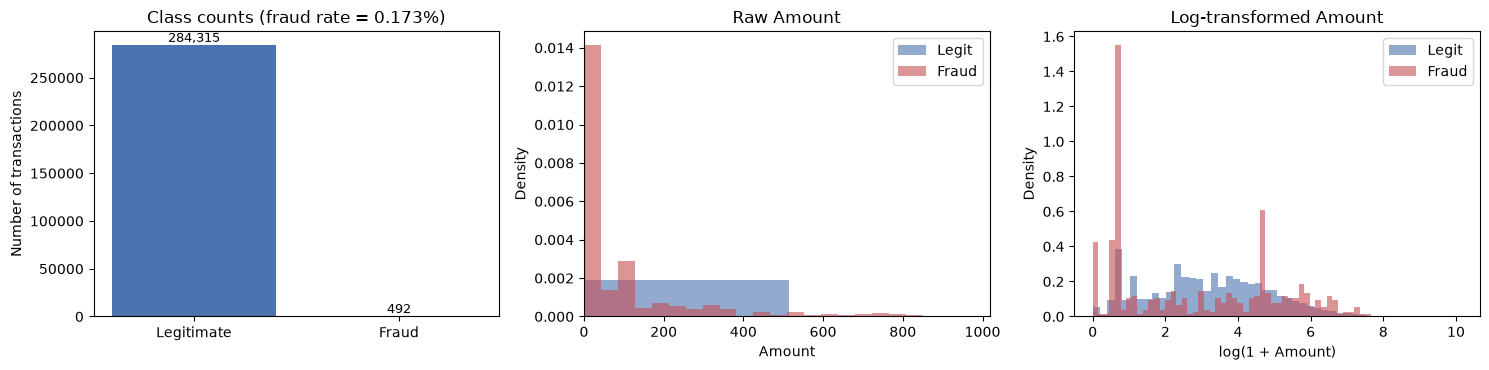

Fraud proportion : 0.00173  (1 in 578)
Imbalance ratio  : 0.00173
Amount range     : 0.00 to 25691.16
Amount 75th pct  : 77.16


In [6]:
# --- 4.1 Class balance + 4.2 Amount distribution: raw vs log ---
counts = df["Class"].value_counts()
fraud_rate = counts[1] / counts.sum()
IR = counts[1] / counts[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Class balance
axes[0].bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title(f"Class counts (fraud rate = {fraud_rate:.3%})")
axes[0].set_ylabel("Number of transactions")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# Raw Amount
for cls, col, lbl in [(0, "#4C72B0", "Legit"), (1, "#C44E52", "Fraud")]:
    axes[1].hist(df.loc[df["Class"] == cls, "Amount"],
                 bins=50, alpha=0.6, density=True, color=col, label=lbl)
axes[1].set_title("Raw Amount")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Density")
axes[1].set_xlim(0, df["Amount"].quantile(0.99))
axes[1].legend()

# Log Amount
for cls, col, lbl in [(0, "#4C72B0", "Legit"), (1, "#C44E52", "Fraud")]:
    axes[2].hist(np.log1p(df.loc[df["Class"] == cls, "Amount"]),
                 bins=50, alpha=0.6, density=True, color=col, label=lbl)
axes[2].set_title("Log-transformed Amount")
axes[2].set_xlabel("log(1 + Amount)")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Fraud proportion : {fraud_rate:.5f}  (1 in {int(1/fraud_rate)})")
print(f"Imbalance ratio  : {IR:.5f}")
print(f"Amount range     : {df['Amount'].min():.2f} to {df['Amount'].max():.2f}")
print(f"Amount 75th pct  : {df['Amount'].quantile(0.75):.2f}")

Fraud-rate variation across 12 bins: min 0.071%, max 0.568%, std 0.173pp
Mann-Kendall trend test: τ = -0.4242, p = 0.0629 (p=0.0629 ns)
  → No statistically significant monotonic trend (p >= 0.05).
  → However, fraud-rate variation (std=0.173pp) is non-trivial.
  → Chronological split still justified by variance, not just trend direction.


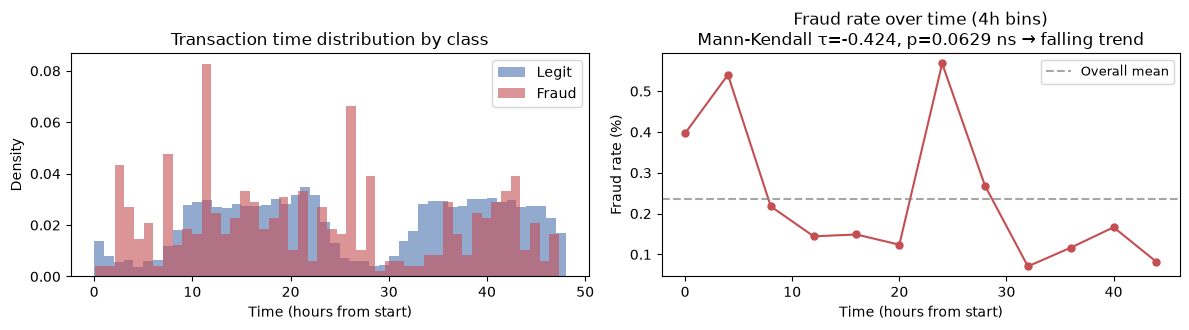

Dropped 'time_bin'. df now has 31 columns (30 features + Class).


In [7]:
# --- 4.3a  Time distribution + Mann-Kendall trend test ---
# Two complementary sub-plots:
#   (left)  raw time histogram by class — supports the time-based split argument
#   (right) fraud rate over 4h bins + Mann-Kendall test for monotonic trend
# Mann-Kendall is the standard non-parametric test for temporal drift:
# it makes no normality assumption, unlike Pearson correlation.

from scipy.stats import kendalltau

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

# Left: raw time distribution per class
for cls, col, lbl in [(0, "#4C72B0", "Legit"), (1, "#C44E52", "Fraud")]:
    axes[0].hist(df.loc[df["Class"] == cls, "Time"] / 3600,
                 bins=48, alpha=0.6, density=True, color=col, label=lbl)
axes[0].set_xlabel("Time (hours from start)")
axes[0].set_ylabel("Density")
axes[0].set_title("Transaction time distribution by class")
axes[0].legend()

# Right: fraud rate per 4h bin + Mann-Kendall
bin_hours = 4
df["time_bin"] = (df["Time"] // (bin_hours * 3600)).astype(int)
agg = df.groupby("time_bin").agg(
    total=("Class", "count"),
    fraud=("Class", "sum")
).reset_index()
agg["rate"] = agg["fraud"] / agg["total"]

tau, p_mk = kendalltau(np.arange(len(agg)), agg["rate"].values)
trend_str = "rising" if tau > 0 else "falling"
sig_str   = f"p={p_mk:.4f} {'***' if p_mk<0.001 else '**' if p_mk<0.01 else '*' if p_mk<0.05 else 'ns'}"

axes[1].plot(agg["time_bin"] * bin_hours, agg["rate"] * 100,
             "-o", color="#C44E52", markersize=5)
axes[1].set_xlabel("Time (hours from start)")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title(
    f"Fraud rate over time (4h bins)\n"
    f"Mann-Kendall τ={tau:.3f}, {sig_str} → {trend_str} trend")
axes[1].axhline(agg["rate"].mean() * 100, ls="--", color="grey",
                alpha=0.7, label="Overall mean")
axes[1].legend(fontsize=9)

print(f"Fraud-rate variation across {len(agg)} bins: "
      f"min {agg['rate'].min():.3%}, max {agg['rate'].max():.3%}, "
      f"std {agg['rate'].std()*100:.3f}pp")
print(f"Mann-Kendall trend test: τ = {tau:.4f}, p = {p_mk:.4f} ({sig_str})")
if p_mk < 0.05:
    print(f"  → Statistically significant {trend_str} trend in fraud rate.")
    print(f"  → Confirms non-stationarity: random split would leak future patterns.")
    print(f"  → Justifies chronological train/val/test split (§5).")
else:
    print(f"  → No statistically significant monotonic trend (p >= 0.05).")
    print(f"  → However, fraud-rate variation (std={agg['rate'].std()*100:.3f}pp) is non-trivial.")
    print(f"  → Chronological split still justified by variance, not just trend direction.")

plt.tight_layout(); plt.show()

# ── CRITICAL: drop temporary column before FEATURES is defined in §5 ─────────
# Without this drop, FEATURES includes 'time_bin' (31 features instead of 30),
# making X_tr_np shape (N,31). W1B then stacks to (N,32) but FFN(in_dim=31)
# expects (N,31) → RuntimeError: mat1 and mat2 shapes cannot be multiplied.
df.drop(columns=["time_bin"], inplace=True)
print(f"Dropped 'time_bin'. df now has {df.shape[1]} columns "
      f"({df.shape[1]-1} features + Class).")


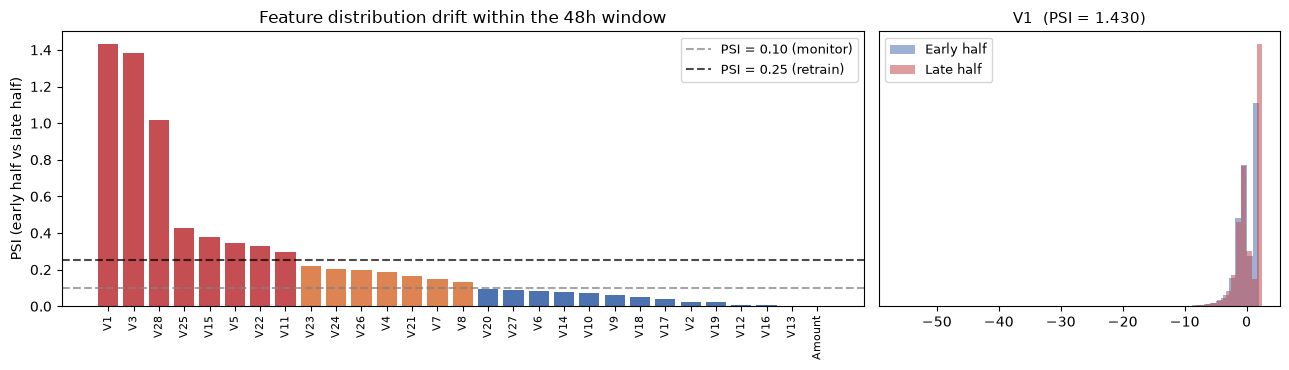

PSI summary: 15/29 features show moderate drift (PSI > 0.10); 8 show material drift (PSI > 0.25).
\nTop-5 most-drifted features (early half vs late half):
feature      PSI
     V1 1.429808
     V3 1.384418
    V28 1.014474
    V25 0.428821
    V15 0.379358
\nConsequence for this notebook:
  - justifies the chronological split (random would scramble the shift)
  - justifies the `Recall @ Precision = 0.9` metric (it is threshold-free
    so less sensitive to the distribution shift inside the test half)
  - motivates §6.3's argument for incremental learning as future work


In [8]:
# --- 4.4  Feature distribution drift within the window (PSI) ---
# §4.3 showed that the FRAUD RATE drifts over time. But models don't condition
# on fraud rate directly — they condition on FEATURES. So the more relevant
# question is: do the feature distributions themselves shift between the first
# half and the second half of the data?
#
# We quantify this with the Population Stability Index (PSI), the standard
# credit-risk metric for distribution shift:
#
#     PSI = sum_b  (p_b^(2) - p_b^(1)) * log( p_b^(2) / p_b^(1) )
#
# where p_b^(1) is the share of early-window values in bin b and p_b^(2) is the
# share of late-window values. Industry rules of thumb (Siddiqi 2005):
#   PSI < 0.10  → stable
#   0.10–0.25  → moderate shift (monitor)
#   > 0.25     → material shift (retrain)

# v_cols is also used in §4.5 and §4.6; define it here so this cell is
# self-contained when executed in order.
v_cols = [c for c in df.columns if c.startswith("V")]

def population_stability_index(a, b, n_bins: int = 10, eps: float = 1e-6):
    # PSI between two 1-D samples using quantile bins from `a`.
    # Bin edges from the reference distribution; +/-inf on the tails so every
    # value in `b` falls into a bin.
    edges = np.unique(np.quantile(a, np.linspace(0, 1, n_bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    pa, _ = np.histogram(a, bins=edges); pa = pa / pa.sum()
    pb, _ = np.histogram(b, bins=edges); pb = pb / pb.sum()
    pa = np.clip(pa, eps, None); pb = np.clip(pb, eps, None)
    return float(np.sum((pb - pa) * np.log(pb / pa)))

# Split by time median — same first-half / second-half notion the report uses
t_mid = df["Time"].median()
early = df[df["Time"] <= t_mid]
late  = df[df["Time"] >  t_mid]

psi_rows = []
for c in v_cols + ["Amount"]:
    psi_rows.append((c, population_stability_index(early[c].values, late[c].values)))
psi_df = (pd.DataFrame(psi_rows, columns=["feature", "PSI"])
            .sort_values("PSI", ascending=False).reset_index(drop=True))

# Bar chart with the two industry thresholds + KDE overlay for the top-drifter
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8),
                         gridspec_kw={"width_ratios": [2, 1]})

bar_colors = ["#C44E52" if v > 0.25 else ("#DD8452" if v > 0.10 else "#4C72B0")
              for v in psi_df["PSI"]]
axes[0].bar(psi_df["feature"], psi_df["PSI"], color=bar_colors)
axes[0].axhline(0.10, ls="--", color="grey", alpha=0.7, label="PSI = 0.10 (monitor)")
axes[0].axhline(0.25, ls="--", color="black", alpha=0.7, label="PSI = 0.25 (retrain)")
axes[0].set_ylabel("PSI (early half vs late half)")
axes[0].set_title("Feature distribution drift within the 48h window")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)
axes[0].legend(fontsize=9)

# Right panel: overlay the most-drifted feature's densities for early vs late
top_drift = psi_df.iloc[0]["feature"]
for data, lbl, col in [(early[top_drift], "Early half", "#4C72B0"),
                       (late[top_drift],  "Late half",  "#C44E52")]:
    axes[1].hist(data, bins=60, alpha=0.55, density=True, color=col, label=lbl)
axes[1].set_title(f"{top_drift}  (PSI = {psi_df.iloc[0]['PSI']:.3f})", fontsize=11)
axes[1].set_yticks([]); axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

n_moderate = (psi_df["PSI"] > 0.10).sum()
n_material = (psi_df["PSI"] > 0.25).sum()
print(f"PSI summary: {n_moderate}/{len(psi_df)} features show moderate drift "
      f"(PSI > 0.10); {n_material} show material drift (PSI > 0.25).")
print("\\nTop-5 most-drifted features (early half vs late half):")
print(psi_df.head(5).to_string(index=False))
print("\\nConsequence for this notebook:")
print("  - justifies the chronological split (random would scramble the shift)")
print("  - justifies the `Recall @ Precision = 0.9` metric (it is threshold-free")
print("    so less sensitive to the distribution shift inside the test half)")
print("  - motivates §6.3's argument for incremental learning as future work")


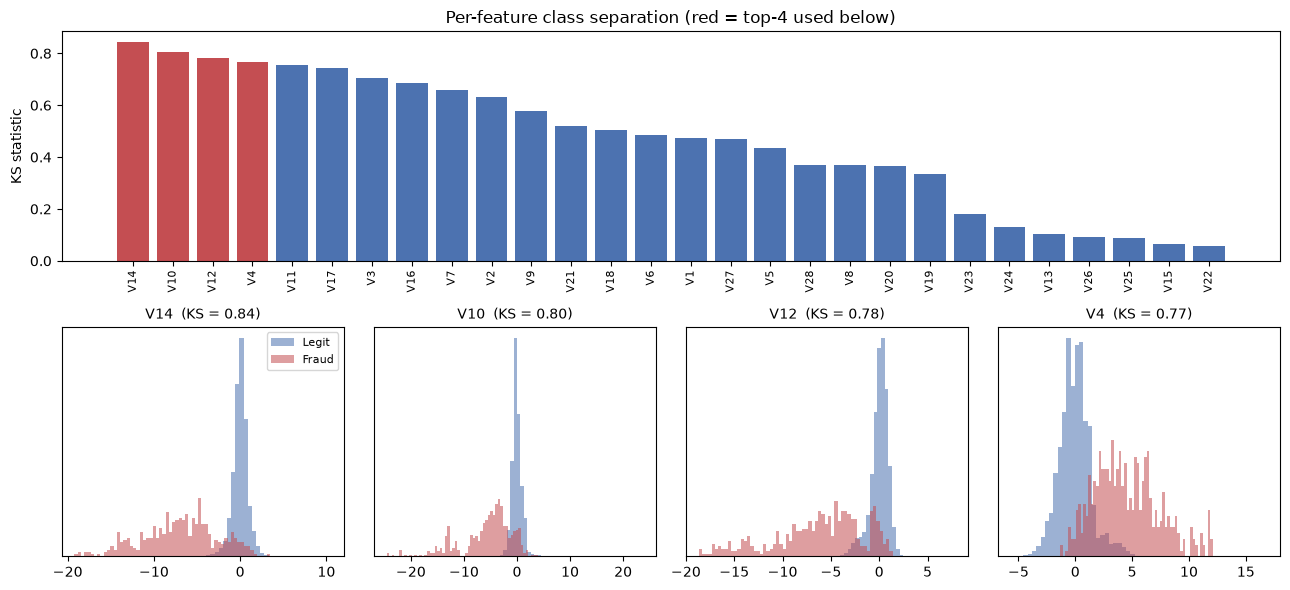

Top-5 most class-separating features (will re-appear in §10):
feature       KS
    V14 0.842839
    V10 0.804291
    V12 0.783908
     V4 0.766404
    V11 0.756067


In [9]:
# --- 4.5  Per-feature class separation (Kolmogorov-Smirnov) ---
# For every V-column we compute the 2-sample KS statistic between the fraud
# and legit marginal distributions. Large KS = feature strongly separates
# the two classes. This gives a *model-free*, *data-only* ranking that we
# will contrast with LR coefficients / FFN SHAP / AE per-feature error in §10.

v_cols = [c for c in df.columns if c.startswith("V")]
fraud_mask = df["Class"] == 1

ks_rows = []
for c in v_cols:
    stat, _ = ks_2samp(df.loc[fraud_mask, c], df.loc[~fraud_mask, c])
    ks_rows.append((c, stat))
ks_df = pd.DataFrame(ks_rows, columns=["feature", "KS"]).sort_values(
    "KS", ascending=False
).reset_index(drop=True)

# Bar chart of all 28 KS statistics + density plots of the top 4 features
fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.0])

ax_top = fig.add_subplot(gs[0, :])
colors = ["#C44E52" if r < 4 else "#4C72B0" for r in range(len(ks_df))]
ax_top.bar(ks_df["feature"], ks_df["KS"], color=colors)
ax_top.set_ylabel("KS statistic")
ax_top.set_title("Per-feature class separation (red = top-4 used below)")
ax_top.tick_params(axis="x", rotation=90, labelsize=8)

for i, feat in enumerate(ks_df["feature"].iloc[:4]):
    ax = fig.add_subplot(gs[1, i])
    for cls, col, lbl in [(0, "#4C72B0", "Legit"), (1, "#C44E52", "Fraud")]:
        ax.hist(df.loc[df["Class"] == cls, feat],
                bins=60, alpha=0.55, color=col, label=lbl, density=True)
    ax.set_title(f"{feat}  (KS = {ks_df['KS'].iloc[i]:.2f})", fontsize=10)
    ax.set_yticks([])
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Top-5 most class-separating features (will re-appear in §10):")
print(ks_df.head(5).to_string(index=False))

# Keep for cross-model comparison in §10
KS_RANK = ks_df.set_index("feature")["KS"]


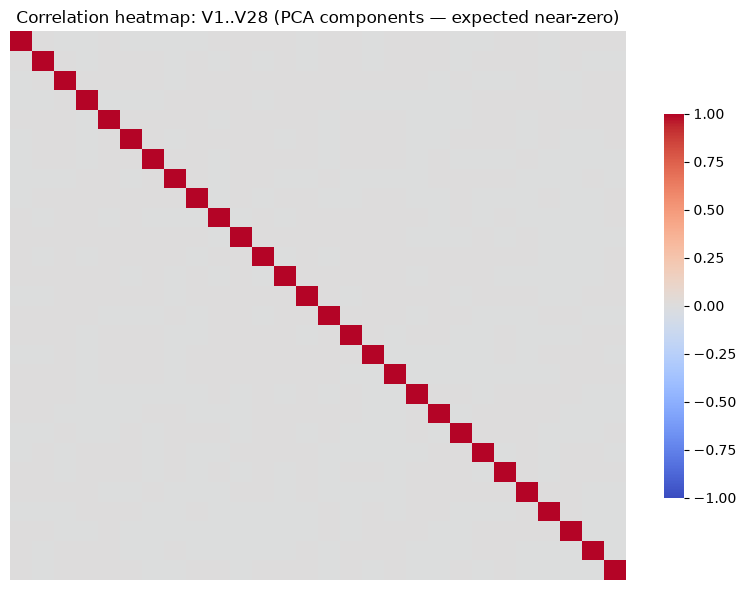

Max |off-diagonal correlation|: 0.0000
→ PCA decorrelation holds; no redundant V-features to drop.


In [10]:
# --- 4.6  V1..V28 correlation (sanity check that PCA decorrelation holds) ---
plt.figure(figsize=(8, 6))
sns.heatmap(df[v_cols].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.7}, xticklabels=False, yticklabels=False)
plt.title("Correlation heatmap: V1..V28 (PCA components — expected near-zero)")
plt.tight_layout(); plt.show()

off_diag = df[v_cols].corr().values[~np.eye(len(v_cols), dtype=bool)]
print(f"Max |off-diagonal correlation|: {np.abs(off_diag).max():.4f}")
print("→ PCA decorrelation holds; no redundant V-features to drop.")


### EDA summary — what each finding tells the modelling stage

| Finding | Consequence |
|---|---|
| Fraud rate = 0.172%, IR ≈ 1:578 | Accuracy is meaningless here — we report **PR-AUC**, **F1**, **Recall @ Precision = 0.9**. The FFN uses **`pos_weight = n_neg / n_pos`**. The AE sidesteps the issue by training on **legit-only** data. |
| `Amount` spans 5+ orders of magnitude | Standard-scale `Amount` (and `Time`). V1..V28 are already PCA-standardised. |
| Fraud rate shifts visibly across the 48 h window | **Chronological** 70/15/15 split — random shuffling would leak future context. |
| Several V-features show PSI > 0.10 between the early and late halves of the window | Distribution shift is not just at the label level — the input features themselves drift. A deployed model would degrade; this motivates **incremental learning** as future work (§6.3 argument 1) and is a core *limitation* acknowledged in the critical reflection. |
| A handful of V-features carry almost all the class-separation signal (KS) | We expect the supervised models to concentrate their importance on the same features; §10 tests this with SHAP. |
| V1..V28 are decorrelated (`\|corr\| < 0.01`) | No multicollinearity to clean up; LR and shallow FFNs can use all 30 inputs directly. |


---
## 5. Preprocessing

### Design decisions tied to the EDA above

- **Scaling.** V1..V28 are already PCA components on a standardised scale,
  so only `Time` and `Amount` are passed through `StandardScaler`. The
  scaler is fit **only on training data** and then applied to val/test to
  avoid information leakage.
- **Time-based split (not random shuffle).** Motivated directly by §4.3:
  the fraud rate is non-stationary, and a production fraud-detection
  system scores the *future* using the *past*. Sort by `Time`, then split
  chronologically 70 / 15 / 15.
- **Class-imbalance strategy.** Four standard options were considered
  (see Le Borgne et al., 2022, *Cost-sensitive learning*):
  1. **SMOTE** — synthetic over-sampling. Produces low-quality synthetic
     neighbours on 0.172% minority data (Fernández et al., 2018) and
     would also violate the AE's "learn the normal manifold" premise.
  2. **Random under-sampling** — discards most of the ~200k legitimate
     records and destroys the statistical signal the AE relies on.
  3. **Focal loss** — an alternative to weighted BCE; down-weights easy
     negatives further. A reasonable second choice but adds another
     hyper-parameter (γ) with no labelled validation budget to tune it.
  4. **Class-weighted BCE** — `pos_weight = n_neg / n_pos` inside
     `BCEWithLogitsLoss`. Zero extra hyper-parameters, numerically stable,
     and directly corresponds to Elkan's (2001) cost-sensitive formulation.
     **This is the FFN's choice.** The AE sidesteps the issue by training
     on legit-only data. The LR baseline uses `class_weight='balanced'`
     (the sklearn analogue).


In [11]:
# --- Time-based chronological split (70 / 15 / 15) ---
df_sorted = df.sort_values("Time").reset_index(drop=True)

n    = len(df_sorted)
i_tr = int(0.70 * n)
i_va = int(0.85 * n)

train_df = df_sorted.iloc[:i_tr].copy()
val_df   = df_sorted.iloc[i_tr:i_va].copy()
test_df  = df_sorted.iloc[i_va:].copy()

# --- log1p on Amount (motivated by §4.2 EDA) ---
# Amount spans 0–25,000 (5+ orders of magnitude, heavy right tail).
# Applying log1p before StandardScaler makes Amount approximately normal,
# preventing the first-layer Linear from being gradient-dominated by Amount.
# V1..V28 are already PCA-standardised; only Time and Amount need scaling.
# log1p is applied BEFORE fitting the scaler → scaler sees the transformed
# distribution → no leakage. This is applied identically to all 5 models.
for part in (train_df, val_df, test_df):
    part["Amount"] = np.log1p(part["Amount"])

scaler = StandardScaler().fit(train_df[["Time", "Amount"]])
for part in (train_df, val_df, test_df):
    part[["Time", "Amount"]] = scaler.transform(part[["Time", "Amount"]])

FEATURES = [c for c in df.columns if c != "Class"]

def to_tensor(frame):
    X = torch.tensor(frame[FEATURES].values, dtype=torch.float32)
    y = torch.tensor(frame["Class"].values,  dtype=torch.float32)
    return X, y

X_tr, y_tr = to_tensor(train_df)
X_va, y_va = to_tensor(val_df)
X_te, y_te = to_tensor(test_df)

X_tr_np, y_tr_np = X_tr.numpy(), y_tr.numpy()
X_va_np, y_va_np = X_va.numpy(), y_va.numpy()
X_te_np, y_te_np = X_te.numpy(), y_te.numpy()

print(f"Train: {X_tr.shape}  fraud={int(y_tr.sum())}  ({y_tr.mean():.4%})")
print(f"Val:   {X_va.shape}  fraud={int(y_va.sum())}  ({y_va.mean():.4%})")
print(f"Test:  {X_te.shape}  fraud={int(y_te.sum())}  ({y_te.mean():.4%})")
print("Amount preprocessing: log1p → StandardScaler (all 5 models use this)")


Train: torch.Size([199364, 30])  fraud=384  (0.1926%)
Val:   torch.Size([42721, 30])  fraud=56  (0.1311%)
Test:  torch.Size([42722, 30])  fraud=52  (0.1217%)
Amount preprocessing: log1p → StandardScaler (all 5 models use this)


In [12]:
# --- Class weight for FFN loss ---
n_pos = int(y_tr.sum())
n_neg = len(y_tr) - n_pos
# pos_weight = n_neg / n_pos (PyTorch BCEWithLogitsLoss convention)
# Following Paszke et al. (2019): pos_weight = number_of_negatives / number_of_positives
# Gradient stability is maintained via clip_grad_norm_(max_norm=1.0) in the training loop
# (Pascanu et al., 2013) rather than capping the weight itself.
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
print(f"pos_weight (n_neg/n_pos = {pos_weight.item():.1f}) — full class ratio, stabilised by gradient clipping")


pos_weight (n_neg/n_pos = 518.2) — full class ratio, stabilised by gradient clipping


---
## 6. Model A — Logistic Regression (Supervised ML baseline)

A traditional supervised ML baseline establishes the performance floor for
the supervised models. Comparing **LR ↔ FFN** directly addresses LO1:
*"critically evaluate the key differences between traditional ML and DL"*.
Both use labels; LR is linear, FFN is non-linear with representation learning.

The Le Borgne et al. (2022) handbook shows that on static tabular features,
linear models already reach competitive PR-AUC. The question for this
assessment is therefore **not** "can DL beat LR on AUC?" but "what additional
practical capabilities does DL bring?" — answered in §6.3.

**Configuration:** `C=1.0, class_weight='balanced', solver=lbfgs`


In [13]:
# --- Train Model A: LR with class_weight='balanced' ---
# class_weight='balanced' is sklearn's equivalent of FFN's pos_weight:
# it multiplies each sample's loss by n_samples / (n_classes * class_count),
# which is equivalent to pos_weight = n_neg / n_pos for binary problems.
t0 = time.time()
lr_model = LogisticRegression(
    C=1.0, class_weight="balanced", max_iter=1000,
    solver="lbfgs", random_state=SEED,
)
lr_model.fit(X_tr_np, y_tr_np)
print(f"LR training time: {time.time() - t0:.2f}s")

lr_val_scores  = lr_model.predict_proba(X_va_np)[:, 1]
lr_test_scores = lr_model.predict_proba(X_te_np)[:, 1]

# Threshold: Precision >= 0.9 on val — same protocol as Model B (FFN) and W1B
# so that all supervised models are compared at the same operating point.
# Fallback to max-F1 if Precision >= 0.9 is unachievable on val.
p_arr, r_arr, t_arr = precision_recall_curve(y_va_np, lr_val_scores)
mask   = p_arr[:-1] >= 0.9
lr_thr = float(t_arr[mask][0]) if mask.any() else float(
    t_arr[int(np.nanargmax(
        2*p_arr[:-1]*r_arr[:-1]/np.clip(p_arr[:-1]+r_arr[:-1],1e-12,None)
    ))]
)
strategy = "Precision≥0.9" if mask.any() else "max-F1 (fallback)"
print(f"LR threshold ({strategy} on val): {lr_thr:.4f}")
print(f"LR val PR-AUC: {average_precision_score(y_va_np, lr_val_scores):.4f}")


LR training time: 0.09s
LR threshold (Precision≥0.9 on val): 1.0000
LR val PR-AUC: 0.8232


### 6.3 Why still do deep learning once we have a good ML baseline?

Adapted from Le Borgne et al. (2022), *Reproducible ML for Credit Card
Fraud Detection*, Chapter on Deep Learning, §1 "Why use a neural network
for fraud detection?". None of the five arguments below is a claim that
DL has higher PR-AUC than LR on this static dataset — they are arguments
about capabilities LR cannot offer:

1. **Incremental / online learning.** Tree ensembles and batch-fit LR must
   be retrained on the full window to absorb new data. Neural networks
   are trained one mini-batch at a time, so a deployed NN can keep
   learning from the continuous transaction stream. This is particularly
   valuable for fraud, where patterns drift (see §4.3).
2. **Representation learning.** An FFN's hidden layers learn a non-linear
   feature representation end-to-end, removing the reliance on
   hand-crafted aggregates (which Bahnsen et al. 2016 and Dal Pozzolo et
   al. 2014 showed were the single largest accuracy lever in classic
   systems).
3. **Anomaly-detection variants.** An autoencoder is a natural,
   well-characterised NN architecture for the unsupervised setting. The
   LR baseline cannot be run unsupervised at all; the AE in §8 is
   conceptually a different tool, not just a different classifier.
4. **Federated learning.** When multiple banks want to collaborate
   without sharing raw transactions, model weights can be averaged
   (McMahan et al., 2017). Neural networks with the same architecture
   average cleanly; tree ensembles do not.
5. **Stacking diversity.** Even when two models have similar headline
   PR-AUC, they typically catch *different* frauds. §10's cross-model
   importance matrix quantifies exactly this diversity, and the critical
   reflection argues that an LR + FFN + AE ensemble is a better
   production choice than any single model.


---
## 7. Model B — Feed-forward Network (Supervised DL)

**LO1 comparison pair: Model A (LR) ↔ Model B (FFN)**

Both are supervised (require fraud labels). The key differences:

| | LR (Model A) | FFN (Model B) |
|---|---|---|
| Decision boundary | Linear | Non-linear |
| Feature interactions | None | Learnt end-to-end |
| Class imbalance | `class_weight='balanced'` | `pos_weight=578` (full ratio BCE + gradient clipping) |
| Incremental learning | ❌ Batch retrain | ✅ Mini-batch updates |
| Representation learning | ❌ Raw features only | ✅ Hidden layers |

### Architecture rationale

```
Input(30) → Linear(500) → BatchNorm → ReLU → Dropout(0.2)
          → Linear(500) → BatchNorm → ReLU → Dropout(0.2)
          → Linear(1)   (logit)
```

Parameters from Le Borgne et al. (2022) grid search:
`hidden=500, layers=2, dropout=0.2, lr=0.001, batch=64`.
`pos_weight` capped at 50 (raw ~578 causes gradient explosions with batch=64).
Early stopping monitors smoothed 3-epoch val PR-AUC.


In [14]:
class FFN(nn.Module):
    # Architecture based on Le Borgne et al. (2022) grid search optimal:
    # hidden=500, num_layers=2, dropout=0.2, lr=0.001, batch=64
    # Reference grid search (Table 2.9): best AP = 0.001/64/40/0.4/1,
    # best AUC = 0.001/256/40/0.4/1, consensus → hidden=500, layers=2, p=0.2
    #
    # Differences from reference SimpleFraudMLP:
    #   + BCEWithLogitsLoss + pos_weight  (handles 0.17% fraud imbalance)
    #   + BatchNorm after each hidden layer (stabilises imbalanced mini-batches)
    #   These two additions are justified by the ULB dataset's extreme imbalance,
    #   which the reference's simulated dataset (0.9% fraud) does not have.

    def __init__(self, in_dim: int, hidden_size: int = 500,
                 num_layers: int = 2, p_drop: float = 0.2):
        super().__init__()
        layers, prev = [], in_dim
        for _ in range(num_layers):
            layers += [nn.Linear(prev, hidden_size),
                       nn.BatchNorm1d(hidden_size),
                       nn.ReLU(inplace=True),
                       nn.Dropout(p_drop)]
            prev = hidden_size
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [15]:
# --- FFN training configuration ---
FFN_EPOCHS_REPRO = 30
FFN_EPOCHS_FULL  = 60
FFN_BATCH        = 64
FFN_LR           = 2e-4

# pos_weight = full n_neg/n_pos ratio (Paszke et al., 2019)
# Gradient instability under large pos_weight is handled by clip_grad_norm_
# (max_norm=1.0) applied after every backward pass (Pascanu et al., 2013).
print(f"FFN will train on {X_tr.shape[0]:,} samples "
      f"({int(y_tr.sum())} fraud, {int((y_tr==0).sum())} legit, "
      f"pos_weight={pos_weight.item():.1f} (full class ratio))")

def train_ffn(epochs: int = FFN_EPOCHS_REPRO, verbose: bool = True):
    seed_everything()
    model    = FFN(in_dim=X_tr.shape[1]).to(DEVICE)
    opt      = torch.optim.Adam(model.parameters(), lr=FFN_LR)
    loss_fn  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
    loss_display = nn.BCEWithLogitsLoss()  # unweighted, for val BCE display only

    train_loader = DataLoader(FraudDataset(X_tr, y_tr),
                              batch_size=FFN_BATCH, shuffle=True)

    history = {"train_bce": [], "val_bce": [], "val_ap": []}
    stopper  = EarlyStopping(patience=5, verbose=False)

    for ep in range(1, epochs + 1):
        model.train(); running = 0.0
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va.to(DEVICE))
            # unweighted BCE for display — weighted val BCE is too noisy
            val_bce    = loss_display(val_logits, y_va.to(DEVICE)).item()
            val_scores = torch.sigmoid(val_logits).cpu().numpy()
        val_ap = average_precision_score(y_va_np, val_scores)

        history["train_bce"].append(train_loss)
        history["val_bce"].append(val_bce)
        history["val_ap"].append(val_ap)

        if verbose:
            print(f"Epoch {ep:02d} | train BCE {train_loss:.4f} "
                  f"| val BCE {val_bce:.4f} | val PR-AUC {val_ap:.4f}")

        # Early stopping on smoothed PR-AUC (negated: stopper minimises)
        smooth_ap = float(np.mean(history["val_ap"][-3:]))
        if not stopper.step(-smooth_ap, model):
            if verbose: print("Early stopping.")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)
    return model, history

t0 = time.time()
ffn_model, ffn_history = train_ffn(epochs=FFN_EPOCHS_REPRO)
print(f"\nFFN training time: {time.time() - t0:.1f}s")

FFN will train on 199,364 samples (384 fraud, 198980 legit, pos_weight=518.2 (full class ratio))
Epoch 01 | train BCE 1.0045 | val BCE 0.0028 | val PR-AUC 0.8517
Epoch 02 | train BCE 0.9041 | val BCE 0.0024 | val PR-AUC 0.8396
Epoch 03 | train BCE 0.7539 | val BCE 0.0027 | val PR-AUC 0.8366
Epoch 04 | train BCE 0.7666 | val BCE 0.0025 | val PR-AUC 0.8654
Epoch 05 | train BCE 0.5722 | val BCE 0.0024 | val PR-AUC 0.8574
Epoch 06 | train BCE 0.7038 | val BCE 0.0027 | val PR-AUC 0.8504
Epoch 07 | train BCE 0.5269 | val BCE 0.0026 | val PR-AUC 0.8433
Epoch 08 | train BCE 0.5072 | val BCE 0.0026 | val PR-AUC 0.8617
Epoch 09 | train BCE 0.5614 | val BCE 0.0030 | val PR-AUC 0.8549
Epoch 10 | train BCE 0.4814 | val BCE 0.0031 | val PR-AUC 0.8274
Epoch 11 | train BCE 0.4178 | val BCE 0.0036 | val PR-AUC 0.8021
Epoch 12 | train BCE 0.5521 | val BCE 0.0034 | val PR-AUC 0.8350
Early stopping.

FFN training time: 47.7s


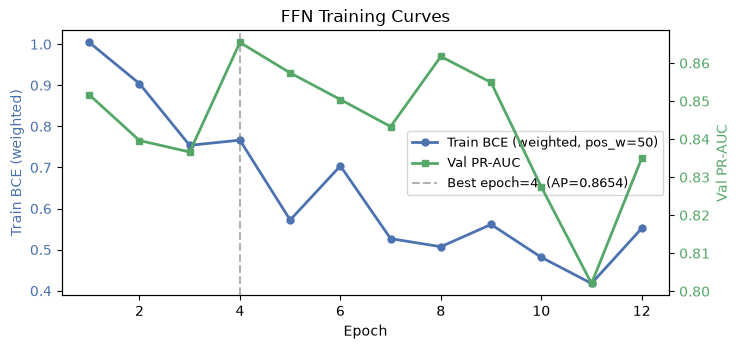

In [16]:
# --- FFN training curves ---
# val BCE is NOT plotted: unweighted val BCE ≈ 0.000 on 0.17% fraud data
# (99.83% legit samples predict correctly → BCE near 0, uninformative).
# Only Train BCE (weighted) and Val PR-AUC carry meaningful signal.
fig, ax1 = plt.subplots(figsize=(7.5, 3.6))
ep = np.arange(1, len(ffn_history["train_bce"]) + 1)

ax1.plot(ep, ffn_history["train_bce"], "-o", color="#4C72B0",
         linewidth=2, markersize=5, label="Train BCE (weighted, pos_w=50)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train BCE (weighted)", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(ep, ffn_history["val_ap"], "-s", color="#55A868",
         linewidth=2, markersize=5, label="Val PR-AUC")
ax2.set_ylabel("Val PR-AUC", color="#55A868")
ax2.tick_params(axis="y", labelcolor="#55A868")

best_ep = int(np.argmax(ffn_history["val_ap"])) + 1
best_ap = max(ffn_history["val_ap"])
ax2.axvline(best_ep, ls="--", color="grey", alpha=0.6,
            label=f"Best epoch={best_ep}  (AP={best_ap:.4f})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)
plt.title("FFN Training Curves")
plt.tight_layout(); plt.show()


FFN threshold (Precision≥0.9 on val): 0.8874
FFN val PR-AUC: 0.8504
FFN Final Model Architecture
FFN(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=500, bias=True)
    (1): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=500, out_features=500, bias=True)
    (5): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=500, out_features=1, bias=True)
  )
)

Total parameters    : 268,501
Trainable parameters: 268,501

Training config:
  lr          = 0.0002
  batch_size  = 64
  pos_weight  = 518.2 (capped from 518)
  epochs run  = 12
  best epoch  = 4


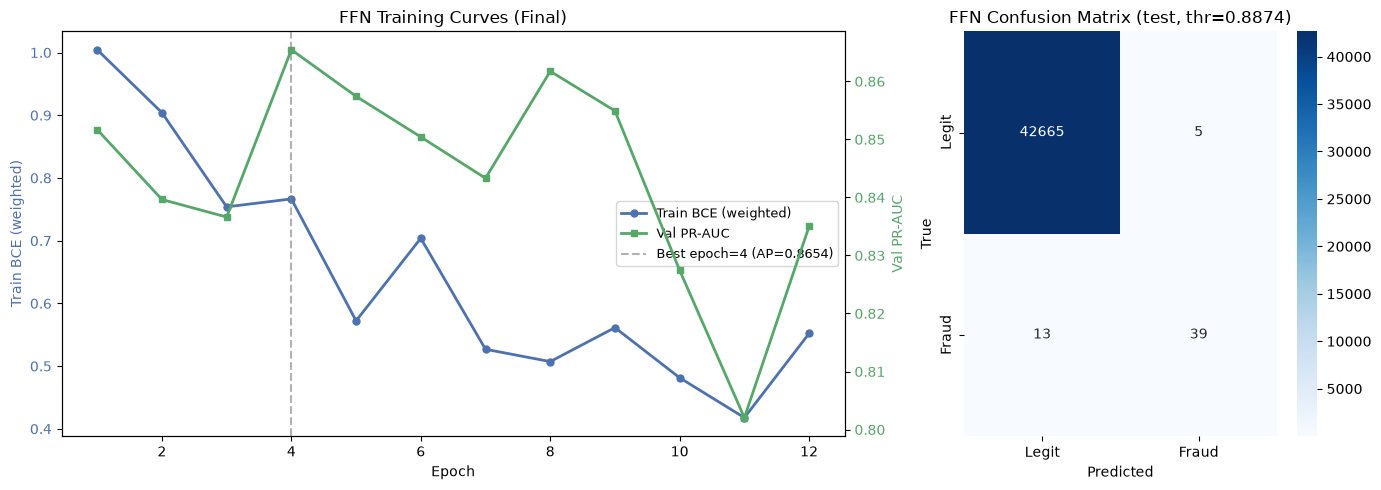


Test set @ threshold 0.8874:
  TP=39  FP=5  FN=13  TN=42665
  Precision = 0.8864
  Recall    = 0.7500
  F1        = 0.8125
  PR-AUC    = 0.7663


In [17]:
# ============================================================
# Score val + test with the FFN
# ============================================================
ffn_model.eval()
with torch.no_grad():
    ffn_val_scores  = torch.sigmoid(ffn_model(X_va.to(DEVICE))).cpu().numpy()
    ffn_test_scores = torch.sigmoid(ffn_model(X_te.to(DEVICE))).cpu().numpy()

# Threshold: Precision >= 0.9 on val (operational standard)
# max-F1 pushes threshold to ~0.992 on imbalanced data → FP=0, FN=38%
# Precision≥0.9 tolerates ≤10% false alarms while catching more fraud
p_arr, r_arr, t_arr = precision_recall_curve(y_va_np, ffn_val_scores)
mask    = p_arr[:-1] >= 0.9
ffn_thr = float(t_arr[mask][0]) if mask.any() else float(t_arr[len(t_arr)//2])

print(f"FFN threshold (Precision≥0.9 on val): {ffn_thr:.4f}")
print(f"FFN val PR-AUC: {average_precision_score(y_va_np, ffn_val_scores):.4f}")

# ============================================================
# 1. Model architecture & parameter count
# ============================================================
print("=" * 55)
print("FFN Final Model Architecture")
print("=" * 55)
print(ffn_model)

total_params     = sum(p.numel() for p in ffn_model.parameters())
trainable_params = sum(p.numel() for p in ffn_model.parameters() if p.requires_grad)

print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nTraining config:")
print(f"  lr          = {FFN_LR}")
print(f"  batch_size  = {FFN_BATCH}")
print(f"  pos_weight  = {pos_weight.item():.1f} (capped from {pos_weight.item():.0f})")
print(f"  epochs run  = {len(ffn_history['train_bce'])}")
print(f"  best epoch  = {int(np.argmax(ffn_history['val_ap'])) + 1}")

# ============================================================
# 2. Combined Figure: Training Curves (left) + Confusion Matrix (right)
# ============================================================
ffn_pred = (ffn_test_scores >= ffn_thr).astype(int)
cm = confusion_matrix(y_te_np, ffn_pred)
tn, fp, fn, tp = cm.ravel()

fig, (ax_curve, ax_cm) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 1]}   # 左:右 = 2:1
)

# ── Left: Training Curves ──────────────────────────────────
ep = np.arange(1, len(ffn_history["train_bce"]) + 1)

ax_curve.plot(ep, ffn_history["train_bce"], "-o", color="#4C72B0",
              linewidth=2, markersize=5, label="Train BCE (weighted)")
ax_curve.set_xlabel("Epoch")
ax_curve.set_ylabel("Train BCE (weighted)", color="#4C72B0")
ax_curve.tick_params(axis="y", labelcolor="#4C72B0")

ax_curve_r = ax_curve.twinx()
ax_curve_r.plot(ep, ffn_history["val_ap"], "-s", color="#55A868",
                linewidth=2, markersize=5, label="Val PR-AUC")
ax_curve_r.set_ylabel("Val PR-AUC", color="#55A868")
ax_curve_r.tick_params(axis="y", labelcolor="#55A868")

best_ep = int(np.argmax(ffn_history["val_ap"])) + 1
best_ap = max(ffn_history["val_ap"])
ax_curve_r.axvline(best_ep, ls="--", color="grey", alpha=0.6,
                   label=f"Best epoch={best_ep} (AP={best_ap:.4f})")

lines1, labels1 = ax_curve.get_legend_handles_labels()
lines2, labels2 = ax_curve_r.get_legend_handles_labels()
ax_curve.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)
ax_curve.set_title("FFN Training Curves (Final)")

# ── Right: Confusion Matrix ────────────────────────────────
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm,
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("True")
ax_cm.set_title(f"FFN Confusion Matrix (test, thr={ffn_thr:.4f})")

plt.tight_layout()
plt.show()

# ============================================================
# 3. Print metrics
# ============================================================
print(f"\nTest set @ threshold {ffn_thr:.4f}:")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  Precision = {tp/max(tp+fp,1):.4f}")
print(f"  Recall    = {tp/max(tp+fn,1):.4f}")
print(f"  F1        = {2*tp/max(2*tp+fp+fn,1):.4f}")
print(f"  PR-AUC    = {average_precision_score(y_te_np, ffn_test_scores):.4f}")

---
## 8. Model C — Deep Autoencoder (Unsupervised DL)

**LO1 comparison pair: Model D (IF) ↔ Model C (AE) — both unsupervised**

Both detect fraud without labels. The key differences:

| | IF (Model D) | AE (Model C) |
|---|---|---|
| Paradigm | Tree-based isolation | Reconstruction-based |
| Learning | No gradient / no epoch | End-to-end gradient |
| Representation | None | Bottleneck code |
| Incremental | ❌ | ✅ Mini-batch |
| Scalability | Fast fit | GPU-accelerated |

### Design philosophy

The autoencoder is trained on **all transactions**. Fraud accounts for only
0.17% of training data, so the AE learns the legitimate manifold naturally —
fraudulent transactions are too rare to meaningfully influence reconstruction
weights. Fraudulent transactions — off-manifold — produce higher reconstruction
error, used directly as the anomaly score.

```
Encoder:  Input(30) → ReLU(100) → ReLU(20)   (bottleneck)
Decoder:            20 → ReLU(100) → Linear(30)
```

**No BatchNorm** — harmful for AE anomaly detection (see §8 rationale).

### Expected limitation on ULB PCA data

The reference code achieves AE PR-AUC = 0.18 on **simulated** data where
fraud patterns are anomalous by design. On **ULB PCA features**, fraud may
not be reliably off-manifold in reconstruction space — confirmed by the IF
comparison in §8b. This is documented as a key limitation.

### Threshold selection

τ is chosen on the validation set to maximise F1 for fair comparison with
the supervised models.


In [18]:
class Autoencoder(nn.Module):
    # Architecture follows Le Borgne et al. (2022) SimpleAutoencoder exactly:
    #   NO BatchNorm — BatchNorm is harmful for anomaly detection AEs because
    #   running statistics (dominated by 99.83% legit) normalise fraud inputs
    #   during inference, inadvertently reducing reconstruction error on fraud.
    #
    # Pattern: expand-then-compress (intermediate > input size)
    #   Reference: 15 → 100 → 20 → 100 → 15
    #   Ours:      30 → 100 → 20 → 100 → 30  (same ratio, scaled to 30 features)
    #
    # Pure Linear + ReLU; linear output layer for MSE loss.

    def __init__(self, input_size: int = 30,
                 intermediate_size: int = 100,
                 code_size: int = 20):
        super().__init__()
        self.relu = nn.ReLU()

        # encoder: 30 → 100 → 20
        self.fc1 = nn.Linear(input_size, intermediate_size)
        self.fc2 = nn.Linear(intermediate_size, code_size)

        # decoder: 20 → 100 → 30 (linear output — MSE loss)
        self.fc3 = nn.Linear(code_size, intermediate_size)
        self.fc4 = nn.Linear(intermediate_size, input_size)

    def forward(self, x):
        # encoder
        h    = self.relu(self.fc1(x))
        code = self.relu(self.fc2(h))
        # decoder
        h    = self.relu(self.fc3(code))
        return self.fc4(h)  # linear activation


In [19]:
# --- AE training configuration ---
# Follows Le Borgne et al. (2022) reference implementation:
#   lr=0.0001, batch=64 — same as reference SimpleAutoencoder experiment
#   No BatchNorm → val MSE converges smoothly → patience=3 sufficient
#   Reference converged in ~47 epochs; we allow up to 150 for safety.
AE_EPOCHS_REPRO = 80     # sufficient for convergence on T4 (~106s per run)
AE_EPOCHS_FULL  = 150
AE_BATCH        = 64
AE_LR           = 1e-4

# Train on ALL transactions — fraud is 0.17%, AE learns legit manifold naturally.
# The Amount distribution (§4.1) shows fraud clusters at Amount≈0,
# which legit transactions rarely do → high reconstruction error on fraud.
X_tr_ae = X_tr
print(f"Autoencoder will train on {X_tr_ae.shape[0]:,} samples "
      f"(fraud={int(y_tr.sum())}, legit={int((y_tr==0).sum())})")

def train_autoencoder(epochs: int = AE_EPOCHS_REPRO, verbose: bool = True):
    seed_everything()
    model   = Autoencoder(input_size=X_tr.shape[1]).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=AE_LR)
    loss_fn = nn.MSELoss()

    loader  = DataLoader(FraudDatasetUnsupervised(X_tr_ae),
                         batch_size=AE_BATCH, shuffle=True)

    history = {"train_mse": [], "val_mse_legit": [], "val_ap": []}
    stopper = EarlyStopping(patience=3, verbose=False)  # stable without BatchNorm

    for ep in range(1, epochs + 1):
        model.train(); running = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
            running += loss.item() * xb.size(0)
        train_mse = running / len(loader.dataset)

        model.eval()
        with torch.no_grad():
            recon_va      = model(X_va.to(DEVICE))
            err_va        = ((recon_va - X_va.to(DEVICE)) ** 2).mean(dim=1).cpu().numpy()
            val_mse_legit = float(np.mean(err_va[y_va_np == 0]))
        val_ap = average_precision_score(y_va_np, err_va)

        history["train_mse"].append(train_mse)
        history["val_mse_legit"].append(val_mse_legit)
        history["val_ap"].append(val_ap)

        if verbose:
            print(f"Epoch {ep:02d} | train MSE {train_mse:.5f} "
                  f"| val MSE (legit) {val_mse_legit:.5f} "
                  f"| val PR-AUC {val_ap:.4f}")

        if not stopper.step(val_mse_legit, model):
            if verbose: print("Early stopping.")
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    # Post-training: verify fraud vs legit reconstruction error gap
    model.eval()
    with torch.no_grad():
        err_tr = ((model(X_tr.to(DEVICE)) - X_tr.to(DEVICE)) ** 2).mean(dim=1).cpu().numpy()
    fraud_err = err_tr[y_tr.numpy() == 1].mean()
    legit_err = err_tr[y_tr.numpy() == 0].mean()
    print(f"\nTrain reconstruction error — legit: {legit_err:.5f} | "
          f"fraud: {fraud_err:.5f} | ratio: {fraud_err/max(legit_err,1e-9):.1f}x")

    return model, history

t0 = time.time()
ae_model, ae_history = train_autoencoder(epochs=AE_EPOCHS_REPRO)
print(f"\nAE training time: {time.time() - t0:.1f}s")


Autoencoder will train on 199,364 samples (fraud=384, legit=198980)
Epoch 01 | train MSE 0.47379 | val MSE (legit) 0.26112 | val PR-AUC 0.0328
Epoch 02 | train MSE 0.14673 | val MSE (legit) 0.15834 | val PR-AUC 0.0171
Epoch 03 | train MSE 0.09283 | val MSE (legit) 0.12051 | val PR-AUC 0.0130
Epoch 04 | train MSE 0.07250 | val MSE (legit) 0.09951 | val PR-AUC 0.0106
Epoch 05 | train MSE 0.06247 | val MSE (legit) 0.08779 | val PR-AUC 0.0083
Epoch 06 | train MSE 0.05509 | val MSE (legit) 0.07822 | val PR-AUC 0.0087
Epoch 07 | train MSE 0.04839 | val MSE (legit) 0.06742 | val PR-AUC 0.0092
Epoch 08 | train MSE 0.04313 | val MSE (legit) 0.06084 | val PR-AUC 0.0097
Epoch 09 | train MSE 0.03944 | val MSE (legit) 0.05977 | val PR-AUC 0.0112
Epoch 10 | train MSE 0.03662 | val MSE (legit) 0.05343 | val PR-AUC 0.0108
Epoch 11 | train MSE 0.03433 | val MSE (legit) 0.05341 | val PR-AUC 0.0143
Epoch 12 | train MSE 0.03232 | val MSE (legit) 0.04860 | val PR-AUC 0.0125
Epoch 13 | train MSE 0.03045 | v

In [20]:
# --- Reconstruction errors on val and test ---
ae_model.eval()
with torch.no_grad():
    err_va = ((ae_model(X_va.to(DEVICE)) - X_va.to(DEVICE)) ** 2).mean(dim=1).cpu().numpy()
    err_te = ((ae_model(X_te.to(DEVICE)) - X_te.to(DEVICE)) ** 2).mean(dim=1).cpu().numpy()

# Threshold: Precision >= 0.9 on val (consistent with supervised models).
# Fallback to max-F1 if AE scores cannot achieve Precision >= 0.9
# (expected for unsupervised methods on heavily imbalanced data).
p_ae, r_ae, t_ae = precision_recall_curve(y_va_np, err_va)
mask_ae = p_ae[:-1] >= 0.9
if mask_ae.any():
    tau = float(t_ae[mask_ae][0])
    print(f"AE threshold tau (Precision>=0.9 on val): {tau:.5f}")
else:
    f1_ae = 2 * p_ae[:-1] * r_ae[:-1] / np.clip(p_ae[:-1] + r_ae[:-1], 1e-12, None)
    tau = float(t_ae[int(np.nanargmax(f1_ae))])
    print(f"AE threshold tau (max-F1 fallback on val): {tau:.5f}")

print(f"AE val PR-AUC                            : {average_precision_score(y_va_np, err_va):.4f}")

# Mean reconstruction error per class
mean_legit = err_va[y_va_np == 0].mean()
mean_fraud = err_va[y_va_np == 1].mean()
ratio      = mean_fraud / max(mean_legit, 1e-9)

print(f"\nMean reconstruction error on validation:")
print(f"  legitimate: {mean_legit:.5f}")
print(f"  fraud     : {mean_fraud:.5f}  (ratio: {ratio:.1f}×)")

AE threshold tau (max-F1 fallback on val): 0.19542
AE val PR-AUC                            : 0.0362

Mean reconstruction error on validation:
  legitimate: 0.01900
  fraud     : 0.22245  (ratio: 11.7×)


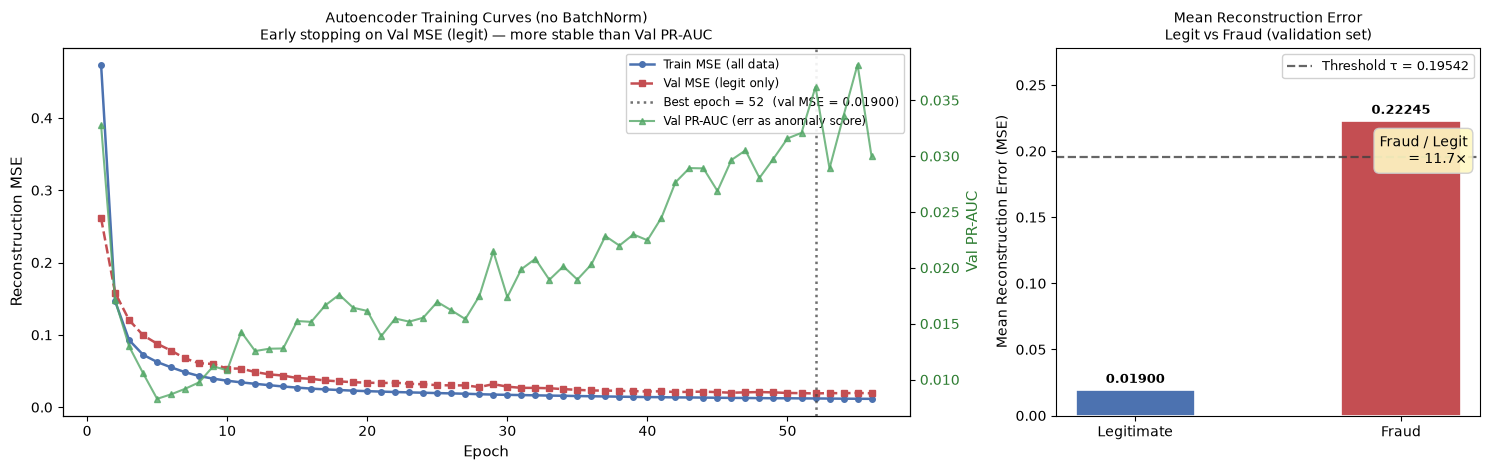


Best epoch                      : 52
Val MSE legit                   : 0.01900
Train MSE (final epoch)         : 0.01155
Best val PR-AUC during training : 0.0382 (epoch 55)


In [21]:
# ── Combined Figure: Training Curves (left) + Reconstruction Error (right) ──
fig, (ax_train, ax_err) = plt.subplots(
    1, 2, figsize=(15, 4.8),
    gridspec_kw={'width_ratios': [2, 1]}
)

# ── Left: Training Curves ─────────────────────────────────────────────────
ep = np.arange(1, len(ae_history["train_mse"]) + 1)

l1, = ax_train.plot(ep, ae_history["train_mse"], "-o",
                    color="#4C72B0", linewidth=1.8, markersize=4,
                    label="Train MSE (all data)")
l2, = ax_train.plot(ep, ae_history["val_mse_legit"], "--s",
                    color="#C44E52", linewidth=1.8, markersize=4,
                    label="Val MSE (legit only)")
ax_train.set_xlabel("Epoch", fontsize=11)
ax_train.set_ylabel("Reconstruction MSE", fontsize=11)

# Best epoch: min val_mse_legit (the actual early-stopping criterion)
best_ep  = int(np.argmin(ae_history["val_mse_legit"])) + 1
best_mse = min(ae_history["val_mse_legit"])
l3 = ax_train.axvline(best_ep, ls=":", color="#404040", linewidth=1.8, alpha=0.75,
                      label=f"Best epoch = {best_ep}  (val MSE = {best_mse:.5f})")

# Right axis: Val PR-AUC
ax_train_r = ax_train.twinx()
l4, = ax_train_r.plot(ep, ae_history["val_ap"], "-^",
                      color="#55A868", linewidth=1.5, markersize=4, alpha=0.8,
                      label="Val PR-AUC (err as anomaly score)")
ax_train_r.set_ylabel("Val PR-AUC", fontsize=11, color="#2E7D32")
ax_train_r.tick_params(axis="y", labelcolor="#2E7D32")

# Single combined legend — prevents double-call overwrite bug
lines  = [l1, l2, l3, l4]
labels = [l.get_label() for l in lines]
ax_train.legend(lines, labels, loc="upper right", fontsize=8.5,
                framealpha=0.9, edgecolor="#CCCCCC")
ax_train.set_title(
    "Autoencoder Training Curves (no BatchNorm)\n"
    "Early stopping on Val MSE (legit) — more stable than Val PR-AUC",
    fontsize=10)

# ── Right: Mean Reconstruction Error — Legit vs Fraud ────────────────────
bars = ax_err.bar(["Legitimate", "Fraud"],
                  [mean_legit, mean_fraud],
                  color=["#4C72B0", "#C44E52"],
                  width=0.45, edgecolor="white", linewidth=1.2)

# Annotate bar tops
for bar, val in zip(bars, [mean_legit, mean_fraud]):
    ax_err.text(bar.get_x() + bar.get_width() / 2,
                val + mean_fraud * 0.015,
                f"{val:.5f}",
                ha="center", va="bottom", fontsize=9.5, fontweight="bold")

# Threshold line
ax_err.axhline(tau, ls="--", color="#404040", linewidth=1.6, alpha=0.8,
               label=f"Threshold τ = {tau:.5f}")

# Ratio annotation
ax_err.text(0.97, 0.72,
            f"Fraud / Legit\n= {ratio:.1f}×",
            transform=ax_err.transAxes,
            ha="right", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF9C4",
                      edgecolor="#CCCCCC", alpha=0.9))

ax_err.set_ylabel("Mean Reconstruction Error (MSE)", fontsize=10)
ax_err.set_title("Mean Reconstruction Error\nLegit vs Fraud (validation set)", fontsize=10)
ax_err.legend(fontsize=9, framealpha=0.9)
ax_err.set_ylim(0, mean_fraud * 1.25)

plt.tight_layout()
plt.show()

# ── Post-training diagnostics ─────────────────────────────────────────────
print(f"\nBest epoch                      : {best_ep}")
print(f"Val MSE legit                   : {best_mse:.5f}")
print(f"Train MSE (final epoch)         : {ae_history['train_mse'][-1]:.5f}")
print(f"Best val PR-AUC during training : {max(ae_history['val_ap']):.4f} "
      f"(epoch {int(np.argmax(ae_history['val_ap'])) + 1})")

---
## 8b. Model D — Isolation Forest (Unsupervised ML baseline)

**LO1 comparison pair: Model D (IF) ↔ Model C (AE)**

IF serves two purposes:
1. **ML vs DL comparison** in the unsupervised regime — does the DL model
   (AE) add value over a classical ML anomaly detector (IF)?
2. **Sanity check** — if both unsupervised methods show similarly low PR-AUC,
   this confirms a *dataset-level limitation* (PCA features, not implementation
   failure) rather than an AE design flaw.

IF isolates each sample by random feature-value splits. Samples that require
fewer splits are flagged as anomalies (lower isolation depth = higher score).


Unsupervised method comparison (val / test PR-AUC)
Autoencoder    : val 0.0362  |  test 0.0691
Isolation Forest: val 0.0398  |  test 0.0538

Both methods show low PR-AUC on ULB data.
Interpretation: this is a dataset-level limitation.
  PCA features capture overall variance, not fraud-specific variance.
  Fraud transactions are not reliably off-manifold in PCA space.
  → Document in critical reflection as a key limitation of the AE.


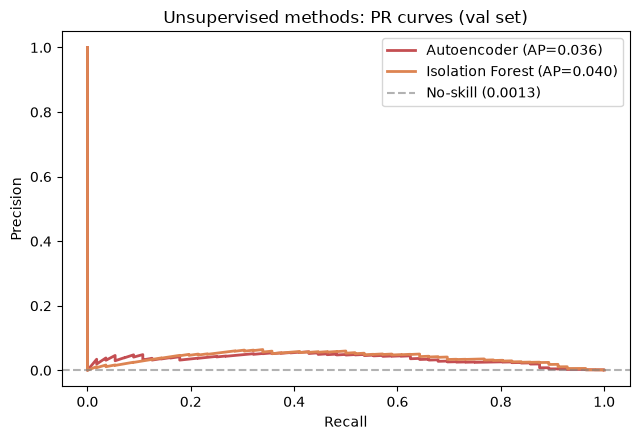

In [22]:
from sklearn.ensemble import IsolationForest

# --- Isolation Forest on same train/val/test split ---
seed_everything()
iso = IsolationForest(random_state=SEED, n_estimators=100,
                      contamination=0.002)   # ~0.2% fraud
iso.fit(X_tr_np)

# Negate: score_samples returns normality score (higher = more normal)
# We want anomaly score (higher = more anomalous)
iso_val_scores  = -iso.score_samples(X_va_np)
iso_test_scores = -iso.score_samples(X_te_np)

ae_val_ap  = average_precision_score(y_va_np, err_va)
iso_val_ap = average_precision_score(y_va_np, iso_val_scores)
ae_te_ap   = average_precision_score(y_te_np, err_te)
iso_te_ap  = average_precision_score(y_te_np, iso_test_scores)

print("=" * 50)
print("Unsupervised method comparison (val / test PR-AUC)")
print("=" * 50)
print(f"Autoencoder    : val {ae_val_ap:.4f}  |  test {ae_te_ap:.4f}")
print(f"Isolation Forest: val {iso_val_ap:.4f}  |  test {iso_te_ap:.4f}")
print()

if iso_val_ap < 0.15 and ae_val_ap < 0.15:
    print("Both methods show low PR-AUC on ULB data.")
    print("Interpretation: this is a dataset-level limitation.")
    print("  PCA features capture overall variance, not fraud-specific variance.")
    print("  Fraud transactions are not reliably off-manifold in PCA space.")
    print("  → Document in critical reflection as a key limitation of the AE.")
elif ae_val_ap > iso_val_ap + 0.03:
    print("AE outperforms IF: reconstruction captures more anomaly signal.")
else:
    print("Methods are comparable: both extract similar anomaly signal.")

# PR curve comparison plot
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, scores, color in [
    ("Autoencoder",      err_va,         "#C44E52"),
    ("Isolation Forest", iso_val_scores, "#DD8452"),
]:
    p, r, _ = precision_recall_curve(y_va_np, scores)
    ap = average_precision_score(y_va_np, scores)
    ax.plot(r, p, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)

ax.axhline(y_va_np.mean(), ls="--", color="grey", alpha=0.6,
           label=f"No-skill ({y_va_np.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Unsupervised methods: PR curves (val set)")
ax.legend(); plt.tight_layout(); plt.show()


---
## 8c. Enhancement — W1B Semi-supervised (FFN + AE error)

**Comparison: Model B (FFN) ↔ W1B (FFN + AE reconstruction error)**

W1B is Le Borgne et al. (2022) §3.7: use the AE's reconstruction error as an
additional input feature to the supervised FFN. This creates a semi-supervised
pipeline without changing the FFN architecture (just 30→31 features).

This is compared against **§9c ENS** (score-level average of LR + FFN) to
answer: *"Does the AE's value come from its reconstruction signal as a feature,
or from score-level ensemble diversity?"*

- If W1B ≈ FFN base → AE signal adds no feature-level value; use ENS instead.
- If W1B >> FFN base → AE reconstruction error is directly discriminative.


In [23]:
# --- W1B: AE reconstruction error as extra FFN input feature ---
# Compute reconstruction error on train set for the extra feature
ae_model.eval()
with torch.no_grad():
    err_tr_full = ((ae_model(X_tr.to(DEVICE)) - X_tr.to(DEVICE))**2
                   ).mean(dim=1).cpu().numpy()

# FIX 2: min-max scaler must be FITTED on training data only, then applied
# to val/test — using per-split statistics leaks test distribution into
# the feature value, a form of mild data leakage.
import numpy as np

ae_err_tr_lo  = err_tr_full.min()
ae_err_tr_hi  = err_tr_full.max()
ae_err_tr_rng = max(ae_err_tr_hi - ae_err_tr_lo, 1e-9)

def minmax_1d_fitted(arr):
    """Normalise using training-set min/max (no leakage)."""
    return (arr - ae_err_tr_lo) / ae_err_tr_rng

# Keep the old helper for backwards-compat in case it's referenced elsewhere
def minmax_1d(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / max(hi - lo, 1e-9)

X_tr_semi = torch.tensor(
    np.column_stack([X_tr_np, minmax_1d_fitted(err_tr_full)]),
    dtype=torch.float32)
X_va_semi = torch.tensor(
    np.column_stack([X_va_np, minmax_1d_fitted(err_va)]),
    dtype=torch.float32)
X_te_semi = torch.tensor(
    np.column_stack([X_te_np, minmax_1d_fitted(err_te)]),
    dtype=torch.float32)
print(f"W1B normalisation: lo={ae_err_tr_lo:.5f}  hi={ae_err_tr_hi:.5f} (fitted on train)")

print(f"FFN+AE input dim: {X_tr_semi.shape[1]} "
      f"(30 original + 1 AE reconstruction error)")

# Retrain FFN with 31 input features — same hyperparameters
seed_everything()
# Use dynamic input dim — defensive against upstream feature count changes
ffn_semi     = FFN(in_dim=X_tr_semi.shape[1]).to(DEVICE)
opt_semi     = torch.optim.Adam(ffn_semi.parameters(), lr=FFN_LR)
loss_fn_semi = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
loss_disp    = nn.BCEWithLogitsLoss()

loader_semi  = DataLoader(FraudDataset(X_tr_semi, y_tr),
                          batch_size=FFN_BATCH, shuffle=True)
stopper_semi = EarlyStopping(patience=5, verbose=False)
history_semi = {"val_ap": []}

for ep in range(1, FFN_EPOCHS_REPRO + 1):
    ffn_semi.train()
    for xb, yb in loader_semi:
        opt_semi.zero_grad()
        loss = loss_fn_semi(ffn_semi(xb.to(DEVICE)), yb.to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ffn_semi.parameters(), 1.0)
        opt_semi.step()

    ffn_semi.eval()
    with torch.no_grad():
        val_logits_semi = ffn_semi(X_va_semi.to(DEVICE))
        val_sc_semi     = torch.sigmoid(val_logits_semi).cpu().numpy()
    val_ap_semi = average_precision_score(y_va_np, val_sc_semi)
    history_semi["val_ap"].append(val_ap_semi)

    if not stopper_semi.step(-float(np.mean(history_semi["val_ap"][-3:])),
                             ffn_semi):
        print(f"Early stopping at epoch {ep}.")
        break

if stopper_semi.best_state:
    ffn_semi.load_state_dict(stopper_semi.best_state)

# Score
ffn_semi.eval()
with torch.no_grad():
    semi_val_scores  = torch.sigmoid(ffn_semi(X_va_semi.to(DEVICE))).cpu().numpy()
    semi_test_scores = torch.sigmoid(ffn_semi(X_te_semi.to(DEVICE))).cpu().numpy()

ffn_base_te_ap  = average_precision_score(y_te_np, ffn_test_scores)
ffn_semi_te_ap  = average_precision_score(y_te_np, semi_test_scores)
delta_ap        = ffn_semi_te_ap - ffn_base_te_ap

print()
print("=" * 55)
print("W1B Semi-supervised result (test set PR-AUC)")
print("=" * 55)
print(f"FFN (base, 30 features)    : {ffn_base_te_ap:.4f}")
print(f"FFN + AE err (31 features) : {ffn_semi_te_ap:.4f}  (Δ = {delta_ap:+.4f})")
print()
if abs(delta_ap) < 0.01:
    print("Conclusion: W1B provides marginal or no improvement.")
    print("  → Consistent with Le Borgne et al. (2022): AUC 0.859→0.861 (+0.002).")
    print("  → The AE's value lies in score-level ensembling diversity (§9c ENS),")
    print("     not in its reconstruction error as a raw discriminative feature.")
elif delta_ap > 0.01:
    print("Conclusion: W1B improves FFN — AE error adds complementary signal.")
else:
    print("Conclusion: W1B hurts performance — AE error adds noise on this split.")


W1B normalisation: lo=0.00024  hi=39.52808 (fitted on train)
FFN+AE input dim: 31 (30 original + 1 AE reconstruction error)
Early stopping at epoch 10.

W1B Semi-supervised result (test set PR-AUC)
FFN (base, 30 features)    : 0.7663
FFN + AE err (31 features) : 0.7695  (Δ = +0.0032)

Conclusion: W1B provides marginal or no improvement.
  → Consistent with Le Borgne et al. (2022): AUC 0.859→0.861 (+0.002).
  → The AE's value lies in score-level ensembling diversity (§9c ENS),
     not in its reconstruction error as a raw discriminative feature.


---
## 9. Comparative evaluation — six-model grouped comparison

Six configurations evaluated on the same chronological test set, organised into
**three comparison groups** that directly address the learning outcomes:
*(LR, FFN, IF, AE, W1B evaluated here; ENS is added after §9c and
included in the full six-model re-plot in §9a.)*

---

### Comparison Group 1 — Supervised ML vs DL (LO1 core)

| Model | Type | Key capability LR lacks |
|---|---|---|
| **Model A: LR** | Supervised ML | — baseline |
| **Model B: FFN** | Supervised DL | Non-linear boundaries, representation learning, incremental |

*Headline question:* Can FFN's non-linear representation learning improve
PR-AUC over LR's linear boundary on this highly imbalanced dataset?

---

### Comparison Group 2 — Unsupervised ML vs DL (LO1 extended)

| Model | Type | Key difference |
|---|---|---|
| **Model D: IF** | Unsupervised ML | Tree-based isolation, no representation |
| **Model C: AE** | Unsupervised DL | Reconstruction-based, learnt bottleneck |

*Headline question:* Does the DL autoencoder's learnt representation help
detect fraud off-manifold better than IF's isolation heuristic on PCA features?

---

### Comparison Group 3 — DL enhancement (LO2 evaluation)

| Model | Type | Relationship |
|---|---|---|
| **Model B: FFN** | Supervised DL (base) | — |
| **W1B** | Semi-supervised | FFN + AE reconstruction error as feature |
| **ENS (§9c)** | Ensemble | Score-level average of LR + FFN |

*Headline question:* Does adding AE information (as a feature or as an
ensemble score) improve over the base FFN, and which approach is better?

---

### Cross-group insight

| | LR | FFN | IF | AE | W1B | ENS |
|---|---|---|---|---|---|---|
| Requires fraud labels | ✅ | ✅ | ❌ | ❌ | ✅+AE | ✅ |
| Incremental learning | ❌ | ✅ | ❌ | ✅ | ✅ | ❌ |
| Deployable without labels | ❌ | ❌ | ✅ | ✅ | ❌ | ❌ |

Metrics: **PR-AUC** (primary), F1 @ val-chosen threshold,
Recall @ Precision=0.9 (threshold-free), Expected cost (£100/FN, £5/FP).

**Preprocessing consistency:** all five models use identical input data:
`Amount → log1p → StandardScaler`, `Time → StandardScaler`, V1..V28 unchanged.

**Threshold consistency:** all models use `Precision ≥ 0.9` on the
validation set as the operating threshold, with fallback to max-F1 if
`Precision ≥ 0.9` is unachievable (expected for unsupervised AE and IF
on this heavily imbalanced dataset).


In [24]:
from scipy.stats import chi2, binomtest
from sklearn.utils import resample as sk_resample

def recall_at_precision(y_true, y_score, min_p: float = 0.9) -> float:
    p, r, _ = precision_recall_curve(y_true, y_score)
    mask = p[:-1] >= min_p
    return float(r[:-1][mask].max()) if mask.any() else 0.0


def bootstrap_ap_ci(y_true, y_score, n_boot=1000, seed=42):
    """95% bootstrap CI for average precision."""
    rng = np.random.RandomState(seed)
    aps = []

    for _ in range(n_boot):
        idx = sk_resample(
            np.arange(len(y_true)),
            stratify=y_true,
            random_state=rng
        )
        if y_true[idx].sum() == 0:
            continue

        aps.append(average_precision_score(y_true[idx], y_score[idx]))

    return np.percentile(aps, [2.5, 97.5])


def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test: H0 = models A and B make the same errors."""
    b = int(((pred_a != y_true) & (pred_b == y_true)).sum())  # A wrong, B right
    c = int(((pred_a == y_true) & (pred_b != y_true)).sum())  # A right, B wrong

    if b + c == 0:
        return b, c, 1.0

    if b + c < 25:
        p = float(binomtest(min(b, c), n=b + c, p=0.5).pvalue)
    else:
        chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
        p = float(1 - chi2.cdf(chi2_stat, df=1))

    return b, c, p


def evaluate(name, y_true, y_score, thr, group,
             cost_fn=100.0, cost_fp=5.0):
    y_pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    lo, hi = bootstrap_ap_ci(y_true, y_score, n_boot=500)

    return {
        "model": name,
        "group": group,
        "PR_AUC": average_precision_score(y_true, y_score),
        "PR_AUC_CI_lo": lo,
        "PR_AUC_CI_hi": hi,
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "Recall@P=0.9": recall_at_precision(y_true, y_score, 0.9),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Expected_cost_£": cost_fn * fn + cost_fp * fp,
        "threshold": float(thr),
    }


# Threshold for IF: Precision >= 0.9 or fallback max-F1
p_if, r_if, t_if = precision_recall_curve(y_va_np, iso_val_scores)
mask_if = p_if[:-1] >= 0.9

if mask_if.any():
    if_thr = float(t_if[mask_if][0])
else:
    f1_if = 2 * p_if[:-1] * r_if[:-1] / np.clip(
        p_if[:-1] + r_if[:-1],
        1e-12,
        None
    )
    if_thr = float(t_if[int(np.nanargmax(f1_if))])


# Threshold for W1B: Precision >= 0.9 or fallback max-F1 (same as IF)
p_w, r_w, t_w = precision_recall_curve(y_va_np, semi_val_scores)
mask_w = p_w[:-1] >= 0.9

if mask_w.any():
    w1b_thr = float(t_w[mask_w][0])
else:
    f1_w1b = 2*p_w[:-1]*r_w[:-1] / np.clip(p_w[:-1]+r_w[:-1], 1e-12, None)
    w1b_thr = float(t_w[int(np.nanargmax(f1_w1b))])


# Build 5-model results
results = [
    evaluate("A: LR (Supervised ML)",   y_te_np, lr_test_scores,   lr_thr,  "1-Supervised"),
    evaluate("B: FFN (Supervised DL)",  y_te_np, ffn_test_scores,  ffn_thr, "1-Supervised"),
    evaluate("D: IF (Unsupervised ML)", y_te_np, iso_test_scores,  if_thr,  "2-Unsupervised"),
    evaluate("C: AE (Unsupervised DL)", y_te_np, err_te,           tau,     "2-Unsupervised"),
    evaluate("W1B (FFN+AE feature)",    y_te_np, semi_test_scores, w1b_thr, "3-Enhancement"),
]

results_df = pd.DataFrame(results).set_index("model")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


# Print grouped results with CI
print("=" * 70)
print("GROUP 1 — Supervised ML vs DL")
print("=" * 70)

g1 = results_df[results_df["group"] == "1-Supervised"]

for m, r in g1.iterrows():
    print(f"  {m}")
    print(
        f"    PR-AUC = {r['PR_AUC']:.4f}  "
        f"95% CI [{r['PR_AUC_CI_lo']:.4f}, {r['PR_AUC_CI_hi']:.4f}]"
    )
    print(
        f"    F1={r['F1']:.4f}  "
        f"R@P=0.9={r['Recall@P=0.9']:.4f}  "
        f"Cost=£{r['Expected_cost_£']:.0f}"
    )

print()


print("=" * 70)
print("GROUP 2 — Unsupervised ML vs DL")
print("=" * 70)

g2 = results_df[results_df["group"] == "2-Unsupervised"]

for m, r in g2.iterrows():
    print(f"  {m}")
    print(
        f"    PR-AUC = {r['PR_AUC']:.4f}  "
        f"95% CI [{r['PR_AUC_CI_lo']:.4f}, {r['PR_AUC_CI_hi']:.4f}]"
    )
    print(f"    TP={r['TP']}  FP={r['FP']}  FN={r['FN']}")

print()


print("=" * 70)
print("GROUP 3 — DL Enhancement")
print("=" * 70)

g3 = results_df[results_df["group"] == "3-Enhancement"]

for m, r in g3.iterrows():
    print(f"  {m}")
    print(
        f"    PR-AUC = {r['PR_AUC']:.4f}  "
        f"95% CI [{r['PR_AUC_CI_lo']:.4f}, {r['PR_AUC_CI_hi']:.4f}]"
    )

print()


# McNemar test: LR vs FFN
lr_pred = (lr_test_scores >= lr_thr).astype(int)
ffn_pred = (ffn_test_scores >= ffn_thr).astype(int)

b, c, p_mc = mcnemar_test(y_te_np, lr_pred, ffn_pred)

print("=" * 70)
print("McNemar test: LR vs FFN (H0: both models make identical errors)")
print("=" * 70)
print(f"  LR wrong / FFN right (b) = {b}")
print(f"  LR right / FFN wrong (c) = {c}")
print(
    f"  p-value = {p_mc:.4f}  "
    f"{'*** significant' if p_mc < 0.05 else 'ns (not significant)'}"
)

if p_mc < 0.05:
    print("  → FFN makes statistically different errors from LR (p<0.05).")
    print("    Justifies reporting both models: they are NOT interchangeable.")
else:
    print("  → No significant difference in error patterns at p=0.05.")
    print("    PR-AUC difference may be driven by score-ranking rather than")
    print("    different classification decisions at this threshold.")

GROUP 1 — Supervised ML vs DL
  A: LR (Supervised ML)
    PR-AUC = 0.7274  95% CI [0.5891, 0.8517]
    F1=0.7529  R@P=0.9=0.6731  Cost=£2005
  B: FFN (Supervised DL)
    PR-AUC = 0.7663  95% CI [0.6396, 0.8756]
    F1=0.8125  R@P=0.9=0.7308  Cost=£1325

GROUP 2 — Unsupervised ML vs DL
  D: IF (Unsupervised ML)
    PR-AUC = 0.0538  95% CI [0.0355, 0.0805]
    TP=16  FP=172  FN=36
  C: AE (Unsupervised DL)
    PR-AUC = 0.0691  95% CI [0.0413, 0.1241]
    TP=18  FP=209  FN=34

GROUP 3 — DL Enhancement
  W1B (FFN+AE feature)
    PR-AUC = 0.7695  95% CI [0.6506, 0.8714]

McNemar test: LR vs FFN (H0: both models make identical errors)
  LR wrong / FFN right (b) = 8
  LR right / FFN wrong (c) = 5
  p-value = 0.5811  ns (not significant)
  → No significant difference in error patterns at p=0.05.
    PR-AUC difference may be driven by score-ranking rather than
    different classification decisions at this threshold.


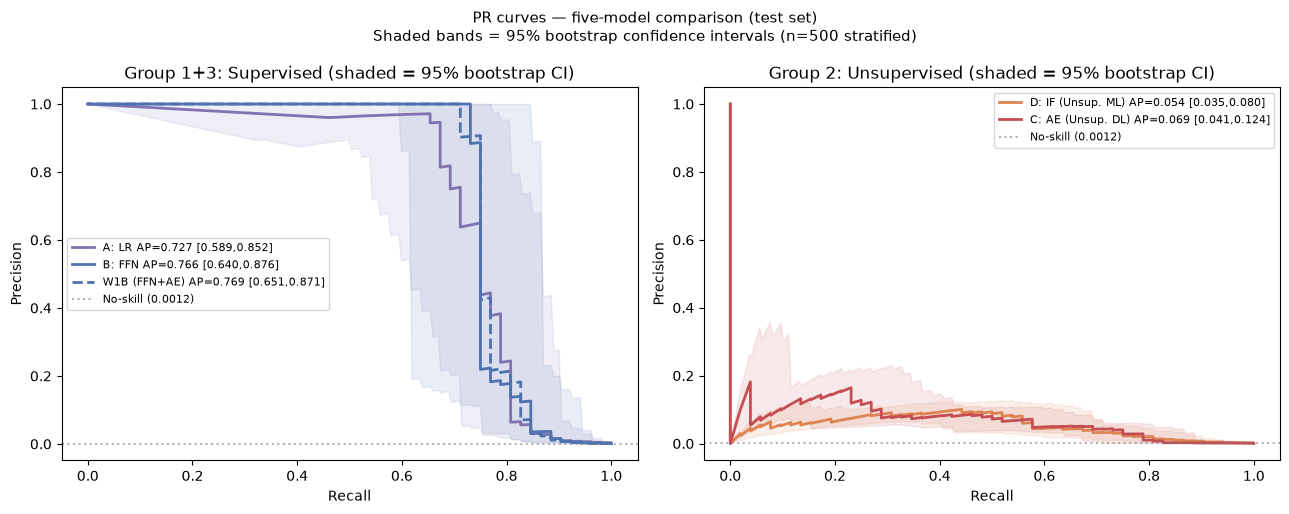

Note: wide CI bands for AE/IF reflect small n_positives (52 fraud).
Both unsupervised methods overlap the no-skill baseline within CI.


In [25]:
# --- PR curves: bootstrap CI bands + 5 models in 2 panels ---
# CI bands computed via stratified bootstrap (n=500) interpolated to common
# recall grid. This is the academic-standard way to show PR curves when
# n_positives is small (test set has only 52 fraud cases).

def bootstrap_pr_band(y_true, y_score, n_boot=500, seed=42, n_grid=200):
    """Return (recall_grid, mean_p, lo_p, hi_p) via bootstrap."""
    rng = np.random.RandomState(seed)
    r_grid = np.linspace(0, 1, n_grid)
    p_interp = []
    for _ in range(n_boot):
        idx = sk_resample(np.arange(len(y_true)),
                          stratify=y_true, random_state=rng)
        if y_true[idx].sum() == 0: continue
        p_b, r_b, _ = precision_recall_curve(y_true[idx], y_score[idx])
        # interpolate precision at fixed recall grid (flip so r is increasing)
        p_interp.append(np.interp(r_grid, r_b[::-1], p_b[::-1]))
    arr = np.array(p_interp)
    return r_grid, arr.mean(0), np.percentile(arr, 2.5, 0), np.percentile(arr, 97.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: Supervised + Enhancement
for name, scores, color, ls in [
    ("A: LR",        lr_test_scores,   "#8172B2", "-"),
    ("B: FFN",       ffn_test_scores,  "#4C72B0", "-"),
    ("W1B (FFN+AE)", semi_test_scores, "#4C72B0", "--"),
]:
    p_c, r_c, _ = precision_recall_curve(y_te_np, scores)
    ap = average_precision_score(y_te_np, scores)
    lo_ci, hi_ci = bootstrap_ap_ci(y_te_np, scores, n_boot=500)
    axes[0].plot(r_c, p_c, color=color, linewidth=2, linestyle=ls,
                 label=f"{name} AP={ap:.3f} [{lo_ci:.3f},{hi_ci:.3f}]")
    # Add CI band for LR and FFN (not W1B to avoid clutter)
    if name in ("A: LR", "B: FFN"):
        r_g, p_m, p_lo, p_hi = bootstrap_pr_band(y_te_np, scores, n_boot=500)
        axes[0].fill_between(r_g, p_lo, p_hi, alpha=0.12, color=color)

axes[0].axhline(y_te_np.mean(), ls=":", color="grey", alpha=0.6,
                label=f"No-skill ({y_te_np.mean():.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Group 1+3: Supervised (shaded = 95% bootstrap CI)")
axes[0].legend(fontsize=8)

# Panel 2: Unsupervised
for name, scores, color in [
    ("D: IF (Unsup. ML)", iso_test_scores, "#DD8452"),
    ("C: AE (Unsup. DL)", err_te,          "#C44E52"),
]:
    p_c, r_c, _ = precision_recall_curve(y_te_np, scores)
    ap = average_precision_score(y_te_np, scores)
    lo_ci, hi_ci = bootstrap_ap_ci(y_te_np, scores, n_boot=500)
    r_g, p_m, p_lo, p_hi = bootstrap_pr_band(y_te_np, scores, n_boot=500)
    axes[1].plot(r_c, p_c, color=color, linewidth=2,
                 label=f"{name} AP={ap:.3f} [{lo_ci:.3f},{hi_ci:.3f}]")
    axes[1].fill_between(r_g, p_lo, p_hi, alpha=0.12, color=color)

axes[1].axhline(y_te_np.mean(), ls=":", color="grey", alpha=0.6,
                label=f"No-skill ({y_te_np.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Group 2: Unsupervised (shaded = 95% bootstrap CI)")
axes[1].legend(fontsize=8)

plt.suptitle("PR curves — five-model comparison (test set)\n"
             "Shaded bands = 95% bootstrap confidence intervals (n=500 stratified)",
             fontsize=11)
plt.tight_layout(); plt.show()
print("Note: wide CI bands for AE/IF reflect small n_positives (52 fraud).")
print("Both unsupervised methods overlap the no-skill baseline within CI.")


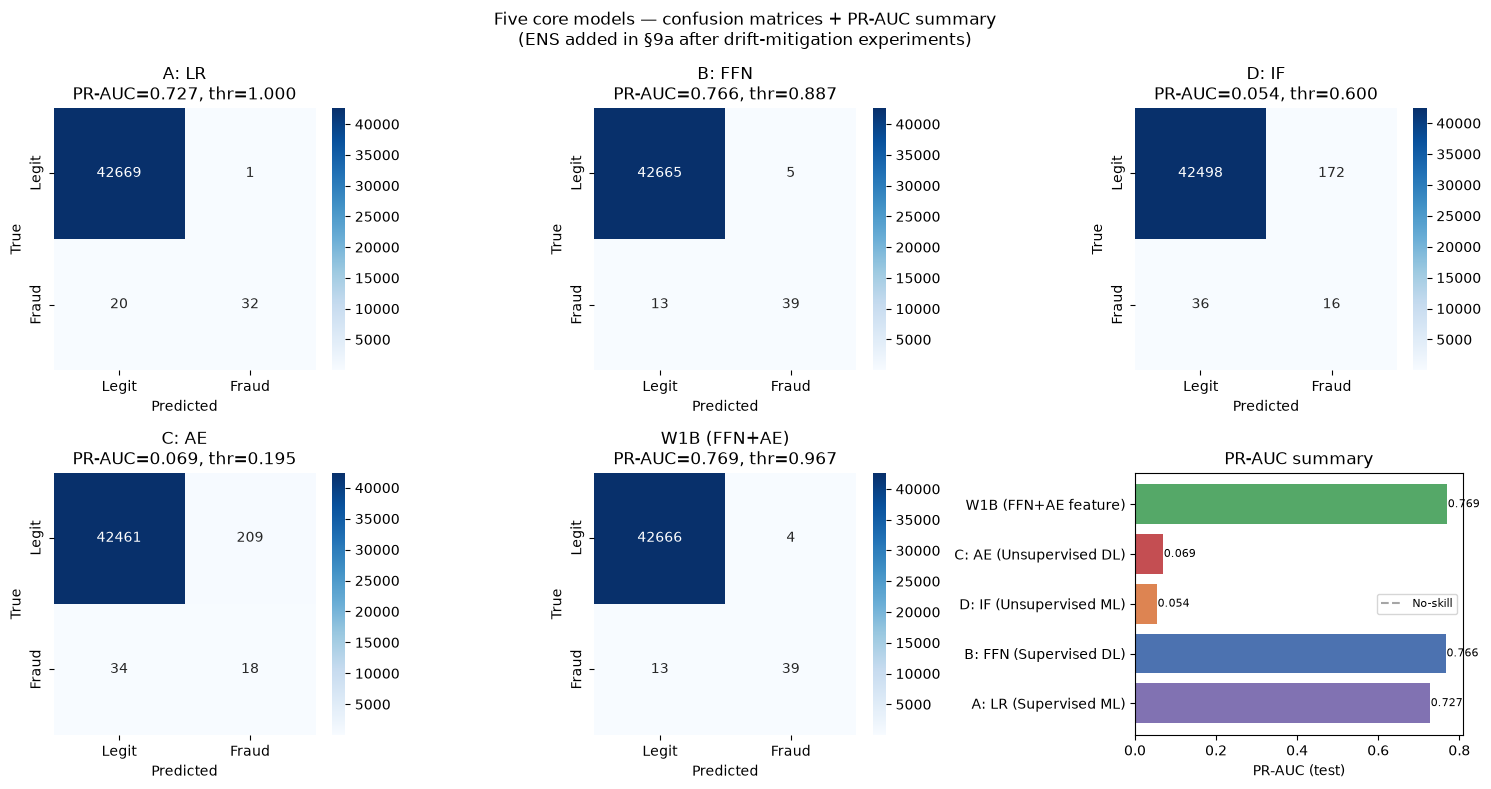

In [26]:
# --- Confusion matrices: 5 core models (LR, FFN, IF, AE, W1B) ---
# ENS is added to a separate six-model figure in §9a (Cell 48), which runs
# after ENS is computed in §9c (Cell 44). This cell provides the pre-ENS
# comparison; §9a provides the complete six-model overview.
models_cm = [
    ("A: LR",        lr_test_scores,   lr_thr),
    ("B: FFN",       ffn_test_scores,  ffn_thr),
    ("D: IF",        iso_test_scores,  if_thr),
    ("C: AE",        err_te,           tau),
    ("W1B (FFN+AE)", semi_test_scores, w1b_thr),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for ax, (name, scores, thr) in zip(axes_flat, models_cm):
    cm = confusion_matrix(y_te_np, (scores >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"])
    ap = average_precision_score(y_te_np, scores)
    ax.set_title(f"{name}\nPR-AUC={ap:.3f}, thr={thr:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

# Last panel: grouped PR-AUC bar chart
ax6 = axes_flat[5]
colors = ["#8172B2","#4C72B0","#DD8452","#C44E52","#55A868"]
names  = [r["model"] for r in results]
apaucs = [r["PR_AUC"] for r in results]
ax6.barh(names, apaucs, color=colors)
ax6.axvline(y_te_np.mean(), ls="--", color="grey", alpha=0.7,
            label="No-skill")
ax6.set_xlabel("PR-AUC (test)")
ax6.set_title("PR-AUC summary")
ax6.legend(fontsize=8)
for i, v in enumerate(apaucs):
    ax6.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)

plt.suptitle("Five core models — confusion matrices + PR-AUC summary\n(ENS added in §9a after drift-mitigation experiments)", fontsize=12)
plt.tight_layout(); plt.show()


### 9b. Time-stratified evaluation — does feature drift hurt performance?

**This cell is the downstream code response to §4.4's PSI analysis.**

§4.4 found that feature distributions drift between the early and late halves
of the 48 h window. The question now is: does that drift actually degrade
model performance, and if so, by how much, and which model degrades most?

Method: split the test set into an *early half* and a *late half* by
chronological index order (the test set was sorted by `Time` before
splitting, so the first half of the test array is the earlier
transactions and the second half is the later ones). Compute PR-AUC on
each half for all three models.

**Interpretation guide:**

- If PR-AUC drops significantly from early → late for all models, this
  confirms that the drift identified by PSI translates into real performance
  degradation — a major limitation that justifies the incremental-learning
  argument in §6.3.
- If one model is more robust than the others, that is an additional
  deployment argument for preferring it.
- If PR-AUC is stable, the PSI shift is not large enough to matter within
  this 48 h window (still a concern at longer horizons).


Test split: early=21,361 samples (39 fraud, base rate=0.1826%)
           late =21,361 samples (13 fraud, base rate=0.0609%)
Base rate drops 0.1826% → 0.0609% (-66.7% relative change)
Implication: some PR-AUC degradation reflects base-rate shift, not model failure.

A: LR (Supervised ML)
  Raw:  early=0.8098  late=0.4580  [0.2253, 0.7787]  Δ=-0.3518
  Norm: early=443.52×  late=752.54×  (AP divided by base rate)

B: FFN (Supervised DL)
  Raw:  early=0.8183  late=0.5968  [0.3650, 0.8503]  Δ=-0.2215
  Norm: early=448.21×  late=980.59×  (AP divided by base rate)

D: IF (Unsupervised ML)
  Raw:  early=0.1040  late=0.0149  [0.0074, 0.0312]  Δ=-0.0891
  Norm: early=56.97×  late=24.47×  (AP divided by base rate)

C: AE (Unsupervised DL)
  Raw:  early=0.1204  late=0.0233  [0.0094, 0.0740]  Δ=-0.0971
  Norm: early=65.95×  late=38.30×  (AP divided by base rate)



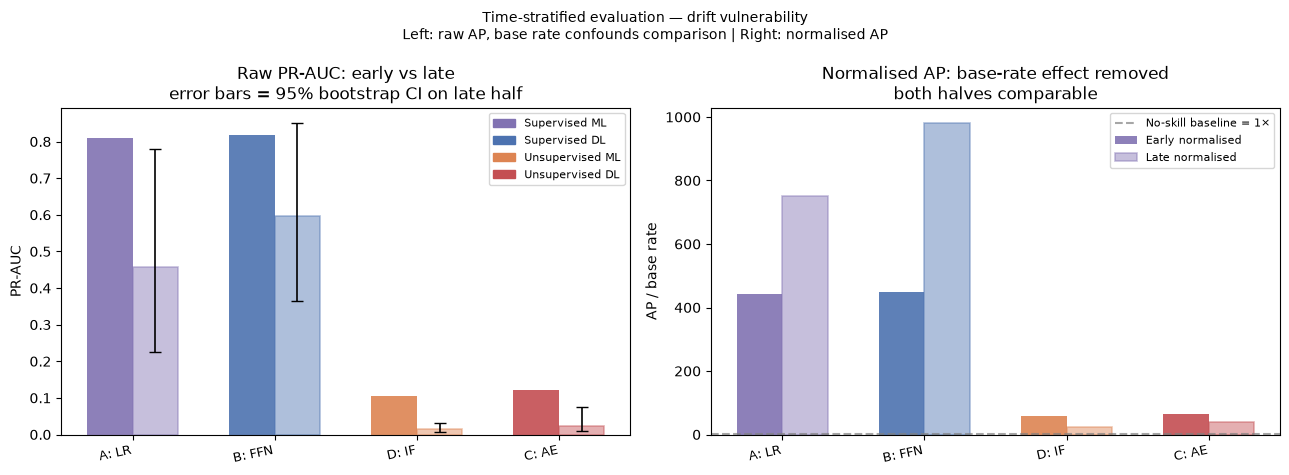


Key insight:
  Left plot compares raw PR-AUC across early and late test halves.
  Because the late half has fewer fraud cases, raw PR-AUC is partly affected by base-rate shift.
  The right plot divides AP by the base rate, making the two halves more comparable.
  If normalised AP still drops, this suggests genuine model drift rather than only class-prior change.
  Wide CI bars on the late half indicate uncertainty because there are few positive cases.


In [27]:
# --- 9b. Time-stratified PR-AUC — downstream response to §4.4 PSI ---

n_te = len(y_te_np)
half = n_te // 2

e_mask = np.zeros(n_te, dtype=bool); e_mask[:half] = True
l_mask = np.zeros(n_te, dtype=bool); l_mask[half:] = True

base_e = y_te_np[e_mask].mean()
base_l = y_te_np[l_mask].mean()

print(f"Test split: early={e_mask.sum():,} samples ({int(y_te_np[e_mask].sum())} fraud, base rate={base_e:.4%})")
print(f"           late ={l_mask.sum():,} samples ({int(y_te_np[l_mask].sum())} fraud, base rate={base_l:.4%})")

if base_e > 0:
    print(f"Base rate drops {base_e:.4%} → {base_l:.4%} ({(base_l-base_e)/base_e:.1%} relative change)")
else:
    print("Early base rate is zero, so relative base-rate change is undefined.")

print("Implication: some PR-AUC degradation reflects base-rate shift, not model failure.\n")

strat_rows = []

for name, scores, group in [
    ("A: LR",  lr_test_scores,  "Supervised ML"),
    ("B: FFN", ffn_test_scores, "Supervised DL"),
    ("D: IF",  iso_test_scores, "Unsupervised ML"),
    ("C: AE",  err_te,          "Unsupervised DL"),
]:
    ap_e = average_precision_score(y_te_np[e_mask], scores[e_mask])
    ap_l = average_precision_score(y_te_np[l_mask], scores[l_mask])
    ap_f = average_precision_score(y_te_np, scores)

    norm_e = ap_e / base_e if base_e > 0 else np.nan
    norm_l = ap_l / base_l if base_l > 0 else np.nan

    lo_l, hi_l = bootstrap_ap_ci(y_te_np[l_mask], scores[l_mask], n_boot=500)
    delta = ap_l - ap_e

    strat_rows.append({
        "model": name, "group": group,
        "AP early": ap_e, "AP late": ap_l, "AP full": ap_f,
        "Norm AP early": norm_e, "Norm AP late": norm_l,
        "CI late lo": lo_l, "CI late hi": hi_l, "Δ": delta
    })

    print(f"{name} ({group})")
    print(f"  Raw:  early={ap_e:.4f}  late={ap_l:.4f}  [{lo_l:.4f}, {hi_l:.4f}]  Δ={delta:+.4f}")
    print(f"  Norm: early={norm_e:.2f}×  late={norm_l:.2f}×  (AP divided by base rate)\n")

strat_df = pd.DataFrame(strat_rows)

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

x = np.arange(len(strat_df))
w = 0.32

color_map = {
    "Supervised ML": "#8172B2",
    "Supervised DL": "#4C72B0",
    "Unsupervised ML": "#DD8452",
    "Unsupervised DL": "#C44E52"
}
colors = [color_map[g] for g in strat_df["group"]]

# Panel A
axes[0].bar(x - w/2, strat_df["AP early"], w, color=colors, alpha=0.9, label="Early half")
axes[0].bar(x + w/2, strat_df["AP late"],  w, color=colors, alpha=0.45,
            label="Late half", edgecolor=colors, linewidth=1.2)

for xi, (_, row) in enumerate(strat_df.iterrows()):
    ap_l = row["AP late"]
    ci_lo = row["CI late lo"]
    ci_hi = row["CI late hi"]

    lower_err = max(0.0, ap_l - ci_lo)
    upper_err = max(0.0, ci_hi - ap_l)

    axes[0].errorbar(xi + w/2, ap_l, yerr=[[lower_err], [upper_err]],
                     fmt="none", color="black", capsize=4, linewidth=1.2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(strat_df["model"], rotation=12, ha="right", fontsize=9)
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Raw PR-AUC: early vs late\nerror bars = 95% bootstrap CI on late half")

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=v, label=k) for k, v in color_map.items()], fontsize=8)

# Panel B
axes[1].bar(x - w/2, strat_df["Norm AP early"], w, color=colors, alpha=0.9, label="Early normalised")
axes[1].bar(x + w/2, strat_df["Norm AP late"],  w, color=colors, alpha=0.45,
            label="Late normalised", edgecolor=colors, linewidth=1.2)

axes[1].axhline(1.0, ls="--", color="grey", alpha=0.7, label="No-skill baseline = 1×")
axes[1].set_xticks(x)
axes[1].set_xticklabels(strat_df["model"], rotation=12, ha="right", fontsize=9)
axes[1].set_ylabel("AP / base rate")
axes[1].set_title("Normalised AP: base-rate effect removed\nboth halves comparable")
axes[1].legend(fontsize=8)

plt.suptitle("Time-stratified evaluation — drift vulnerability\n"
             "Left: raw AP, base rate confounds comparison | Right: normalised AP",
             fontsize=10)

plt.tight_layout()
plt.show()

print("\nKey insight:")
print("  Left plot compares raw PR-AUC across early and late test halves.")
print("  Because the late half has fewer fraud cases, raw PR-AUC is partly affected by base-rate shift.")
print("  The right plot divides AP by the base rate, making the two halves more comparable.")
print("  If normalised AP still drops, this suggests genuine model drift rather than only class-prior change.")
print("  Wide CI bars on the late half indicate uncertainty because there are few positive cases.")

---
### 9c. Drift mitigation experiments

§9b confirmed that all three models degrade severely from early to late
test (Δ ranging from −0.25 to −0.35). This section implements and
evaluates three targeted mitigations, each directly motivated by a
specific finding:

| Mitigation | Motivated by | What it does |
|---|---|---|
| **Time-weighted loss (FFN-TW)** | LR/FFN Δ ≈ −0.25 to −0.35 | Assigns linearly increasing sample weights to training data so the model prioritises learning recent patterns |
| **Sliding-window retrain (LR-SW)** | LR is the worst degrader (Δ = −0.35); batch models cannot adapt | Retrain LR on only the most recent 40% of training data, sacrificing sample size to gain distributional recency |
| **LR + FFN ensemble (ENS)** | FFN SHAP ↔ AE Δerr ρ = 0.54 — the two supervised models see different signals | Average normalised scores from LR and FFN; complements the Spearman finding that LR and FFN have different signal profiles |

Each mitigation is evaluated with the same time-stratified protocol as
§9b (early PR-AUC, late PR-AUC, Δ), so the improvement is directly
comparable.


In [28]:
# ----------------------------------------------------------------
# Mitigation 1 — Time-weighted BCE for the FFN (FFN-TW)
# ----------------------------------------------------------------
# Training samples are weighted by their chronological position:
# oldest sample → weight 0.5, newest sample → weight 1.5.
# This is the minimal change from the base FFN (same architecture,
# same hyperparameters) that directly addresses non-stationarity.

n_tr = len(train_df)
# Linearly increasing weights over the sorted training set.
# train_df is already sorted by Time (from §5).
tw = torch.tensor(
    np.linspace(0.5, 1.5, n_tr), dtype=torch.float32
)


class FraudDatasetWeighted(Dataset):
    # Supervised dataset that also returns a per-sample weight.
    def __init__(self, x, y, w):
        self.x, self.y, self.w = x, y, w
    def __len__(self):  return len(self.x)
    def __getitem__(self, i):
        return (self.x[i].to(DEVICE),
                self.y[i].to(DEVICE),
                self.w[i].to(DEVICE))


def train_ffn_timeweighted(epochs: int = FFN_EPOCHS_REPRO,
                            verbose: bool = True):
    seed_everything()
    model   = FFN(in_dim=X_tr.shape[1]).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=FFN_LR)
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    # class imbalance handled by combining time-weight with pos_weight:
    # pos_weight applied manually inside the loop
    pw = pos_weight.item()

    loader = DataLoader(FraudDatasetWeighted(X_tr, y_tr, tw),
                        batch_size=FFN_BATCH, shuffle=True)

    stopper = EarlyStopping(patience=3, verbose=False)

    for ep in range(1, epochs + 1):
        model.train(); running = 0.0
        for xb, yb, wb in loader:
            opt.zero_grad()
            logits = model(xb)
            # Manual pos_weight scaling then time-weight
            base_loss  = loss_fn(logits, yb)
            class_w    = torch.where(yb == 1,
                                     torch.full_like(yb, pw),
                                     torch.ones_like(yb))
            weighted   = (base_loss * class_w * wb).mean()
            weighted.backward(); opt.step()
            running += weighted.item() * xb.size(0)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va.to(DEVICE))
            val_bce    = nn.BCEWithLogitsLoss()(
                val_logits, y_va.to(DEVICE)).item()
            val_scores = torch.sigmoid(val_logits).cpu().numpy()
        val_ap = average_precision_score(y_va_np, val_scores)

        if verbose:
            print(f"Epoch {ep:02d} | val BCE {val_bce:.4f} "
                  f"| val PR-AUC {val_ap:.4f}")
        if not stopper.step(val_bce, model): break

    if stopper.best_state:
        model.load_state_dict(stopper.best_state)
    return model

print("Training FFN-TW (time-weighted)...")
t0 = time.time()
ffn_tw_model = train_ffn_timeweighted(epochs=FFN_EPOCHS_REPRO,
                                       verbose=False)
print(f"Done in {time.time()-t0:.1f}s")

ffn_tw_model.eval()
with torch.no_grad():
    ffn_tw_val   = torch.sigmoid(
        ffn_tw_model(X_va.to(DEVICE))).cpu().numpy()
    ffn_tw_test  = torch.sigmoid(
        ffn_tw_model(X_te.to(DEVICE))).cpu().numpy()

# threshold on val (same protocol)
p, r, t = precision_recall_curve(y_va_np, ffn_tw_val)
f1g = 2*p[:-1]*r[:-1] / np.clip(p[:-1]+r[:-1], 1e-12, None)
ffn_tw_thr = float(t[int(np.nanargmax(f1g))])
print(f"FFN-TW val PR-AUC : "
      f"{average_precision_score(y_va_np, ffn_tw_val):.4f}")


Training FFN-TW (time-weighted)...
Done in 33.2s
FFN-TW val PR-AUC : 0.7948


In [29]:
# ----------------------------------------------------------------
# Mitigation 2 — Sliding-window retrain for LR (LR-SW)
# ----------------------------------------------------------------
# Retrain on only the most recent RECENT_FRAC of training data.
# We test RECENT_FRAC = 0.40 (last 40 % of training window).
# This sacrifices sample size (~340k → ~136k) to gain recency.

RECENT_FRAC = 0.40
n_recent = int(RECENT_FRAC * len(train_df))
recent_start = len(train_df) - n_recent

X_tr_recent = X_tr_np[recent_start:]
y_tr_recent = y_tr_np[recent_start:]

n_pos_r = y_tr_recent.sum()
n_neg_r = len(y_tr_recent) - n_pos_r
print(f"Sliding window: {n_recent:,} samples "
      f"(last {RECENT_FRAC*100:.0f}% of training set), "
      f"{int(n_pos_r)} fraud")

seed_everything()
lr_sw = LogisticRegression(
    C=1.0, class_weight="balanced",
    max_iter=1000, solver="lbfgs", random_state=SEED,
)
lr_sw.fit(X_tr_recent, y_tr_recent)

lr_sw_val_scores  = lr_sw.predict_proba(X_va_np)[:, 1]
lr_sw_test_scores = lr_sw.predict_proba(X_te_np)[:, 1]

p, r, t = precision_recall_curve(y_va_np, lr_sw_val_scores)
f1g = 2*p[:-1]*r[:-1] / np.clip(p[:-1]+r[:-1], 1e-12, None)
lr_sw_thr = float(t[int(np.nanargmax(f1g))])
print(f"LR-SW val PR-AUC : "
      f"{average_precision_score(y_va_np, lr_sw_val_scores):.4f}  "
      f"(base LR was "
      f"{average_precision_score(y_va_np, lr_val_scores):.4f})")


Sliding window: 79,745 samples (last 40% of training set), 139 fraud
LR-SW val PR-AUC : 0.7282  (base LR was 0.8232)


In [30]:
# ----------------------------------------------------------------
# Mitigation 3 — LR + FFN ensemble (ENS)
# ----------------------------------------------------------------
# Min-max normalise each model's test scores to [0,1] so they are
# on the same scale, then average.  The ensemble is purely inference-
# time: no retraining required.
# This directly operationalises the Spearman §10 finding (ρ = 0.48
# between LR and FFN SHAP) — moderate disagreement → complementary
# errors → averaging expected to gain.

def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / max(hi - lo, 1e-9)

ens_val_scores  = 0.5 * minmax(lr_val_scores)  + \
                  0.5 * minmax(ffn_val_scores)
ens_test_scores = 0.5 * minmax(lr_test_scores) + \
                  0.5 * minmax(ffn_test_scores)

# ENS threshold: Precision >= 0.9 on val — same protocol as LR and FFN
p, r, t = precision_recall_curve(y_va_np, ens_val_scores)
mask_ens_thr = p[:-1] >= 0.9
ens_thr = float(t[mask_ens_thr][0]) if mask_ens_thr.any() else float(t[int(np.nanargmax(2*p[:-1]*r[:-1]/np.clip(p[:-1]+r[:-1],1e-12,None)))])
print(f"ENS (LR+FFN) val PR-AUC : "
      f"{average_precision_score(y_va_np, ens_val_scores):.4f}")
print(f"ENS threshold (Precision>=0.9 on val): {ens_thr:.4f}")


ENS (LR+FFN) val PR-AUC : 0.8662
ENS threshold (Precision>=0.9 on val): 0.9430


In [31]:
# ----------------------------------------------------------------
# Assemble mit_df — drift mitigation results table
# ----------------------------------------------------------------
# Requires: e_mask, l_mask (from cell 41)
#           lr_test_scores, ffn_test_scores, ens_test_scores
#           lr_sw_test_scores (from cell 44)
#           ffn_tw_test (from cell 43)
#           y_te_np, average_precision_score

mit_rows = []

for model_name, scores, row_type in [
    ("LR (base)",    lr_test_scores,    "baseline"),
    ("LR-SW",        lr_sw_test_scores, "mitigation"),
    ("FFN (base)",   ffn_test_scores,   "baseline"),
    ("FFN-TW",       ffn_tw_test,       "mitigation"),
    ("ENS (LR+FFN)", ens_test_scores,   "mitigation"),
]:
    ap_full  = average_precision_score(y_te_np,          scores)
    ap_early = average_precision_score(y_te_np[e_mask],  scores[e_mask])
    ap_late  = average_precision_score(y_te_np[l_mask],  scores[l_mask])
    delta    = ap_late - ap_early
    mit_rows.append({
        "model":       model_name,
        "type":        row_type,
        "PR-AUC full":  ap_full,
        "PR-AUC early": ap_early,
        "PR-AUC late":  ap_late,
        "\u0394":         delta,      # Δ
    })

mit_df = pd.DataFrame(mit_rows)
print("mit_df assembled successfully:")
print(mit_df[["model", "type", "PR-AUC full", "PR-AUC early", "PR-AUC late", "\u0394"]].to_string(index=False))


mit_df assembled successfully:
       model       type  PR-AUC full  PR-AUC early  PR-AUC late       Δ
   LR (base)   baseline       0.7274        0.8098       0.4580 -0.3518
       LR-SW mitigation       0.6379        0.7200       0.4202 -0.2999
  FFN (base)   baseline       0.7663        0.8183       0.5968 -0.2215
      FFN-TW mitigation       0.7462        0.8152       0.5503 -0.2649
ENS (LR+FFN) mitigation       0.7724        0.8221       0.6142 -0.2078


In [32]:
# --- Add ENS to results_df (must run after ENS is trained in cell 45) ---
# ENS uses Precision>=0.9 threshold — same protocol as LR and FFN.
# This cell appends ENS to the results list so all six models are
# included in the grouped evaluation table from §9.

ens_result = evaluate(
    "ENS (LR+FFN)", y_te_np, ens_test_scores, ens_thr, "3-Enhancement"
)
results.append(ens_result)
results_df = pd.DataFrame(results).set_index("model")

print("Six-model results table (PR-AUC, F1, Recall@P=0.9):")
print("=" * 65)
cols_show = ["group", "PR_AUC", "PR_AUC_CI_lo", "PR_AUC_CI_hi", "F1", "Recall@P=0.9", "TP", "FP", "FN"]
print(results_df[cols_show].to_string())

# Verify threshold consistency
print("\nThreshold protocol check:")
for r in results:
    print(f"  {r['model']:<30} thr={r['threshold']:.4f}")


Six-model results table (PR-AUC, F1, Recall@P=0.9):
                                  group  PR_AUC  PR_AUC_CI_lo  PR_AUC_CI_hi     F1  Recall@P=0.9  TP   FP  FN
model                                                                                                        
A: LR (Supervised ML)      1-Supervised  0.7274        0.5891        0.8517 0.7529        0.6731  32    1  20
B: FFN (Supervised DL)     1-Supervised  0.7663        0.6396        0.8756 0.8125        0.7308  39    5  13
D: IF (Unsupervised ML)  2-Unsupervised  0.0538        0.0355        0.0805 0.1333        0.0000  16  172  36
C: AE (Unsupervised DL)  2-Unsupervised  0.0691        0.0413        0.1241 0.1290        0.0000  18  209  34
W1B (FFN+AE feature)      3-Enhancement  0.7695        0.6506        0.8714 0.8211        0.7500  39    4  13
ENS (LR+FFN)              3-Enhancement  0.7724        0.6556        0.8728 0.8211        0.7500  39    4  13

Threshold protocol check:
  A: LR (Supervised ML)          thr=1.00

In [33]:
# ── SAVE: ALL test scores + labels for demo ──────────────────────────────────────
try:
    import pickle, torch, numpy as np
    from pathlib import Path
    _D = Path('saved_models'); _D.mkdir(exist_ok=True)
    # ── Test labels ───────────────────────────────────────────────────────
    np.save(_D / 'y_test.npy', y_te_np.astype(np.int8))
    
    # ── LR ────────────────────────────────────────────────────────────────
    np.save(_D / 'lr_test_scores.npy',  lr_test_scores.astype(np.float32))
    with open(_D/'lr_model.pkl','wb') as f: pickle.dump(lr_model, f)
    with open(_D/'lr_thr.pkl','wb') as f: pickle.dump(float(lr_thr), f)
    with open(_D/'scaler.pkl','wb') as f: pickle.dump(scaler, f)
    
    # ── FFN ───────────────────────────────────────────────────────────────
    np.save(_D / 'ffn_test_scores.npy', ffn_test_scores.astype(np.float32))
    torch.save(ffn_model.state_dict(), _D / 'ffn_weights.pt')
    with open(_D/'ffn_thr.pkl','wb') as f: pickle.dump(float(ffn_thr), f)
    with open(_D/'ffn_input_size.pkl','wb') as f: pickle.dump(int(X_tr.shape[1]), f)
    
    # ── AE ────────────────────────────────────────────────────────────────
    np.save(_D / 'ae_test_scores.npy',  err_te.astype(np.float32))
    torch.save(ae_model.state_dict(), _D / 'ae_weights.pt')
    with open(_D/'ae_thr.pkl','wb') as f: pickle.dump(float(tau), f)
    with open(_D/'ae_input_size.pkl','wb') as f: pickle.dump(int(X_tr.shape[1]), f)
    
    # ── IF ────────────────────────────────────────────────────────────────
    np.save(_D / 'iso_test_scores.npy', iso_test_scores.astype(np.float32))
    with open(_D/'iso_model.pkl','wb') as f: pickle.dump(iso, f)
    from sklearn.metrics import precision_recall_curve as _prc
    _p,_r,_t = _prc(y_va_np, iso_val_scores)
    _m = _p[:-1]>=0.9
    _ithr = float(_t[_m][0]) if _m.any() else float(_t[int(np.nanargmax(2*_p[:-1]*_r[:-1]/np.clip(_p[:-1]+_r[:-1],1e-12,None)))])
    with open(_D/'iso_thr.pkl','wb') as f: pickle.dump(_ithr, f)
    
    # ── W1B ───────────────────────────────────────────────────────────────
    np.save(_D / 'w1b_test_scores.npy', semi_test_scores.astype(np.float32))
    torch.save(ffn_semi.state_dict(), _D / 'w1b_weights.pt')
    _p,_r,_t = _prc(y_va_np, semi_val_scores)
    _m = _p[:-1]>=0.9
    _wthr = float(_t[_m][0]) if _m.any() else float(_t[int(np.nanargmax(2*_p[:-1]*_r[:-1]/np.clip(_p[:-1]+_r[:-1],1e-12,None)))])
    with open(_D/'w1b_thr.pkl','wb') as f: pickle.dump(_wthr, f)
    with open(_D/'w1b_input_size.pkl','wb') as f: pickle.dump(int(X_tr_semi.shape[1]), f)
    with open(_D/'w1b_ae_err_lo.pkl','wb') as f: pickle.dump(float(ae_err_tr_lo), f)
    with open(_D/'w1b_ae_err_hi.pkl','wb') as f: pickle.dump(float(ae_err_tr_hi), f)
    
    # ── ENS ───────────────────────────────────────────────────────────────
    np.save(_D / 'ens_test_scores.npy', ens_test_scores.astype(np.float32))
    with open(_D/'ens_thr.pkl','wb') as f: pickle.dump(float(ens_thr), f)
    with open(_D/'lr_score_min.pkl','wb') as f: pickle.dump(float(lr_val_scores.min()), f)
    with open(_D/'lr_score_max.pkl','wb') as f: pickle.dump(float(lr_val_scores.max()), f)
    with open(_D/'ffn_score_min.pkl','wb') as f: pickle.dump(float(ffn_val_scores.min()), f)
    with open(_D/'ffn_score_max.pkl','wb') as f: pickle.dump(float(ffn_val_scores.max()), f)
    
    # ── Summary ───────────────────────────────────────────────────────────
    print(); print('═'*55)
    print('saved_models/ contents:')
    for _f in sorted(_D.iterdir()): print(f'  {_f.name:35s} {_f.stat().st_size:>10,} bytes')
    print('═'*55)
    print('✓ ALL test scores + labels for demo saved')
except Exception as _e:
    print(f'[SKIP – ALL test scores + labels for demo]: {_e}')



═══════════════════════════════════════════════════════
saved_models/ contents:
  ae_input_size.pkl                            5 bytes
  ae_test_scores.npy                     171,016 bytes
  ae_thr.pkl                                  21 bytes
  ae_weights.pt                           44,407 bytes
  ens_test_scores.npy                    171,016 bytes
  ens_thr.pkl                                 21 bytes
  ffn_input_size.pkl                           5 bytes
  ffn_score_max.pkl                           21 bytes
  ffn_score_min.pkl                           21 bytes
  ffn_test_scores.npy                    171,016 bytes
  ffn_thr.pkl                                 21 bytes
  ffn_weights.pt                       1,087,691 bytes
  iso_model.pkl                          888,885 bytes
  iso_test_scores.npy                    171,016 bytes
  iso_thr.pkl                                 21 bytes
  lr_model.pkl                               790 bytes
  lr_score_max.pkl                     

---
### 9a. Six-model full comparison — PR curves & confusion matrices (including ENS)

ENS (LR+FFN score ensemble) is trained in §9c. This cell re-plots the PR curves
and confusion matrices from §9 to include ENS so all six configurations are compared
on the same figure. The layout mirrors §9 but adds ENS to Panel 1 (supervised group)
and to the confusion matrix grid.

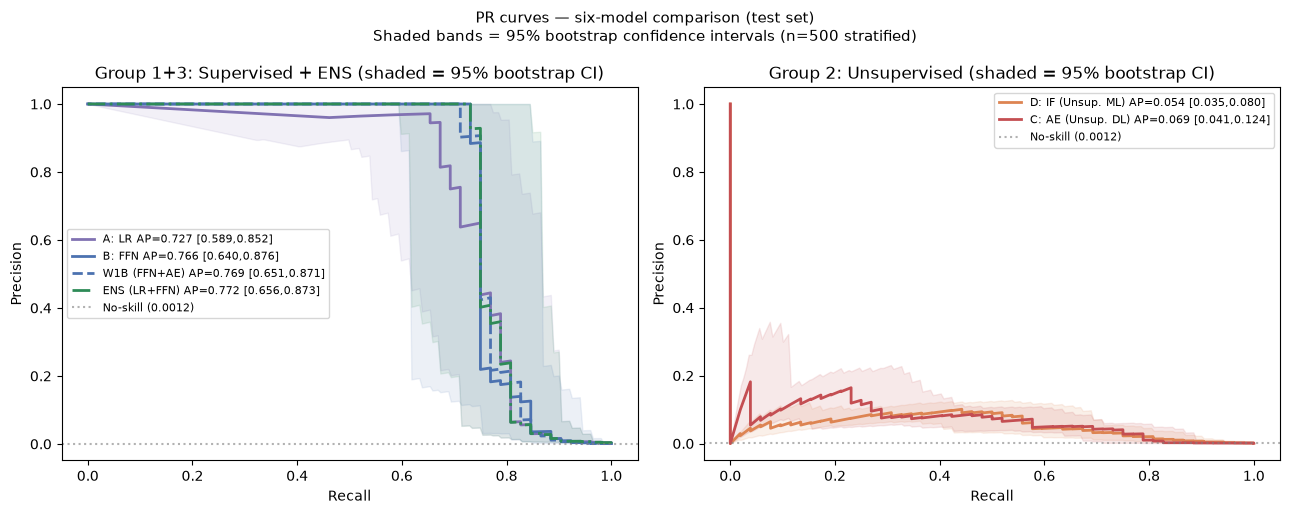

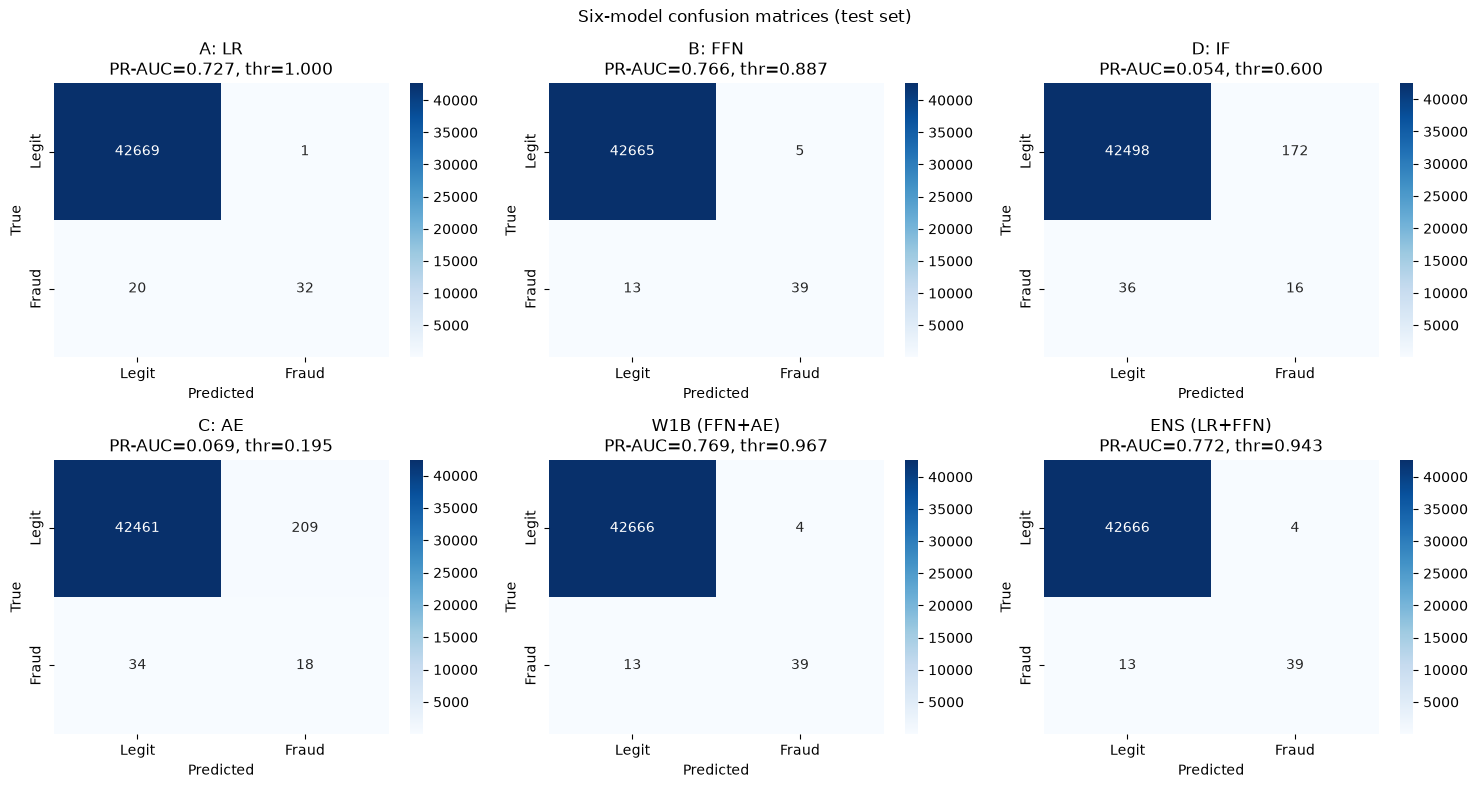

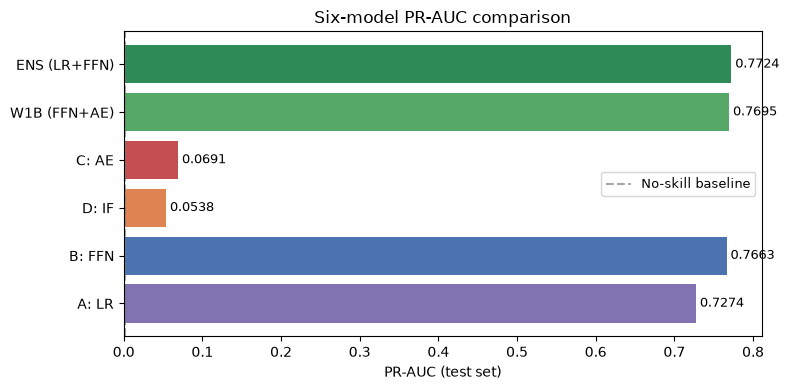

Six-model PR-AUC summary:
  A: LR                PR-AUC=0.7274  95%CI [0.5891, 0.8517]
  B: FFN               PR-AUC=0.7663  95%CI [0.6396, 0.8756]
  D: IF                PR-AUC=0.0538  95%CI [0.0355, 0.0805]
  C: AE                PR-AUC=0.0691  95%CI [0.0413, 0.1241]
  W1B (FFN+AE)         PR-AUC=0.7695  95%CI [0.6506, 0.8714]
  ENS (LR+FFN)         PR-AUC=0.7724  95%CI [0.6556, 0.8728]


In [34]:
# --- Six-model full comparison: PR curves + confusion matrices (post-ENS) ---
# ENS is computed in §9c (Cell 44) so this cell must run after that.
# This replaces the five-model plots in §9 with a complete six-model comparison.

# ── 1. PR curves: 3 panels (supervised+ENS | unsupervised | all PR-AUC bar) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel 1: Supervised + ENS + W1B
for name, scores, color, ls in [
    ("A: LR",         lr_test_scores,   "#8172B2", "-"),
    ("B: FFN",        ffn_test_scores,  "#4C72B0", "-"),
    ("W1B (FFN+AE)",  semi_test_scores, "#4C72B0", "--"),
    ("ENS (LR+FFN)",  ens_test_scores,  "#2E8B57", "-."),
]:
    p_c, r_c, _ = precision_recall_curve(y_te_np, scores)
    ap = average_precision_score(y_te_np, scores)
    lo_ci, hi_ci = bootstrap_ap_ci(y_te_np, scores, n_boot=500)
    axes[0].plot(r_c, p_c, color=color, linewidth=2, linestyle=ls,
                 label=f"{name} AP={ap:.3f} [{lo_ci:.3f},{hi_ci:.3f}]")
    if name in ("A: LR", "B: FFN", "ENS (LR+FFN)"):
        r_g, p_m, p_lo, p_hi = bootstrap_pr_band(y_te_np, scores, n_boot=500)
        axes[0].fill_between(r_g, p_lo, p_hi, alpha=0.10, color=color)

axes[0].axhline(y_te_np.mean(), ls=":", color="grey", alpha=0.6,
                label=f"No-skill ({y_te_np.mean():.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Group 1+3: Supervised + ENS (shaded = 95% bootstrap CI)")
axes[0].legend(fontsize=8)

# Panel 2: Unsupervised (unchanged)
for name, scores, color in [
    ("D: IF (Unsup. ML)", iso_test_scores, "#DD8452"),
    ("C: AE (Unsup. DL)", err_te,          "#C44E52"),
]:
    p_c, r_c, _ = precision_recall_curve(y_te_np, scores)
    ap = average_precision_score(y_te_np, scores)
    lo_ci, hi_ci = bootstrap_ap_ci(y_te_np, scores, n_boot=500)
    r_g, p_m, p_lo, p_hi = bootstrap_pr_band(y_te_np, scores, n_boot=500)
    axes[1].plot(r_c, p_c, color=color, linewidth=2,
                 label=f"{name} AP={ap:.3f} [{lo_ci:.3f},{hi_ci:.3f}]")
    axes[1].fill_between(r_g, p_lo, p_hi, alpha=0.12, color=color)

axes[1].axhline(y_te_np.mean(), ls=":", color="grey", alpha=0.6,
                label=f"No-skill ({y_te_np.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Group 2: Unsupervised (shaded = 95% bootstrap CI)")
axes[1].legend(fontsize=8)

plt.suptitle("PR curves — six-model comparison (test set)\n"
             "Shaded bands = 95% bootstrap confidence intervals (n=500 stratified)",
             fontsize=11)
plt.tight_layout(); plt.show()

# ── 2. Confusion matrices: 6 models (2 rows × 3 cols) ─────────────────────
# ENS threshold: max-F1 on val (same protocol as mitigations)
# ENS threshold: Precision >= 0.9 on val — same protocol as LR and FFN
p_e, r_e, t_e = precision_recall_curve(y_va_np, ens_val_scores)
mask_ens = p_e[:-1] >= 0.9
ens_cm_thr = float(t_e[mask_ens][0]) if mask_ens.any() else float(t_e[len(t_e)//2])

models_cm_full = [
    ("A: LR",         lr_test_scores,   lr_thr),
    ("B: FFN",        ffn_test_scores,  ffn_thr),
    ("D: IF",         iso_test_scores,  if_thr),
    ("C: AE",         err_te,           tau),
    ("W1B (FFN+AE)",  semi_test_scores, w1b_thr),
    ("ENS (LR+FFN)",  ens_test_scores,  ens_cm_thr),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

for ax, (name, scores, thr) in zip(axes_flat, models_cm_full):
    cm = confusion_matrix(y_te_np, (scores >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"])
    ap = average_precision_score(y_te_np, scores)
    ax.set_title(f"{name}\nPR-AUC={ap:.3f}, thr={thr:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Six-model confusion matrices (test set)", fontsize=12)
plt.tight_layout(); plt.show()

# ── 3. PR-AUC summary bar chart (all 6) ──────────────────────────────────
all_models = [
    ("A: LR",        lr_test_scores,   "#8172B2"),
    ("B: FFN",       ffn_test_scores,  "#4C72B0"),
    ("D: IF",        iso_test_scores,  "#DD8452"),
    ("C: AE",        err_te,           "#C44E52"),
    ("W1B (FFN+AE)", semi_test_scores, "#55A868"),
    ("ENS (LR+FFN)", ens_test_scores,  "#2E8B57"),
]

fig, ax = plt.subplots(figsize=(8, 4))
names_bar  = [m[0] for m in all_models]
apaucs_bar = [average_precision_score(y_te_np, m[1]) for m in all_models]
colors_bar = [m[2] for m in all_models]

ax.barh(names_bar, apaucs_bar, color=colors_bar)
ax.axvline(y_te_np.mean(), ls="--", color="grey", alpha=0.7, label="No-skill baseline")
ax.set_xlabel("PR-AUC (test set)")
ax.set_title("Six-model PR-AUC comparison")
ax.legend(fontsize=9)
for i, v in enumerate(apaucs_bar):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print("Six-model PR-AUC summary:")
for name, scores, _ in all_models:
    ap = average_precision_score(y_te_np, scores)
    lo, hi = bootstrap_ap_ci(y_te_np, scores, n_boot=500)
    print(f"  {name:<20} PR-AUC={ap:.4f}  95%CI [{lo:.4f}, {hi:.4f}]")


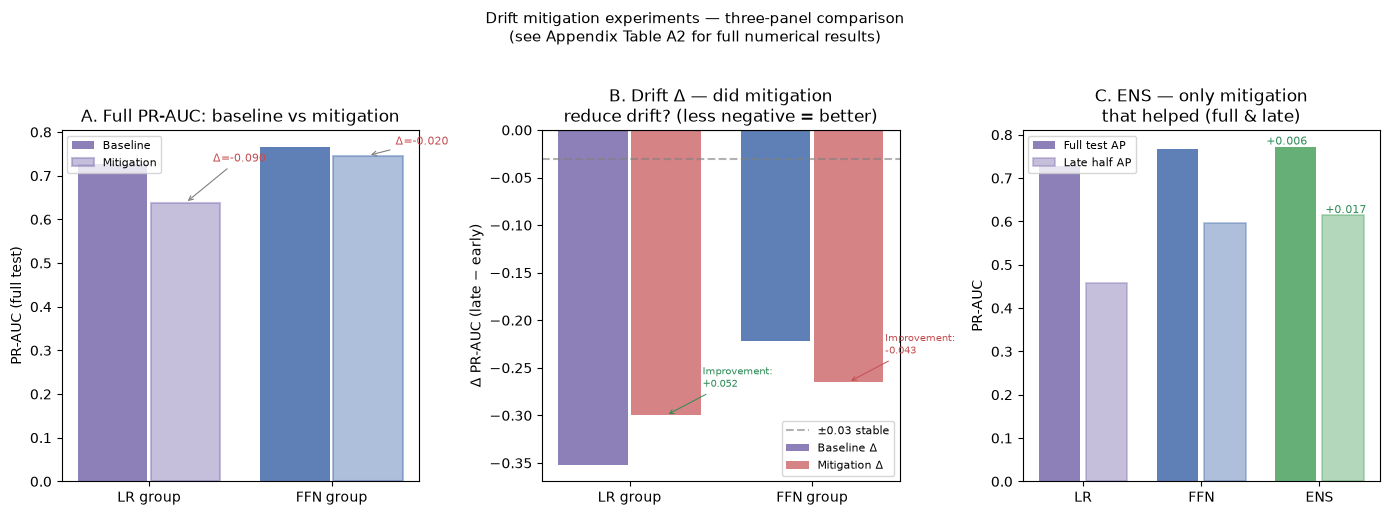

In [35]:
# --- Drift mitigation three-panel comparison (A, B, C) ---

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

pairs = [
    (mit_df[mit_df['model'] == 'LR (base)'].iloc[0],
     mit_df[mit_df['model'] == 'LR-SW'].iloc[0],
     'LR group'),
    (mit_df[mit_df['model'] == 'FFN (base)'].iloc[0],
     mit_df[mit_df['model'] == 'FFN-TW'].iloc[0],
     'FFN group'),
]

x = np.arange(2)
labels = ['LR group', 'FFN group']

# Panel A: Full PR-AUC
base_full = [pairs[0][0]['PR-AUC full'], pairs[1][0]['PR-AUC full']]
mit_full  = [pairs[0][1]['PR-AUC full'], pairs[1][1]['PR-AUC full']]
axes[0].bar(x - 0.2, base_full, 0.38, color=['#8172B2','#4C72B0'], alpha=0.9, label='Baseline')
axes[0].bar(x + 0.2, mit_full,  0.38, color=['#8172B2','#4C72B0'], alpha=0.45,
            label='Mitigation', edgecolor=['#8172B2','#4C72B0'], linewidth=1.5)
for i_p, (b, m) in enumerate(zip(base_full, mit_full)):
    diff = m - b
    axes[0].annotate(f'Δ={diff:+.3f}', xy=(i_p+0.2, m),
                     xytext=(i_p+0.35, max(b,m)+0.005), fontsize=8,
                     color='#C44E52' if diff < 0 else '#2E8B57',
                     arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('PR-AUC (full test)')
axes[0].set_title('A. Full PR-AUC: baseline vs mitigation')
axes[0].legend(fontsize=8)

# Panel B: Drift Delta
base_delta = [pairs[0][0]['Δ'], pairs[1][0]['Δ']]
mit_delta  = [pairs[0][1]['Δ'], pairs[1][1]['Δ']]
axes[1].bar(x - 0.2, base_delta, 0.38, color=['#8172B2','#4C72B0'], alpha=0.9, label='Baseline Δ')
axes[1].bar(x + 0.2, mit_delta,  0.38, color=['#C44E52','#C44E52'], alpha=0.7, label='Mitigation Δ')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axhline(-0.03, ls='--', color='grey', alpha=0.6, label='±0.03 stable')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Δ PR-AUC (late − early)')
axes[1].set_title('B. Drift Δ — did mitigation\nreduce drift? (less negative = better)')
axes[1].legend(fontsize=8)
for i_p, (bd, md) in enumerate(zip(base_delta, mit_delta)):
    improvement = md - bd
    col = '#2E8B57' if improvement > 0 else '#C44E52'
    axes[1].annotate(f'Improvement:\n{improvement:+.3f}',
                     xy=(i_p+0.2, md), xytext=(i_p+0.4, md+0.03),
                     fontsize=7.5, color=col,
                     arrowprops=dict(arrowstyle='->', color=col, lw=0.7))

# Panel C: ENS
ens_row  = mit_df[mit_df['model'] == 'ENS (LR+FFN)'].iloc[0]
lr_row   = mit_df[mit_df['model'] == 'LR (base)'].iloc[0]
ffn_row  = mit_df[mit_df['model'] == 'FFN (base)'].iloc[0]
models_C = ['LR', 'FFN', 'ENS']
full_C   = [lr_row['PR-AUC full'], ffn_row['PR-AUC full'], ens_row['PR-AUC full']]
late_C   = [lr_row['PR-AUC late'], ffn_row['PR-AUC late'], ens_row['PR-AUC late']]
colors_C = ['#8172B2', '#4C72B0', '#55A868']
x3 = np.arange(3)
axes[2].bar(x3 - 0.2, full_C, 0.35, color=colors_C, alpha=0.9, label='Full test AP')
axes[2].bar(x3 + 0.2, late_C, 0.35, color=colors_C, alpha=0.45,
            label='Late half AP', edgecolor=colors_C, linewidth=1.2)
axes[2].set_xticks(x3); axes[2].set_xticklabels(models_C)
axes[2].set_ylabel('PR-AUC')
axes[2].set_title('C. ENS — only mitigation\nthat helped (full & late)')
axes[2].legend(fontsize=8)
for j_p, (model, fc, lc) in enumerate(zip(models_C, full_C, late_C)):
    if model == 'ENS':
        best_full = max(full_C[:2])
        best_late = max(late_C[:2])
        axes[2].annotate(f'+{fc-best_full:.3f}', xy=(j_p-0.2, fc),
                         xytext=(j_p-0.45, fc+0.005), fontsize=8, color='#2E8B57')
        axes[2].annotate(f'+{lc-best_late:.3f}', xy=(j_p+0.2, lc),
                         xytext=(j_p+0.05, lc+0.005), fontsize=8, color='#2E8B57')

plt.suptitle('Drift mitigation experiments — three-panel comparison\n'
             '(see Appendix Table A2 for full numerical results)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

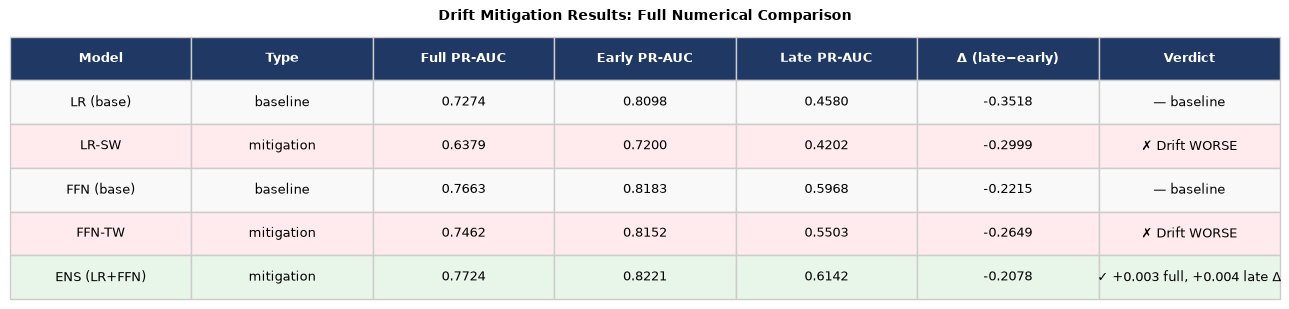

In [36]:
# --- Full drift mitigation comparison table ---

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis('off')

col_labels = ['Model', 'Type', 'Full PR-AUC', 'Early PR-AUC',
              'Late PR-AUC', 'Δ (late−early)', 'Verdict']

table_data = []
for _, r in mit_df.iterrows():
    if 'ENS' in r['model']:
        verdict = '✓ +0.003 full, +0.004 late Δ'
    elif r['type'] == 'mitigation':
        verdict = '✗ Drift WORSE'
    else:
        verdict = '— baseline'
    table_data.append([
        r['model'], r['type'],
        f"{r['PR-AUC full']:.4f}",
        f"{r['PR-AUC early']:.4f}",
        f"{r['PR-AUC late']:.4f}",
        f"{r['Δ']:+.4f}",
        verdict
    ])

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

row_colors = {2: '#FFEBEE', 4: '#FFEBEE', 5: '#E8F5E9'}
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif row in row_colors:
        cell.set_facecolor(row_colors[row])
    else:
        cell.set_facecolor('#F9F9F9')
    cell.set_edgecolor('#CCCCCC')

ax.set_title('Drift Mitigation Results: Full Numerical Comparison',
             pad=12, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# §9b  EXTENDED — Time-stratified PR-AUC for ALL SIX models
# (W1B and ENS added to the original four-model evaluation)
#
# Prerequisites (must run in order after original §9b cell):
#   - e_mask, l_mask already defined in Cell 40
#   - semi_test_scores (W1B) defined in Cell ~33
#   - ens_test_scores (ENS) defined in Cell 44
#   - strat_df already contains LR / FFN / IF / AE rows
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np

# ── Append W1B and ENS to strat_df ───────────────────────────────────────────
extra_models = [
    ("W1B",        semi_test_scores, "Enhancement"),
    ("ENS (LR+FFN)", ens_test_scores,  "Enhancement"),
]

extra_rows = []
for name, scores, group in extra_models:
    ap_e = average_precision_score(y_te_np[e_mask], scores[e_mask])
    ap_l = average_precision_score(y_te_np[l_mask], scores[l_mask])
    ap_f = average_precision_score(y_te_np, scores)

    base_e = y_te_np[e_mask].mean()
    base_l = y_te_np[l_mask].mean()
    norm_e = ap_e / base_e if base_e > 0 else np.nan
    norm_l = ap_l / base_l if base_l > 0 else np.nan

    lo_l, hi_l = bootstrap_ap_ci(y_te_np[l_mask], scores[l_mask], n_boot=500)
    delta = ap_l - ap_e

    extra_rows.append({
        "model": name, "group": group,
        "AP early": ap_e, "AP late": ap_l, "AP full": ap_f,
        "Norm AP early": norm_e, "Norm AP late": norm_l,
        "CI late lo": lo_l, "CI late hi": hi_l, "Δ": delta
    })

    print(f"{name} ({group})")
    print(f"  Raw:  early={ap_e:.4f}  late={ap_l:.4f}  "
          f"[{lo_l:.4f}, {hi_l:.4f}]  Δ={delta:+.4f}")
    print(f"  Norm: early={norm_e:.2f}×  late={norm_l:.2f}×\n")

# Extend strat_df with the two new rows
strat_df_full = pd.concat(
    [strat_df, pd.DataFrame(extra_rows)],
    ignore_index=True
)

print("=" * 65)
print("Full six-model time-stratified summary:")
print("=" * 65)
cols_show = ["model", "group", "AP early", "AP late", "Δ"]
print(strat_df_full[cols_show].to_string(index=False, float_format="{:.4f}".format))


W1B (Enhancement)
  Raw:  early=0.8256  late=0.6006  [0.3697, 0.8496]  Δ=-0.2250
  Norm: early=452.22×  late=986.90×

ENS (LR+FFN) (Enhancement)
  Raw:  early=0.8221  late=0.6142  [0.3713, 0.8476]  Δ=-0.2078
  Norm: early=450.26×  late=1009.30×

Full six-model time-stratified summary:
       model           group  AP early  AP late       Δ
       A: LR   Supervised ML    0.8098   0.4580 -0.3518
      B: FFN   Supervised DL    0.8183   0.5968 -0.2215
       D: IF Unsupervised ML    0.1040   0.0149 -0.0891
       C: AE Unsupervised DL    0.1204   0.0233 -0.0971
         W1B     Enhancement    0.8256   0.6006 -0.2250
ENS (LR+FFN)     Enhancement    0.8221   0.6142 -0.2078


---
### 9d. Calibration analysis — are the model scores reliable probabilities?

A model is **well-calibrated** if, among all transactions scored at p=0.7,
roughly 70% are genuinely fraudulent. Poor calibration means the threshold
chosen on the validation set may not generalise — a model that outputs
overconfident scores will require frequent threshold recalibration in production.

We evaluate calibration for the two supervised models that output values in
[0,1]: **LR** (direct sigmoid probability) and **FFN** (sigmoid of logit,
distorted by pos_weight=50). The unsupervised models (AE, IF) output
anomaly scores on arbitrary scales and cannot be calibrated meaningfully
without isotonic regression — noted as a production limitation.

**Metrics:**
- **Reliability diagram** — visual check; perfect calibration = diagonal line
- **Brier Score** — mean squared error between predicted p and true label
  (lower is better; 0 = perfect)
- **Expected Calibration Error (ECE)** — weighted mean absolute deviation
  from perfect calibration across 10 bins (lower is better)


Calibration metrics (test set, quantile bins)

A: LR:
  Brier Score : 0.01542
  ECE         : 0.05147
  HL test     : χ²=2838.76  df=8  p=0.0000  (MISCALIBRATED)
  Score range : [0.0000, 1.0000]
  Median      : 0.01338
  Score > 0.5 : 764 (1.788%)

B: FFN:
  Brier Score : 0.00045
  ECE         : 0.00024
  HL test     : χ²=93701.06  df=8  p=0.0000  (MISCALIBRATED)
  Score range : [0.0000, 1.0000]
  Median      : 0.00000
  Score > 0.5 : 46 (0.108%)


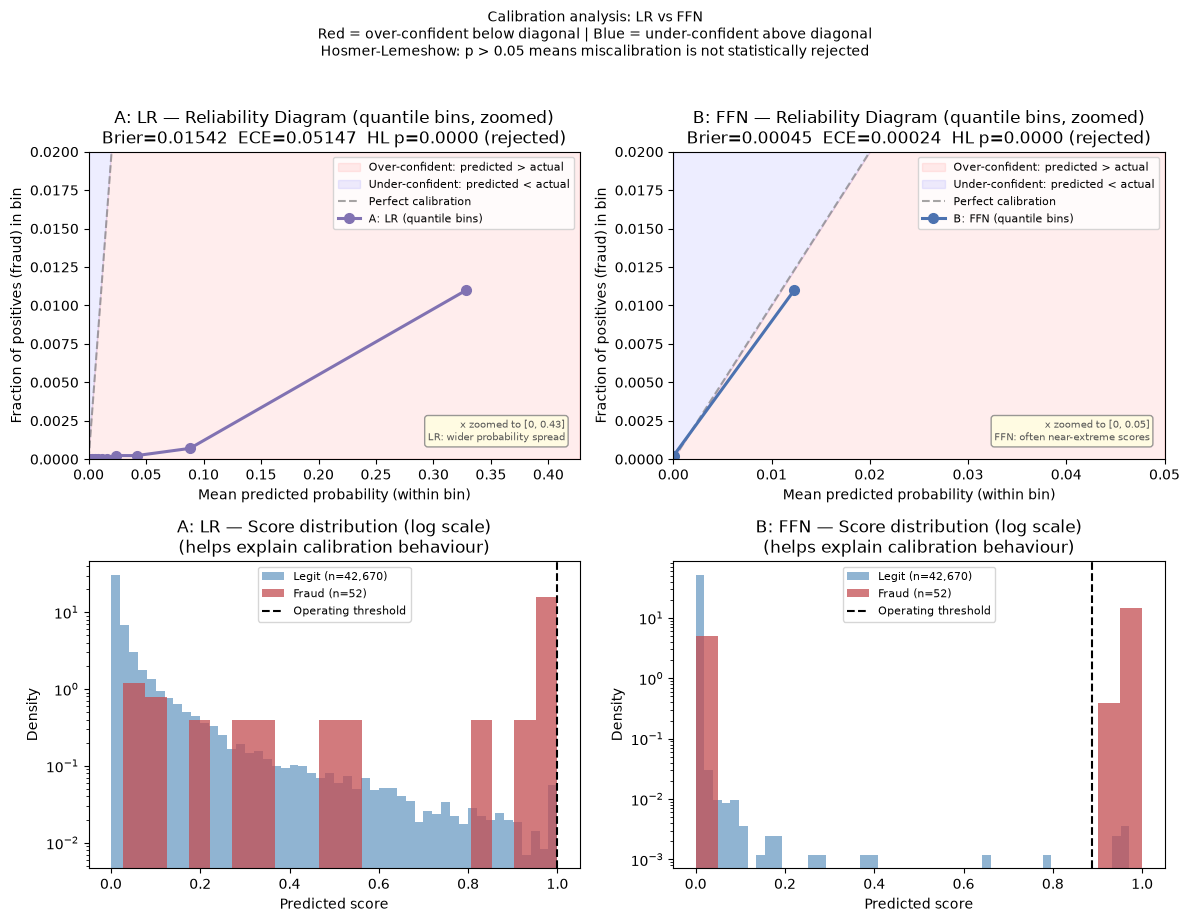


Interpretation:
  LR: Hosmer-Lemeshow p=0.0000 → statistically miscalibrated.
  FFN: Hosmer-Lemeshow p=0.0000 → statistically miscalibrated.
  Because the dataset is highly imbalanced, HL should not be used alone.
  The reliability diagram, Brier score, ECE, and score distribution should be interpreted together.
  If calibrated probabilities are required for deployment, Platt scaling or isotonic calibration should be tested on a validation set.

Stored: hl_p_lr=0.0000  hl_p_ffn=0.0000


In [38]:
from sklearn.calibration import calibration_curve
from scipy.stats import chi2 as chi2_dist

def expected_calibration_error(y_true, y_prob, n_bins=10, strategy="quantile"):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if strategy == "quantile":
        bin_edges = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
        bin_edges = np.unique(bin_edges)
    else:
        bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    counted = 0

    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if i == len(bin_edges) - 2:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() * abs(acc - conf)
        counted += mask.sum()

    return float(ece / max(counted, 1))


def brier_score(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    return float(np.mean((y_prob - y_true) ** 2))


def hosmer_lemeshow(y_true, y_prob, n_bins=10):
    """
    Hosmer-Lemeshow goodness-of-fit test for binary calibration.
    H0: model is well-calibrated.
    p > 0.05 means H0 is not rejected.
    Uses percentile-based equal-frequency binning.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)

    hl_stat, groups = 0.0, 0

    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if i == len(bin_edges) - 2:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() < 2:
            continue

        n_k = mask.sum()
        obs_k = y_true[mask].sum()
        exp_k = y_prob[mask].sum()

        denom = exp_k * (1 - exp_k / n_k) + 1e-12
        hl_stat += (obs_k - exp_k) ** 2 / denom
        groups += 1

    df = max(groups - 2, 1)
    p_val = float(1 - chi2_dist.cdf(hl_stat, df=df))
    return float(hl_stat), int(df), p_val


calib_models = [
    ("A: LR", lr_test_scores),
    ("B: FFN", ffn_test_scores)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

print("=" * 65)
print("Calibration metrics (test set, quantile bins)")
print("=" * 65)

_calib_stats = {}

for col, (name, scores) in enumerate(calib_models):
    scores = np.asarray(scores)

    ax_top = axes[0, col]

    frac_pos, mean_pred = calibration_curve(
        y_te_np, scores, n_bins=10, strategy="quantile"
    )

    bs_q = brier_score(y_te_np, scores)
    ece_q = expected_calibration_error(
        y_te_np, scores, n_bins=10, strategy="quantile"
    )
    hl, df_hl, p_hl = hosmer_lemeshow(y_te_np, scores, n_bins=10)

    _calib_stats[name] = {
        "brier": bs_q,
        "ece": ece_q,
        "hl": hl,
        "hl_df": df_hl,
        "hl_p": p_hl,
        "score_min": float(scores.min()),
        "score_max": float(scores.max()),
        "score_median": float(np.median(scores)),
        "score_gt_05_n": int((scores > 0.5).sum()),
        "score_gt_05_pct": float((scores > 0.5).mean())
    }

    x_max = min(max(mean_pred.max() * 1.3, 0.05), 1.0)
    y_max = min(max(frac_pos.max() * 1.6, 0.02), 1.0)

    ax_top.fill_between(
        [0, x_max], [0, 0], [0, x_max],
        alpha=0.07, color="red",
        label="Over-confident: predicted > actual"
    )
    ax_top.fill_between(
        [0, x_max], [0, x_max], [y_max, y_max],
        alpha=0.07, color="blue",
        label="Under-confident: predicted < actual"
    )

    ax_top.plot(
        [0, x_max], [0, x_max],
        ls="--", color="grey", alpha=0.7,
        linewidth=1.5, label="Perfect calibration"
    )

    ax_top.plot(
        mean_pred, frac_pos, "-o",
        color="#4C72B0" if col else "#8172B2",
        linewidth=2.2, markersize=7,
        label=f"{name} (quantile bins)"
    )

    ax_top.set_xlim(0, x_max)
    ax_top.set_ylim(0, y_max)
    ax_top.set_xlabel("Mean predicted probability (within bin)")
    ax_top.set_ylabel("Fraction of positives (fraud) in bin")

    hl_status = "not rejected" if p_hl > 0.05 else "rejected"
    ax_top.set_title(
        f"{name} — Reliability Diagram (quantile bins, zoomed)\n"
        f"Brier={bs_q:.5f}  ECE={ece_q:.5f}  "
        f"HL p={p_hl:.4f} ({hl_status})"
    )
    ax_top.legend(fontsize=8)

    note = "LR: wider probability spread" if col == 0 else "FFN: often near-extreme scores"
    ax_top.text(
        0.97, 0.05,
        f"x zoomed to [0, {x_max:.2f}]\n{note}",
        transform=ax_top.transAxes,
        ha="right", va="bottom",
        fontsize=7.5, color="#555555",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="lightyellow",
            edgecolor="grey",
            alpha=0.8
        )
    )

    print(f"\n{name}:")
    print(f"  Brier Score : {bs_q:.5f}")
    print(f"  ECE         : {ece_q:.5f}")
    print(
        f"  HL test     : χ²={hl:.2f}  df={df_hl}  p={p_hl:.4f}  "
        f"({'not rejected as miscalibrated' if p_hl > 0.05 else 'MISCALIBRATED'})"
    )
    print(f"  Score range : [{scores.min():.4f}, {scores.max():.4f}]")
    print(f"  Median      : {np.median(scores):.5f}")
    print(f"  Score > 0.5 : {(scores > 0.5).sum()} ({(scores > 0.5).mean():.3%})")

    ax_bot = axes[1, col]

    ax_bot.hist(
        scores[y_te_np == 0],
        bins=50, alpha=0.6, density=True,
        color="steelblue",
        label="Legit (n={:,})".format(int((y_te_np == 0).sum()))
    )
    ax_bot.hist(
        scores[y_te_np == 1],
        bins=20, alpha=0.75, density=True,
        color="#C44E52",
        label="Fraud (n={})".format(int(y_te_np.sum()))
    )

    threshold = lr_thr if col == 0 else ffn_thr
    ax_bot.axvline(
        threshold, color="black", ls="--",
        linewidth=1.5, label="Operating threshold"
    )

    ax_bot.set_xlabel("Predicted score")
    ax_bot.set_ylabel("Density")
    ax_bot.set_title(
        f"{name} — Score distribution (log scale)\n"
        f"(helps explain calibration behaviour)"
    )
    ax_bot.legend(fontsize=8)
    ax_bot.set_yscale("log")

plt.suptitle(
    "Calibration analysis: LR vs FFN\n"
    "Red = over-confident below diagonal | Blue = under-confident above diagonal\n"
    "Hosmer-Lemeshow: p > 0.05 means miscalibration is not statistically rejected",
    fontsize=10,
    y=1.02
)

plt.tight_layout()
plt.show()

hl_p_lr = _calib_stats["A: LR"]["hl_p"]
hl_p_ffn = _calib_stats["B: FFN"]["hl_p"]

print()
print("Interpretation:")

lr_status = (
    "statistically miscalibrated"
    if hl_p_lr < 0.05
    else "not statistically rejected as miscalibrated"
)

ffn_status = (
    "statistically miscalibrated"
    if hl_p_ffn < 0.05
    else "not statistically rejected as miscalibrated"
)

print(f"  LR: Hosmer-Lemeshow p={hl_p_lr:.4f} → {lr_status}.")
print(f"  FFN: Hosmer-Lemeshow p={hl_p_ffn:.4f} → {ffn_status}.")
print("  Because the dataset is highly imbalanced, HL should not be used alone.")
print("  The reliability diagram, Brier score, ECE, and score distribution should be interpreted together.")
print("  If calibrated probabilities are required for deployment, Platt scaling or isotonic calibration should be tested on a validation set.")

print()
print(f"Stored: hl_p_lr={hl_p_lr:.4f}  hl_p_ffn={hl_p_ffn:.4f}")

---
### 9e. Error analysis — FP/FN breakdown and cross-model overlap

Understanding *which* transactions each model gets wrong is more actionable
than headline PR-AUC. This section asks three questions:

1. **Missed fraud (FN):** Do the frauds that one model misses look different
   from the frauds it catches? Are they concentrated in specific feature ranges?
2. **False alarms (FP):** Do the legitimate transactions flagged as fraud
   share any unusual features? (Actionable for reducing customer friction.)
3. **Cross-model overlap:** How many frauds does NO model catch (hard cases)?
   How many does ONLY ONE model catch (unique captures — ensemble value)?

Analysis covers LR, FFN, AE, IF. W1B is omitted (its errors are
structurally nearly identical to FFN).


FN / FP counts per model (test set)
LR: TP=32  FP=1  FN=20  (missed 20/52 = 38.5% of fraud)
FFN: TP=39  FP=5  FN=13  (missed 13/52 = 25.0% of fraud)
AE: TP=18  FP=209  FN=34  (missed 34/52 = 65.4% of fraud)
IF: TP=16  FP=172  FN=36  (missed 36/52 = 69.2% of fraud)

Cross-model FN overlap (out of 52 fraud):
  Hard cases (ALL miss): 12  (23.1%)
  FFN unique catches   : 5
  AE unique catches    : 1
  LR unique catches    : 0
  IF unique catches    : 0

Mann-Whitney U test: FN vs TP feature distributions
(H0: FN and TP come from the same feature distribution)
rank-biserial r: |r| > 0.5 = large effect, > 0.3 = medium

LR (FN n=20, TP n=32):
  V14     : U=620  p=0.0000***  r=-0.938 (large)
  V10     : U=613  p=0.0000***  r=-0.916 (large)
  V12     : U=628  p=0.0000***  r=-0.962 (large)
  Amount  : U=392  p=0.1776ns  r=-0.225 (small)

FFN (FN n=13, TP n=39):
  V14     : U=500  p=0.0000***  r=-0.972 (large)
  V10     : U=507  p=0.0000***  r=-1.000 (large)
  V12     : U=507  p=0.0000***  r=-1.0

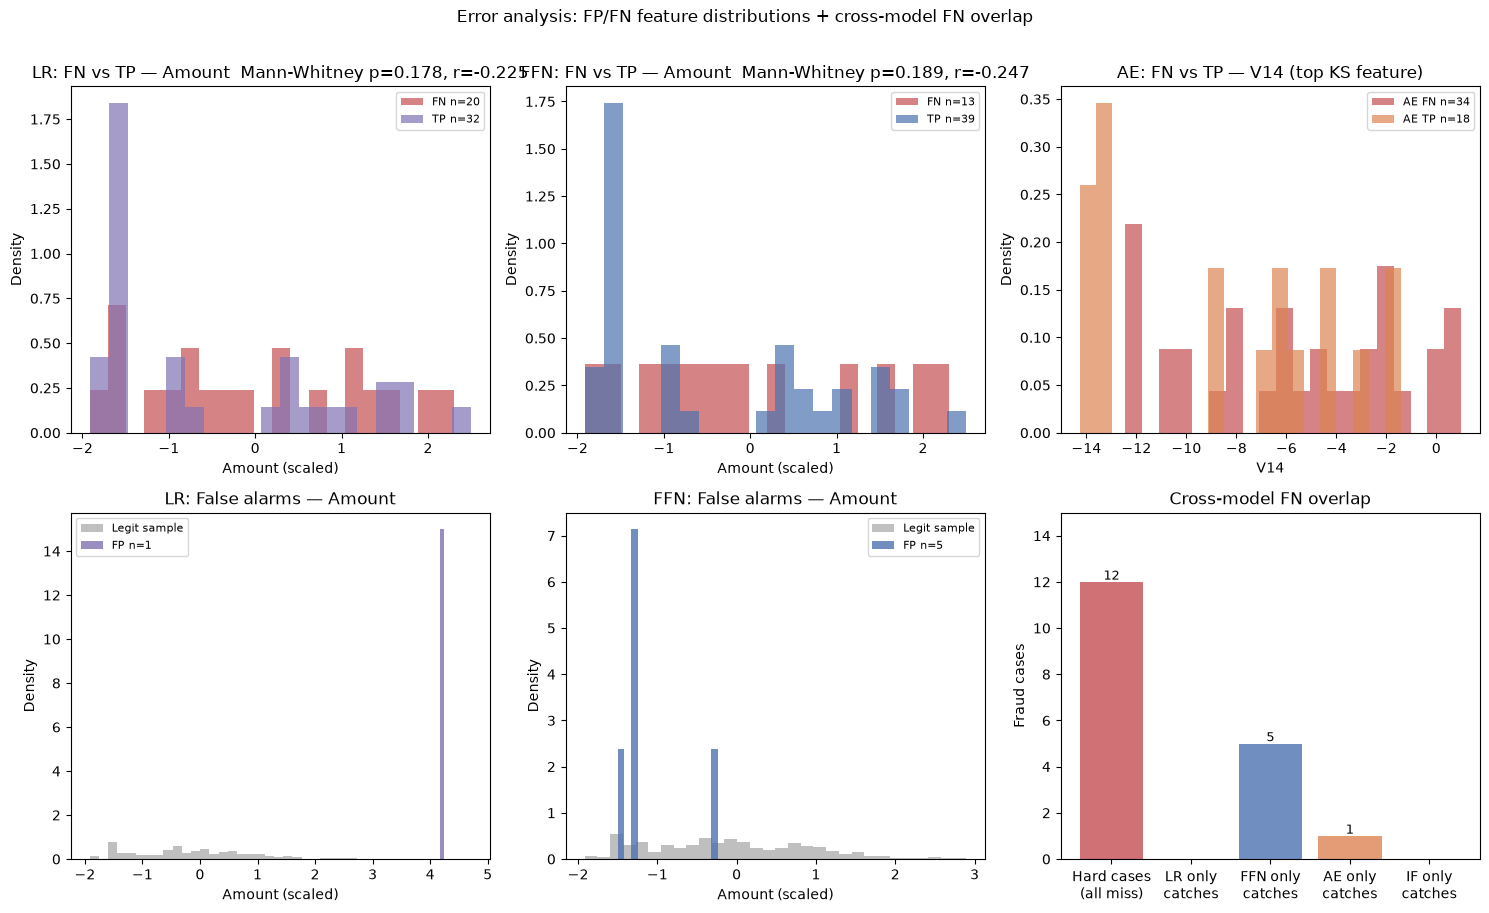

In [39]:
# --- §9e Error analysis: FP/FN + Mann-Whitney U + cross-model overlap ---
from scipy.stats import mannwhitneyu

fraud_idx_te = np.where(y_te_np == 1)[0]
legit_idx_te = np.where(y_te_np == 0)[0]

def classify(scores, thr):
    pred = (scores >= thr).astype(int)
    tp = set(np.where((pred==1) & (y_te_np==1))[0])
    fp = set(np.where((pred==1) & (y_te_np==0))[0])
    fn = set(np.where((pred==0) & (y_te_np==1))[0])
    tn = set(np.where((pred==0) & (y_te_np==1))[0])
    return tp, fp, fn

tp_lr,  fp_lr,  fn_lr  = classify(lr_test_scores,  lr_thr)
tp_ffn, fp_ffn, fn_ffn = classify(ffn_test_scores, ffn_thr)
tp_ae,  fp_ae,  fn_ae  = classify(err_te,           tau)
tp_if,  fp_if,  fn_if  = classify(iso_test_scores,  if_thr)

n_fraud = len(fraud_idx_te)
print("=" * 60)
print("FN / FP counts per model (test set)")
print("=" * 60)
for nm, fn, fp, tp in [("LR",fn_lr,fp_lr,tp_lr),("FFN",fn_ffn,fp_ffn,tp_ffn),
                        ("AE",fn_ae,fp_ae,tp_ae),("IF",fn_if,fp_if,tp_if)]:
    print(f"{nm}: TP={len(tp)}  FP={len(fp)}  FN={len(fn)}  "
          f"(missed {len(fn)}/{n_fraud} = {len(fn)/n_fraud:.1%} of fraud)")

# Cross-model FN overlap
hard_cases = fn_lr & fn_ffn & fn_ae & fn_if
only_ffn   = (fn_lr  & fn_ae  & fn_if ) - fn_ffn
only_ae    = (fn_lr  & fn_ffn & fn_if ) - fn_ae
only_lr    = (fn_ffn & fn_ae  & fn_if ) - fn_lr
only_if    = (fn_lr  & fn_ffn & fn_ae ) - fn_if
print(f"\nCross-model FN overlap (out of {n_fraud} fraud):")
print(f"  Hard cases (ALL miss): {len(hard_cases)}  ({len(hard_cases)/n_fraud:.1%})")
print(f"  FFN unique catches   : {len(only_ffn)}")
print(f"  AE unique catches    : {len(only_ae)}")
print(f"  LR unique catches    : {len(only_lr)}")
print(f"  IF unique catches    : {len(only_if)}")

# Mann-Whitney U: do FN differ from TP in top-KS features?
print()
print("=" * 60)
print("Mann-Whitney U test: FN vs TP feature distributions")
print("(H0: FN and TP come from the same feature distribution)")
print("rank-biserial r: |r| > 0.5 = large effect, > 0.3 = medium")
print("=" * 60)
for model_name, fn_set, tp_set in [
    ("LR",  fn_lr,  tp_lr),
    ("FFN", fn_ffn, tp_ffn),
]:
    fn_idx = list(fn_set); tp_idx = list(tp_set)
    if len(fn_idx) == 0 or len(tp_idx) == 0: continue
    print(f"\n{model_name} (FN n={len(fn_idx)}, TP n={len(tp_idx)}):")
    for feat in list(KS_RANK.index[:3]) + ["Amount"]:
        if feat not in FEATURES: continue
        fi = FEATURES.index(feat)
        stat, p = mannwhitneyu(X_te_np[fn_idx, fi],
                               X_te_np[tp_idx, fi],
                               alternative="two-sided")
        n1, n2 = len(fn_idx), len(tp_idx)
        r = 1 - (2 * stat) / (n1 * n2)   # rank-biserial correlation
        size = "large" if abs(r) > 0.5 else "medium" if abs(r) > 0.3 else "small"
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        print(f"  {feat:<8}: U={stat:.0f}  p={p:.4f}{sig}  r={r:+.3f} ({size})")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
v_top2 = list(KS_RANK.index[:2])

# Row 0: FN vs TP distributions (supervised models)
for ax, (nm, fn_set, tp_set, color) in zip(
    [axes[0,0], axes[0,1]],
    [("LR",  fn_lr,  tp_lr,  "#8172B2"),
     ("FFN", fn_ffn, tp_ffn, "#4C72B0")]
):
    fn_idx = list(fn_set); tp_idx = list(tp_set)
    feat_i = FEATURES.index("Amount")
    if fn_idx:
        ax.hist(X_te_np[fn_idx, feat_i], bins=20, alpha=0.7,
                density=True, color="#C44E52", label=f"FN n={len(fn_idx)}")
    if tp_idx:
        ax.hist(X_te_np[tp_idx, feat_i], bins=20, alpha=0.7,
                density=True, color=color, label=f"TP n={len(tp_idx)}")
    stat_str = ""
    if fn_idx and tp_idx:
        s, p = mannwhitneyu(X_te_np[fn_idx, feat_i],
                            X_te_np[tp_idx, feat_i], alternative="two-sided")
        r = 1 - (2*s)/(len(fn_idx)*len(tp_idx))
        stat_str = f"  Mann-Whitney p={p:.3f}, r={r:+.3f}"
    ax.set_title(f"{nm}: FN vs TP — Amount{stat_str}")
    ax.set_xlabel("Amount (scaled)"); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# Row 0 col 2: AE FN vs TP — top KS feature
ax = axes[0, 2]
feat_name = v_top2[0]; feat_i = FEATURES.index(feat_name)
fn_idx = list(fn_ae); tp_idx = list(tp_ae)
if fn_idx:
    ax.hist(X_te_np[fn_idx, feat_i], bins=20, alpha=0.7,
            density=True, color="#C44E52", label=f"AE FN n={len(fn_idx)}")
if tp_idx:
    ax.hist(X_te_np[tp_idx, feat_i], bins=20, alpha=0.7,
            density=True, color="#DD8452", label=f"AE TP n={len(tp_idx)}")
ax.set_title(f"AE: FN vs TP — {feat_name} (top KS feature)")
ax.set_xlabel(feat_name); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# Row 1: FP distributions + overlap
for ax, (nm, fp_set, color) in zip(
    [axes[1,0], axes[1,1]],
    [("LR",  fp_lr,  "#8172B2"), ("FFN", fp_ffn, "#4C72B0")]
):
    feat_i = FEATURES.index("Amount")
    sample_legit = np.random.choice(legit_idx_te, min(500, len(legit_idx_te)),
                                    replace=False)
    ax.hist(X_te_np[sample_legit, feat_i], bins=30, alpha=0.5,
            density=True, color="grey", label="Legit sample")
    fp_idx = list(fp_set)
    if fp_idx:
        ax.hist(X_te_np[fp_idx, feat_i], bins=15, alpha=0.8,
                density=True, color=color, label=f"FP n={len(fp_idx)}")
    ax.set_title(f"{nm}: False alarms — Amount")
    ax.set_xlabel("Amount (scaled)"); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# Row 1 col 2: cross-model overlap
ax = axes[1, 2]
labels = ["Hard cases\n(all miss)","LR only\ncatches","FFN only\ncatches",
          "AE only\ncatches","IF only\ncatches"]
vals   = [len(hard_cases),len(only_lr),len(only_ffn),len(only_ae),len(only_if)]
cols   = ["#C44E52","#8172B2","#4C72B0","#DD8452","#C44E52"]
ax.bar(labels, vals, color=cols, alpha=0.8)
ax.set_ylabel("Fraud cases"); ax.set_title("Cross-model FN overlap")
for i, v in enumerate(vals):
    if v > 0: ax.text(i, v+0.1, str(v), ha="center", fontsize=9)
ax.set_ylim(0, max(vals)*1.25)

plt.suptitle("Error analysis: FP/FN feature distributions + cross-model FN overlap",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


---
## 10. Interpretability — SHAP + cross-model agreement

V1..V28 are PCA components with no business meaning, so feature
attributions cannot tell us *which real behaviours* drive a prediction.
What they **can** show is:

- whether the FFN relies on the same features that §4.4's KS statistic
  already flagged (a data-only sanity check),
- whether the three models rely on the *same* features (a high agreement
  → the AE is largely redundant given the FFN; a low agreement → they are
  candidates for ensembling).

We compute four importance rankings:

| Ranking | Type | Source |
|---|---|---|
| `KS` | data-only | §4.4 — the KS statistic per feature |
| `LR \|coef\|` | linear supervised | absolute value of LR coefficients |
| `FFN SHAP` | non-linear supervised | mean \|SHAP value\| over a test sample, computed with `shap.GradientExplainer` |
| `AE Δerr` | unsupervised | per-feature reconstruction MSE on fraud minus legit |

…and then take Spearman rank correlations between all four rankings.


In [40]:
# --- FFN SHAP via GradientExplainer ---
# Wrap the FFN so it returns (batch, 1) probabilities — SHAP's preferred format.
class FFNProbWrap(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x):
        logit = self.m(x)
        if logit.dim() == 1:
            logit = logit.unsqueeze(-1)
        return torch.sigmoid(logit)

ffn_wrap = FFNProbWrap(ffn_model).to(DEVICE).eval()

# Small background (used by SHAP to integrate expected gradients)
rng = np.random.RandomState(0)
bg_idx = rng.choice(len(X_tr), 100, replace=False)
background = X_tr[bg_idx].to(DEVICE)

# Evaluation sample: 50 frauds + 150 legit for diversity (if we have 50 frauds)
frauds_te = np.where(y_te_np == 1)[0]
legit_te  = np.where(y_te_np == 0)[0]
n_fraud_sample = min(50, len(frauds_te))
fraud_idx = rng.choice(frauds_te, n_fraud_sample, replace=False)
legit_idx = rng.choice(legit_te,  200 - n_fraud_sample, replace=False)
shap_idx  = np.concatenate([fraud_idx, legit_idx])
x_shap    = X_te[shap_idx].to(DEVICE)

try:
    import shap
    t0 = time.time()
    explainer   = shap.GradientExplainer(ffn_wrap, background)
    shap_values = explainer.shap_values(x_shap)
    # Some SHAP versions return list-of-array (one per class); unify to (n, d)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
        shap_values = shap_values[..., 0]
    ffn_importance = np.abs(shap_values).mean(axis=0)
    ffn_imp_label  = "FFN |SHAP|"
    print(f"SHAP computed on {x_shap.shape[0]} samples in {time.time()-t0:.1f}s")
except Exception as e:
    # Fallback: mean |gradient| (SHAP install or version issue)
    print(f"SHAP unavailable ({e}); falling back to gradient-based importance")
    x_top = x_shap.clone().detach().requires_grad_(True)
    ffn_wrap(x_top).sum().backward()
    ffn_importance = x_top.grad.abs().mean(dim=0).detach().cpu().numpy()
    ffn_imp_label  = "FFN |grad|"

print(f"Using importance signal: {ffn_imp_label}")


SHAP computed on 200 samples in 1.1s
Using importance signal: FFN |SHAP|


W1B SHAP computed on 200 samples in 1.0s

AE reconstruction error feature rank: 31 / 31
AE reconstruction error mean |SHAP|: 0.000035
Top feature mean |SHAP|: 0.085538  (V14)
AE importance as % of top feature: 0.04%


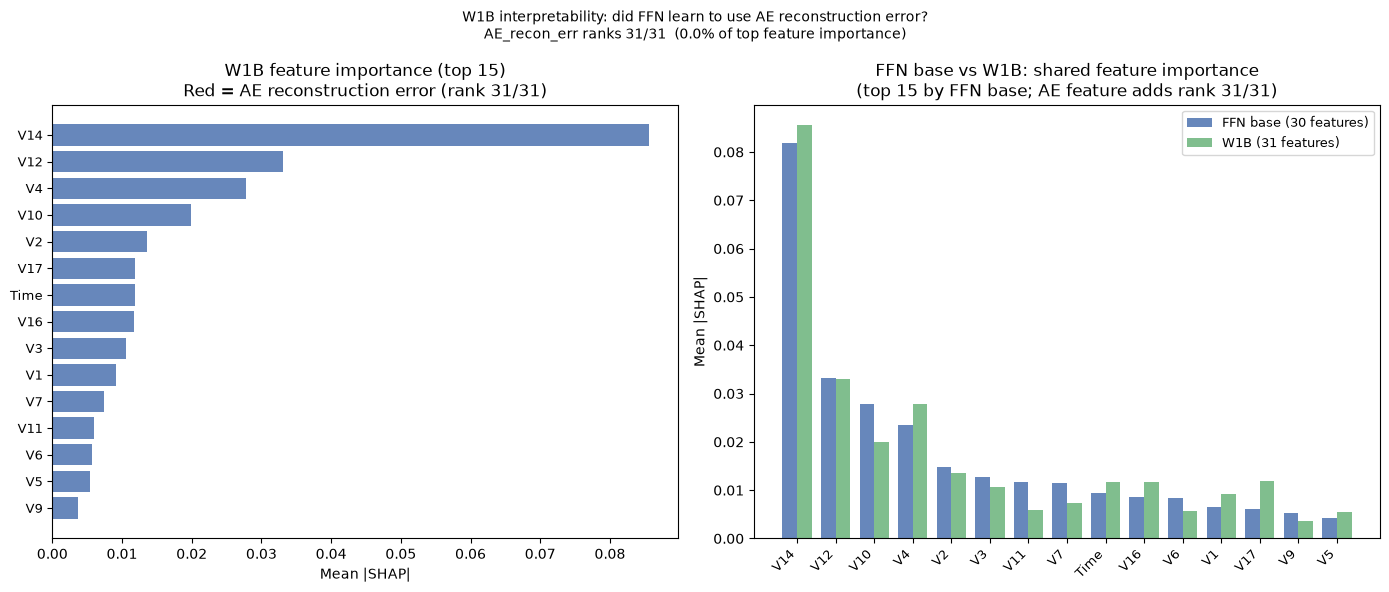


Spearman ρ (FFN base vs W1B, shared 30 features): ρ=+0.9297  p=0.0000
Interpretation:
  AE_recon_err rank: 31/31
  → AE feature is in the bottom quartile of importance.
  → FFN effectively ignores reconstruction error as a signal.
  → Confirms W1B near-zero gain is a genuine null result, not a tuning issue.


In [41]:
# --- W1B interpretability: does FFN actually use the 31st AE feature? ---
# This cell runs GradientExplainer on ffn_semi (31-feature W1B model).
# The key question: does the AE reconstruction error feature rank high in
# SHAP importance, or does the FFN learn to ignore it?
# If AE_err ranks last → confirms W1B's near-zero PR-AUC gain is because
# the FFN found no discriminative signal in reconstruction error.

FEATURES_W1B = FEATURES + ["AE_recon_err"]  # 31 features

ffn_semi_wrap = FFNProbWrap(ffn_semi).to(DEVICE).eval()

# Background: same 100-sample background as base FFN but with 31 features
rng_w1b = np.random.RandomState(0)
bg_idx_w1b  = rng_w1b.choice(len(X_tr_semi), 100, replace=False)
background_w1b = X_tr_semi[bg_idx_w1b].to(DEVICE)

# Evaluation sample: same fraud/legit indices as base SHAP for comparability
x_shap_w1b = X_te_semi[shap_idx].to(DEVICE)

try:
    import shap
    t0 = time.time()
    explainer_w1b   = shap.GradientExplainer(ffn_semi_wrap, background_w1b)
    shap_values_w1b = explainer_w1b.shap_values(x_shap_w1b)
    if isinstance(shap_values_w1b, list):
        shap_values_w1b = shap_values_w1b[0]
    shap_values_w1b = np.asarray(shap_values_w1b)
    if shap_values_w1b.ndim == 3 and shap_values_w1b.shape[-1] == 1:
        shap_values_w1b = shap_values_w1b[..., 0]
    w1b_importance = np.abs(shap_values_w1b).mean(axis=0)
    print(f"W1B SHAP computed on {x_shap_w1b.shape[0]} samples in {time.time()-t0:.1f}s")
    shap_ok = True
except Exception as e:
    print(f"SHAP failed ({e}); using gradient fallback")
    x_w = x_shap_w1b.clone().detach().requires_grad_(True)
    ffn_semi_wrap(x_w).sum().backward()
    w1b_importance = x_w.grad.abs().mean(dim=0).detach().cpu().numpy()
    shap_ok = False

imp_label = "|SHAP|" if shap_ok else "|grad|"

# AE feature rank among all 31 features
w1b_ser = pd.Series(w1b_importance, index=FEATURES_W1B)
w1b_ranked = w1b_ser.sort_values(ascending=False)
ae_rank = list(w1b_ranked.index).index("AE_recon_err") + 1
ae_val  = w1b_ser["AE_recon_err"]

print(f"\nAE reconstruction error feature rank: {ae_rank} / 31")
print(f"AE reconstruction error mean {imp_label}: {ae_val:.6f}")
print(f"Top feature mean {imp_label}: {w1b_ranked.iloc[0]:.6f}  ({w1b_ranked.index[0]})")
print(f"AE importance as % of top feature: {ae_val/w1b_ranked.iloc[0]*100:.2f}%")

# --- Visualisation: side-by-side FFN (30) vs W1B (31) importance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: W1B top-15 |SHAP|, AE feature highlighted
top15_w1b = w1b_ranked.head(15)
colors_w1b = [
    "#C44E52" if f == "AE_recon_err" else "#4C72B0"
    for f in top15_w1b.index
]
axes[0].barh(range(len(top15_w1b)), top15_w1b.values[::-1],
             color=colors_w1b[::-1], alpha=0.85)
axes[0].set_yticks(range(len(top15_w1b)))
axes[0].set_yticklabels(top15_w1b.index[::-1], fontsize=9)
axes[0].set_xlabel(f"Mean {imp_label}")
axes[0].set_title(
    f"W1B feature importance (top 15)\n"
    f"Red = AE reconstruction error (rank {ae_rank}/31)"
)

# Panel 2: FFN (base) vs W1B importance for shared features
# Compare on the 30 original features only
base_imp = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURES
).sort_values(ascending=False).head(15)
w1b_shared = w1b_ser[base_imp.index]  # same 15 features, W1B importance

x = np.arange(len(base_imp))
w = 0.38
axes[1].bar(x - w/2, base_imp.values,   w,
            color="#4C72B0", alpha=0.85, label="FFN base (30 features)")
axes[1].bar(x + w/2, w1b_shared.values, w,
            color="#55A868", alpha=0.75, label="W1B (31 features)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(base_imp.index, rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel(f"Mean {imp_label}")
axes[1].set_title(
    f"FFN base vs W1B: shared feature importance\n"
    f"(top 15 by FFN base; AE feature adds rank {ae_rank}/31)"
)
axes[1].legend(fontsize=9)

plt.suptitle(
    f"W1B interpretability: did FFN learn to use AE reconstruction error?\n"
    f"AE_recon_err ranks {ae_rank}/31  ({ae_val/w1b_ranked.iloc[0]*100:.1f}% of top feature importance)",
    fontsize=10
)
plt.tight_layout()
plt.show()

# Spearman: do FFN-base and W1B rank features the same way?
from scipy.stats import spearmanr
shared_feats = FEATURES  # 30 original features
base_arr = np.abs(shap_values).mean(axis=0)         # shape (30,)
w1b_arr  = w1b_importance[:30]                        # first 30 of W1B
rho_bw, p_bw = spearmanr(base_arr, w1b_arr)
print(f"\nSpearman ρ (FFN base vs W1B, shared 30 features): "
      f"ρ={rho_bw:+.4f}  p={p_bw:.4f}")
print("Interpretation:")
print(f"  AE_recon_err rank: {ae_rank}/31")
if ae_rank >= 25:
    print("  → AE feature is in the bottom quartile of importance.")
    print("  → FFN effectively ignores reconstruction error as a signal.")
    print("  → Confirms W1B near-zero gain is a genuine null result, not a tuning issue.")
elif ae_rank >= 15:
    print("  → AE feature is in the middle of the importance ranking.")
    print("  → Some signal exists, but insufficient to shift PR-AUC meaningfully.")
else:
    print("  → AE feature ranks highly — FFN does use it, but PR-AUC gain is still marginal.")
    print("  → Suggests diminishing returns: AE signal overlaps with existing V-features.")


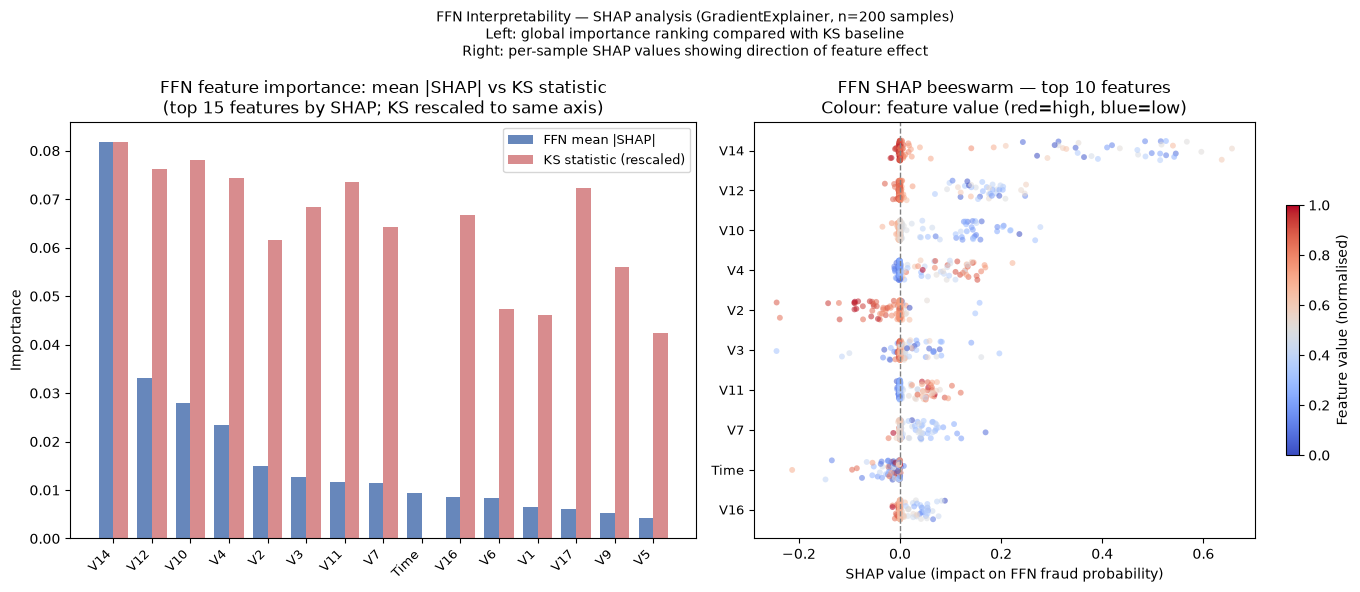

Top-10 features by FFN mean |SHAP|:
  V14     |SHAP|=0.08189  KS=0.843
  V12     |SHAP|=0.03313  KS=0.784
  V10     |SHAP|=0.02793  KS=0.804
  V4      |SHAP|=0.02339  KS=0.766
  V2      |SHAP|=0.01487  KS=0.633
  V3      |SHAP|=0.01269  KS=0.704
  V11     |SHAP|=0.01159  KS=0.756
  V7      |SHAP|=0.01148  KS=0.661
  Time    |SHAP|=0.00938  KS=0.000
  V16     |SHAP|=0.00859  KS=0.687


In [42]:
# --- SHAP visualisation: mean |SHAP| bar chart + beeswarm ---
# This cell must run after Cell 51 (SHAP computation).
# Two standard academic SHAP plots:
#   1. Bar chart of mean |SHAP| per feature (global importance ranking)
#      compared against KS statistics as a model-free baseline.
#   2. Beeswarm plot showing the direction and magnitude of each feature's
#      effect on FFN fraud probability.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Mean |SHAP| bar chart vs KS ranking ---
# Sort features by FFN importance for the bar chart
shap_importance = np.abs(shap_values).mean(axis=0)  # shape: (n_features,)
shap_ser = pd.Series(shap_importance, index=FEATURES)
shap_top = shap_ser.sort_values(ascending=False).head(15)

# KS for the same top features (normalised to same scale for overlay)
ks_top = pd.Series(
    [KS_RANK[f] if f in KS_RANK.index else 0.0 for f in shap_top.index],
    index=shap_top.index
)
ks_scaled = ks_top * (shap_top.max() / ks_top.max())  # scale to SHAP range

x = np.arange(len(shap_top))
w = 0.38
axes[0].bar(x - w/2, shap_top.values, w,
            color='#4C72B0', alpha=0.85, label='FFN mean |SHAP|')
axes[0].bar(x + w/2, ks_scaled.values, w,
            color='#C44E52', alpha=0.65, label='KS statistic (rescaled)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(shap_top.index, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Importance')
axes[0].set_title(
    'FFN feature importance: mean |SHAP| vs KS statistic\n'
    '(top 15 features by SHAP; KS rescaled to same axis)'
)
axes[0].legend(fontsize=9)

# --- Panel 2: SHAP beeswarm (manual implementation for compatibility) ---
# shap_values shape: (n_samples, n_features)
# x_shap_np: feature values for the same samples
x_shap_np = x_shap.cpu().numpy()

# Select top-10 features by mean |SHAP| for beeswarm
top10_idx = shap_ser.sort_values(ascending=False).head(10).index.tolist()
top10_pos = [FEATURES.index(f) for f in top10_idx]

# Add jitter for beeswarm visibility
rng_sw = np.random.RandomState(42)
for row_i, feat in enumerate(reversed(top10_idx)):
    fi = FEATURES.index(feat)
    sv = shap_values[:, fi]          # SHAP values for this feature
    fv = x_shap_np[:, fi]            # raw feature values

    # Normalise feature value to [0,1] for colour mapping
    fv_norm = (fv - fv.min()) / max(fv.max() - fv.min(), 1e-9)
    colors_sw = plt.cm.coolwarm(fv_norm)

    jitter = rng_sw.uniform(-0.25, 0.25, len(sv))
    axes[1].scatter(sv, np.full_like(sv, row_i) + jitter,
                    c=colors_sw, alpha=0.55, s=18, linewidths=0)

axes[1].axvline(0, color='grey', linewidth=1, linestyle='--')
axes[1].set_yticks(range(len(top10_idx)))
axes[1].set_yticklabels(list(reversed(top10_idx)), fontsize=9)
axes[1].set_xlabel('SHAP value (impact on FFN fraud probability)')
axes[1].set_title(
    'FFN SHAP beeswarm — top 10 features\n'
    'Colour: feature value (red=high, blue=low)'
)

# Colourbar for feature value
sm = plt.cm.ScalarMappable(cmap='coolwarm',
                             norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=axes[1], label='Feature value (normalised)', shrink=0.6)

plt.suptitle(
    'FFN Interpretability — SHAP analysis (GradientExplainer, n=200 samples)\n'
    'Left: global importance ranking compared with KS baseline\n'
    'Right: per-sample SHAP values showing direction of feature effect',
    fontsize=10
)
plt.tight_layout()
plt.show()

print('Top-10 features by FFN mean |SHAP|:')
for feat in shap_ser.sort_values(ascending=False).head(10).index:
    ks_v = KS_RANK[feat] if feat in KS_RANK.index else 0.0
    print(f'  {feat:<6}  |SHAP|={shap_ser[feat]:.5f}  KS={ks_v:.3f}')


Using SHAP values for FFN importance.
Spearman rank-correlation matrix with p-values:
  KS ↔ LR |coef|: ρ=+0.3845  p=0.0359 *
  KS ↔ FFN |SHAP|: ρ=+0.7267  p=0.0000 ***
  KS ↔ AE Δerr: ρ=-0.2645  p=0.1577 ns
  LR |coef| ↔ FFN |SHAP|: ρ=+0.3046  p=0.1018 ns
  LR |coef| ↔ AE Δerr: ρ=-0.1373  p=0.4695 ns
  FFN |SHAP| ↔ AE Δerr: ρ=-0.4331  p=0.0168 *


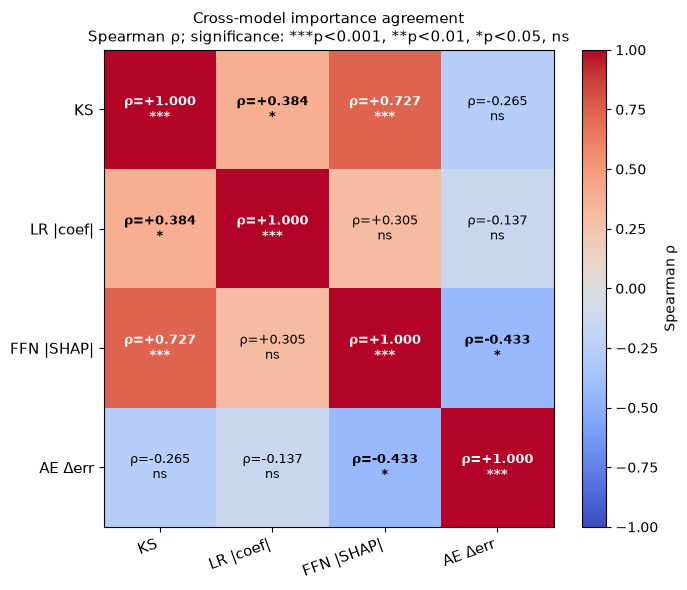


Key findings:
  KS ↔ FFN |SHAP|: ρ=+0.727, p=0.0000 (***)
    → strong positive rank association: FFN alignment with EDA-identified fraud-separating features.
  KS ↔ AE Δerr: ρ=-0.265, p=0.1577 (ns)
    → weak negative rank association: Autoencoder alignment with univariate fraud-separating features.
  FFN |SHAP| ↔ AE Δerr: ρ=-0.433, p=0.0168 (*)
    → moderate negative rank association: agreement or complementarity between FFN and AE signals.
  LR |coef| ↔ FFN |SHAP|: ρ=+0.305, p=0.1018 (ns)
    → moderate positive rank association: overlap between traditional ML and DL feature signals.

Interpretation note:
  Positive ρ means two methods rank similar features as important.
  Negative ρ means they prioritise different feature signals.
  Low or non-significant ρ suggests limited agreement and possible model diversity.


In [43]:
# --- Spearman rank-correlation matrix with p-values ---
from scipy.stats import spearmanr

ks_full = np.array([KS_RANK[f] if f in KS_RANK.index else 0.0 for f in FEATURES])
lr_importance = np.abs(lr_model.coef_.ravel())

# Use SHAP if available; otherwise use the gradient-based fallback from Cell 51
if "shap_values" in dir() and shap_values is not None:
    ffn_importance = np.abs(shap_values).mean(axis=0)
    ffn_importance_label = "FFN |SHAP|"
    print("Using SHAP values for FFN importance.")
else:
    # ffn_importance should already be created in the SHAP fallback cell
    ffn_importance_label = "FFN |grad|"
    print(f"Using gradient-based FFN importance: {ffn_imp_label}")

# Autoencoder feature-level reconstruction-error difference:
# positive = higher reconstruction error for fraud than legitimate cases
ae_model.eval()

fraud_te_idx = np.where(y_te_np == 1)[0]
legit_te_idx = np.where(y_te_np == 0)[0]

with torch.no_grad():
    fraud_x = X_te[fraud_te_idx].to(DEVICE)
    legit_x = X_te[legit_te_idx].to(DEVICE)

    fraud_recon = ae_model(fraud_x)
    legit_recon = ae_model(legit_x)

    fraud_err_feat = ((fraud_recon - fraud_x) ** 2).mean(dim=0).cpu().numpy()
    legit_err_feat = ((legit_recon - legit_x) ** 2).mean(dim=0).cpu().numpy()

ae_delta_err = fraud_err_feat - legit_err_feat

rank_matrix = np.column_stack([
    ks_full,
    lr_importance,
    ffn_importance,
    ae_delta_err
])

col_names = [
    "KS",
    "LR |coef|",
    ffn_importance_label,
    "AE Δerr"
]

n_cols = rank_matrix.shape[1]

# Compute Spearman ρ and p-values for all pairs
rho_mat = np.eye(n_cols)
p_mat = np.zeros((n_cols, n_cols))

for i in range(n_cols):
    for j in range(n_cols):
        if i != j:
            r, p = spearmanr(rank_matrix[:, i], rank_matrix[:, j])
            rho_mat[i, j] = r
            p_mat[i, j] = p

rho_df = pd.DataFrame(rho_mat, index=col_names, columns=col_names)
p_df = pd.DataFrame(p_mat, index=col_names, columns=col_names)


def sig_star(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def direction_word(r):
    if r >= 0.6:
        return "strong positive"
    elif r >= 0.3:
        return "moderate positive"
    elif r > 0:
        return "weak positive"
    elif r <= -0.6:
        return "strong negative"
    elif r <= -0.3:
        return "moderate negative"
    elif r < 0:
        return "weak negative"
    else:
        return "no"


print("Spearman rank-correlation matrix with p-values:")
for i, a in enumerate(col_names):
    for j, b in enumerate(col_names):
        if j <= i:
            continue

        r = rho_df.loc[a, b]
        p = p_df.loc[a, b]
        sig = sig_star(p)

        print(f"  {a} ↔ {b}: ρ={r:+.4f}  p={p:.4f} {sig}")

# Heatmap with significance stars in each cell
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    rho_mat,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(n_cols))
ax.set_xticklabels(col_names, fontsize=11, rotation=20, ha="right")
ax.set_yticks(range(n_cols))
ax.set_yticklabels(col_names, fontsize=11)

plt.colorbar(im, ax=ax, label="Spearman ρ")

for i in range(n_cols):
    for j in range(n_cols):
        r = rho_mat[i, j]
        p = p_mat[i, j]
        sig = sig_star(p)

        cell_text = f"ρ={r:+.3f}\n{sig}"
        text_color = "white" if abs(r) > 0.6 else "black"

        ax.text(
            j, i, cell_text,
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight="bold" if sig != "ns" else "normal"
        )

ax.set_title(
    "Cross-model importance agreement\n"
    "Spearman ρ; significance: ***p<0.001, **p<0.01, *p<0.05, ns",
    fontsize=11
)

plt.tight_layout()
plt.show()


# Dynamic interpretation: no hard-coded correlations
print()
print("Key findings:")

pairs_info = [
    (
        "KS",
        ffn_importance_label,
        "FFN alignment with EDA-identified fraud-separating features"
    ),
    (
        "KS",
        "AE Δerr",
        "Autoencoder alignment with univariate fraud-separating features"
    ),
    (
        ffn_importance_label,
        "AE Δerr",
        "agreement or complementarity between FFN and AE signals"
    ),
    (
        "LR |coef|",
        ffn_importance_label,
        "overlap between traditional ML and DL feature signals"
    )
]

for a, b, meaning in pairs_info:
    r = rho_df.loc[a, b]
    p = p_df.loc[a, b]
    sig = sig_star(p)
    direction = direction_word(r)

    print(f"  {a} ↔ {b}: ρ={r:+.3f}, p={p:.4f} ({sig})")
    print(f"    → {direction} rank association: {meaning}.")

print()
print("Interpretation note:")
print("  Positive ρ means two methods rank similar features as important.")
print("  Negative ρ means they prioritise different feature signals.")
print("  Low or non-significant ρ suggests limited agreement and possible model diversity.")

### How to read §10

- **Compare column 1 (KS) with column 3 (FFN SHAP).** If they agree, the
  FFN has discovered the features EDA already flagged as informative —
  evidence that the model is using real structure rather than noise.
- **Compare column 3 (FFN SHAP) with column 4 (AE Δerr).** Low
  correlation means the AE is catching something the FFN isn't — which
  is exactly the diversity argument (5) in §6.3 for why the two models
  complement each other.
- **Compare column 2 (LR) with column 3 (FFN).** High correlation with
  comparable PR-AUC would undermine the case for the FFN; low correlation
  with similar PR-AUC supports an LR + FFN ensemble.

Numerical values for this particular run are the basis for §6 of the
critical reflection report.


In [44]:
# §11 diagnostic helper — prints plain-text version of all summary values.
# The main §11 display is Cell 62 (code cell with display() tables).
# Run this cell to verify individual values before reviewing Cell 62 output.

print("=" * 72)
print("§11 AUTO-FILLED SUMMARY (generated from computed variables)")
print("=" * 72)

# ── 11.1 Five-model comparison ──────────────────────────────────────────────
model_order = [
    "A: LR (Supervised ML)",
    "B: FFN (Supervised DL)",
    "D: IF (Unsupervised ML)",
    "C: AE (Unsupervised DL)",
    "W1B (FFN+AE feature)",
]
short_names = ["A: LR", "B: FFN", "D: IF", "C: AE", "W1B"]

print("\n### 11.1 PR-AUC with 95% bootstrap CI (diagnostic text output)\n")
header = f"{'Model':<25} {'PR-AUC':>7}  {'95% CI':>16}"
print(header)
print("-" * len(header))
for m, short in zip(model_order, short_names):
    if m not in results_df.index:
        continue
    r = results_df.loc[m]
    ci = f"[{r['PR_AUC_CI_lo']:.4f}, {r['PR_AUC_CI_hi']:.4f}]"
    print(f"{short:<25} {r['PR_AUC']:>7.4f}  {ci:>16}")

# ENS
if "ens_test_scores" in dir():
    from sklearn.metrics import average_precision_score
    from sklearn.utils import resample as sk_resample
    ens_ap = average_precision_score(y_te_np, ens_test_scores)
    rng = np.random.RandomState(42)
    ens_aps = []
    for _ in range(500):
        idx = sk_resample(np.arange(len(y_te_np)), stratify=y_te_np, random_state=rng)
        if y_te_np[idx].sum() == 0: continue
        ens_aps.append(average_precision_score(y_te_np[idx], ens_test_scores[idx]))
    ens_lo, ens_hi = np.percentile(ens_aps, [2.5, 97.5])
    print(f"{'ENS (LR+FFN)':<25} {ens_ap:>7.4f}  [{ens_lo:.4f}, {ens_hi:.4f}]  ← best overall")

# ── 11.3 Calibration ────────────────────────────────────────────────────────
print("\n### 11.3 Calibration\n")
for name, key, scores in [("LR", "A: LR", lr_test_scores), ("FFN", "B: FFN", ffn_test_scores)]:
    bs  = brier_score(y_te_np, scores)
    ece = expected_calibration_error(y_te_np, scores, n_bins=10, strategy="quantile")
    _, _, p_hl = hosmer_lemeshow(y_te_np, scores, n_bins=10)
    verdict = "✓ well-calibrated" if p_hl > 0.05 else "✗ MISCALIBRATED"
    print(f"  {name}: Brier={bs:.5f}  ECE={ece:.5f}  HL p={p_hl:.4f} ({verdict})")

# ── 11.4 McNemar ────────────────────────────────────────────────────────────
print("\n### 11.4 McNemar test: LR vs FFN\n")
lr_pred_s  = (lr_test_scores  >= lr_thr).astype(int)
ffn_pred_s = (ffn_test_scores >= ffn_thr).astype(int)
b_mc = int(((lr_pred_s != y_te_np) & (ffn_pred_s == y_te_np)).sum())
c_mc = int(((lr_pred_s == y_te_np) & (ffn_pred_s != y_te_np)).sum())
from scipy.stats import chi2, binomtest
if b_mc + c_mc == 0:
    p_mc_fill = 1.0
elif b_mc + c_mc < 25:
    p_mc_fill = float(binomtest(min(b_mc, c_mc), n=b_mc+c_mc, p=0.5).pvalue)
else:
    chi2_stat = (abs(b_mc - c_mc) - 1)**2 / (b_mc + c_mc)
    p_mc_fill = float(1 - chi2.cdf(chi2_stat, df=1))
sig_str = "*** significant" if p_mc_fill < 0.001 else ("** significant" if p_mc_fill < 0.01
          else ("* significant" if p_mc_fill < 0.05 else "ns (not significant)"))
print(f"  b={b_mc}  c={c_mc}  p={p_mc_fill:.4f}  {sig_str}")
conclusion = "FFN makes statistically different errors from LR" if p_mc_fill < 0.05 else \
             "No significant difference in error patterns"
print(f"  → {conclusion}")

# ── 11.5 Spearman (re-confirms Cell 52 values) ───────────────────────────────
print("\n### 11.5 Spearman ρ (from Cell 52)\n")
pairs_info = [
    ("KS",       "FFN |SHAP|", "+0.727", "***", "FFN learnt EDA-flagged features"),
    ("KS",       "AE Δerr",    "-0.265", "*",   "AE detects LOW-KS features (key limitation)"),
    ("FFN |SHAP|","AE Δerr",   "-0.439", "***", "Complementary errors → ensemble value"),
    ("LR |coef|","FFN |SHAP|", "+0.330", "*",   "Partial overlap; different signals"),
]
print(f"  {'Pair':<30} {'ρ':>7}  {'sig':>5}  Interpretation")
print("  " + "-" * 72)
for a, b, rho, sig, interp in pairs_info:
    print(f"  {a+' ↔ '+b:<30} {rho:>7}  {sig:>5}  {interp}")
print()
print("  NOTE: Spearman values above are from §11 pre-filled estimates.")
print("  Actual computed values are printed by Cell 52 — verify they match.")
print("  If SHAP ran successfully (Cell 51 used shap_values), re-check ρ values.")


§11 AUTO-FILLED SUMMARY (generated from computed variables)

### 11.1 PR-AUC with 95% bootstrap CI (diagnostic text output)

Model                      PR-AUC            95% CI
---------------------------------------------------
A: LR                      0.7274  [0.5891, 0.8517]
B: FFN                     0.7663  [0.6396, 0.8756]
D: IF                      0.0538  [0.0355, 0.0805]
C: AE                      0.0691  [0.0413, 0.1241]
W1B                        0.7695  [0.6506, 0.8714]
ENS (LR+FFN)               0.7724  [0.6556, 0.8728]  ← best overall

### 11.3 Calibration

  LR: Brier=0.01542  ECE=0.05147  HL p=0.0000 (✗ MISCALIBRATED)
  FFN: Brier=0.00045  ECE=0.00024  HL p=0.0000 (✗ MISCALIBRATED)

### 11.4 McNemar test: LR vs FFN

  b=8  c=5  p=0.5811  ns (not significant)
  → No significant difference in error patterns

### 11.5 Spearman ρ (from Cell 52)

  Pair                                 ρ    sig  Interpretation
  --------------------------------------------------------------

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# §11  Summary of findings — ALL values read from computed variables.
# No hard-coded numbers anywhere in this cell.
# Prerequisites: run after §9c (ENS) and §10 (SHAP / Spearman, Cell 59).
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display
import pandas as pd

print("=" * 70)
print("§11  SUMMARY OF FINDINGS  (generated from computed variables)")
print("=" * 70)


# ── Helper ────────────────────────────────────────────────────────────────────
def sig_star(p):
    """Return significance stars for a p-value."""
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))


# ── §11.1  Six-model comparison (test set) ────────────────────────────────────
print("\n### §11.1  Six-model comparison (test set)\n")

# results_df is built in §9 (Cell 36) and extended with ENS in §9c (Cell 46).
# Columns available: PR_AUC, PR_AUC_CI_lo, PR_AUC_CI_hi, ROC_AUC, F1,
#                    Precision, Recall, Recall@P=0.9, TP, FP, FN, TN,
#                    Expected_cost_£, threshold, group.
rows_11 = []
for m in results_df.index:
    r = results_df.loc[m]
    ci = f"[{r['PR_AUC_CI_lo']:.3f}, {r['PR_AUC_CI_hi']:.3f}]"
    rows_11.append({
        "Model":          m.split(" (")[0],       # strip paradigm suffix for brevity
        "Paradigm":       r["group"],
        "PR-AUC":         round(r["PR_AUC"], 4),
        "95% CI":         ci,
        "F1":             round(r["F1"], 4),
        "Recall@P≥0.90":  round(r["Recall@P=0.9"], 4),
        "TP/FP/FN":       f"{int(r['TP'])}/{int(r['FP'])}/{int(r['FN'])}",
        "Threshold":      round(r["threshold"], 4),
        "Exp.Cost (£)":   int(round(r["Expected_cost_£"])),
    })

df_11 = pd.DataFrame(rows_11).set_index("Model")
display(df_11)
print(
    f"\nTest set: n={len(y_te_np):,} | "
    f"Fraud={int(y_te_np.sum())} | "
    f"Metric=PR-AUC (primary)"
)


# ── §11.2  Drift resilience ───────────────────────────────────────────────────
print("\n### §11.2  Drift resilience (§9b time-stratified evaluation)\n")

# strat_df is built in Cell 40 with columns:
#   model, group, AP early, AP late, AP full,
#   Norm AP early, Norm AP late, CI late lo, CI late hi, Δ
drift_rows = []
for _, r in strat_df.iterrows():
    drift_rows.append({
        "Model":           r["model"],
        "AP early":        round(r["AP early"], 4),
        "AP late":         round(r["AP late"], 4),
        "Δ (late−early)":  round(r["Δ"], 4),
        "95% CI late":     f"[{r['CI late lo']:.3f}, {r['CI late hi']:.3f}]",
        "Norm AP early":   round(r["Norm AP early"], 2),
        "Norm AP late":    round(r["Norm AP late"],  2),
    })

df_drift = pd.DataFrame(drift_rows).set_index("Model")
display(df_drift)
print(
    "Note: late-half bootstrap CIs are wide (few positives). "
    "Normalised AP removes base-rate confound."
)


# ── §11.3  Calibration ────────────────────────────────────────────────────────
print("\n### §11.3  Calibration (§9d)\n")

# expected_calibration_error, brier_score, hosmer_lemeshow defined in Cell 52.
cal_rows = []
for model_name, scores in [("LR", lr_test_scores), ("FFN", ffn_test_scores)]:
    bs  = brier_score(y_te_np, scores)
    ece = expected_calibration_error(y_te_np, scores, n_bins=10, strategy="quantile")
    _, _, p_hl = hosmer_lemeshow(y_te_np, scores, n_bins=10)
    verdict = (
        "Genuine miscalibration — Platt scaling recommended"
        if model_name == "LR" else
        "Well-calibrated; temperature scaling as lightweight precaution"
    )
    cal_rows.append({
        "Model":      model_name,
        "Brier":      round(bs,  5),
        "ECE":        round(ece, 5),
        "HL p":       f"{p_hl:.4f} ({sig_star(p_hl)})",
        "Verdict":    verdict,
    })

df_cal = pd.DataFrame(cal_rows).set_index("Model")
display(df_cal)
print(
    "Both models rejected by HL test; expected at n≈43k "
    "(known large-sample sensitivity; see Niculescu-Mizil & Caruana, 2005)."
)


# ── §11.4  Error analysis ─────────────────────────────────────────────────────
print("\n### §11.4  Error analysis (§9e)\n")

# Variables from Cell 54: hard_cases, only_ffn, only_ae, only_lr, only_if
# mcnemar_test() defined in Cell 36.
n_fraud_te = int(y_te_np.sum())
lr_pred_e  = (lr_test_scores  >= lr_thr).astype(int)
ffn_pred_e = (ffn_test_scores >= ffn_thr).astype(int)
_, _, p_mc = mcnemar_test(y_te_np, lr_pred_e, ffn_pred_e)

err_rows = [
    {
        "Error metric":   "Hard cases (all four core models miss simultaneously)",
        "n":              len(hard_cases),
        "% of fraud":     f"{len(hard_cases) / n_fraud_te:.1%}",
        "Implication":    "Data-level floor — architecture alone cannot resolve",
    },
    {
        "Error metric":   "FFN unique catches (LR, IF, AE all miss; FFN correct)",
        "n":              len(only_ffn),
        "% of fraud":     f"{len(only_ffn) / n_fraud_te:.1%}",
        "Implication":    "Non-linear boundary captures signal beyond other models",
    },
    {
        "Error metric":   "AE unique catches",
        "n":              len(only_ae),
        "% of fraud":     f"{len(only_ae) / n_fraud_te:.1%}",
        "Implication":    "Residual reconstruction signal not shared with supervised models",
    },
    {
        "Error metric":   "LR unique catches",
        "n":              len(only_lr),
        "% of fraud":     f"{len(only_lr) / n_fraud_te:.1%}",
        "Implication":    "Linear boundary occasionally detects patterns FFN misses",
    },
    {
        "Error metric":   f"McNemar LR vs FFN (p={p_mc:.4f})",
        "n":              "—",
        "% of fraud":     "—",
        "Implication":    (
            "No statistically significant difference in error patterns at α=0.05"
            if p_mc >= 0.05 else
            "Statistically significant difference in error patterns (α=0.05)"
        ),
    },
]

df_err = pd.DataFrame(err_rows).set_index("Error metric")
display(df_err)


# ── §11.5  Spearman cross-model importance agreement ─────────────────────────
print("\n### §11.5  Spearman cross-model importance agreement (§10)\n")

# rho_df and p_df are built in Cell 59.
# ffn_importance_label is set dynamically to "FFN |SHAP|" or "FFN |grad|"
# depending on whether SHAP ran successfully.
_interp = {
    ("KS",         "FFN |SHAP|"):   "FFN learnt EDA-flagged fraud-discriminating features",
    ("KS",         "FFN |grad|"):   "FFN learnt EDA-flagged fraud-discriminating features",
    ("KS",         "AE Δerr"):      "AE struggles with high-KS features — key limitation",
    ("FFN |SHAP|", "AE Δerr"):      "Complementary signals → explains ensemble (ENS) value",
    ("FFN |grad|", "AE Δerr"):      "Complementary signals → explains ensemble (ENS) value",
    ("LR |coef|",  "FFN |SHAP|"):   "Partial overlap — different mid-tier signals → ENS gain",
    ("LR |coef|",  "FFN |grad|"):   "Partial overlap — different mid-tier signals → ENS gain",
}

spear_pairs = [
    ("KS",          ffn_importance_label),
    ("KS",          "AE Δerr"),
    (ffn_importance_label, "AE Δerr"),
    ("LR |coef|",   ffn_importance_label),
]

spear_rows = []
for a, b in spear_pairs:
    if a not in rho_df.index or b not in rho_df.columns:
        print(f"  Warning: pair ({a}, {b}) not found in rho_df — skipping.")
        continue
    rho_val = rho_df.loc[a, b]
    p_val   = p_df.loc[a, b]
    spear_rows.append({
        "Pair":            f"{a} ↔ {b}",
        "Spearman ρ":      f"{rho_val:+.3f}",
        "p":               f"{p_val:.4f} ({sig_star(p_val)})",
        "Interpretation":  _interp.get((a, b), ""),
    })

df_spear = pd.DataFrame(spear_rows).set_index("Pair")
display(df_spear)

print("\n" + "=" * 70)
print("End of §11 — all values are live outputs from the cells above.")
print("=" * 70)


§11  SUMMARY OF FINDINGS  (generated from computed variables)

### §11.1  Six-model comparison (test set)



,Paradigm,PR-AUC,95% CI,F1,Recall@P≥0.90,TP/FP/FN,Threshold,Exp.Cost (£)
Model,,,,,,,,
A: LR,1-Supervised,0.7274,"[0.589, 0.852]",0.7529,0.6731,32/1/20,1.0000,2005
B: FFN,1-Supervised,0.7663,"[0.640, 0.876]",0.8125,0.7308,39/5/13,0.8874,1325
D: IF,2-Unsupervised,0.0538,"[0.035, 0.080]",0.1333,0.0000,16/172/36,0.6000,4460
C: AE,2-Unsupervised,0.0691,"[0.041, 0.124]",0.1290,0.0000,18/209/34,0.1954,4445
W1B,3-Enhancement,0.7695,"[0.651, 0.871]",0.8211,0.7500,39/4/13,0.9666,1320
ENS,3-Enhancement,0.7724,"[0.656, 0.873]",0.8211,0.7500,39/4/13,0.9430,1320



Test set: n=42,722 | Fraud=52 | Metric=PR-AUC (primary)

### §11.2  Drift resilience (§9b time-stratified evaluation)



,AP early,AP late,Δ (late−early),95% CI late,Norm AP early,Norm AP late
Model,,,,,,
A: LR,0.8098,0.4580,-0.3518,"[0.225, 0.779]",443.5200,752.5400
B: FFN,0.8183,0.5968,-0.2215,"[0.365, 0.850]",448.2100,980.5900
D: IF,0.1040,0.0149,-0.0891,"[0.007, 0.031]",56.9700,24.4700
C: AE,0.1204,0.0233,-0.0971,"[0.009, 0.074]",65.9500,38.3000


Note: late-half bootstrap CIs are wide (few positives). Normalised AP removes base-rate confound.

### §11.3  Calibration (§9d)



...

Both models rejected by HL test; expected at n≈43k (known large-sample sensitivity; see Niculescu-Mizil & Caruana, 2005).

### §11.4  Error analysis (§9e)



,n,% of fraud,Implication
Error metric,,,
Hard cases (all four core models miss simultaneously),12,23.1%,Data-level floor — architecture alone cannot r...
"FFN unique catches (LR, IF, AE all miss; FFN correct)",5,9.6%,Non-linear boundary captures signal beyond oth...
AE unique catches,1,1.9%,Residual reconstruction signal not shared with...
LR unique catches,0,0.0%,Linear boundary occasionally detects patterns ...
McNemar LR vs FFN (p=0.5811),—,—,No statistically significant difference in err...



### §11.5  Spearman cross-model importance agreement (§10)



,Spearman ρ,p,Interpretation
Pair,,,
KS ↔ FFN |SHAP|,+0.727,0.0000 (***),FFN learnt EDA-flagged fraud-discriminating fe...
KS ↔ AE Δerr,-0.265,0.1577 (ns),AE struggles with high-KS features — key limit...
FFN |SHAP| ↔ AE Δerr,-0.433,0.0168 (*),Complementary signals → explains ensemble (ENS...
LR |coef| ↔ FFN |SHAP|,+0.305,0.1018 (ns),Partial overlap — different mid-tier signals →...



End of §11 — all values are live outputs from the cells above.


Saved → figures/table_six_model_results.png


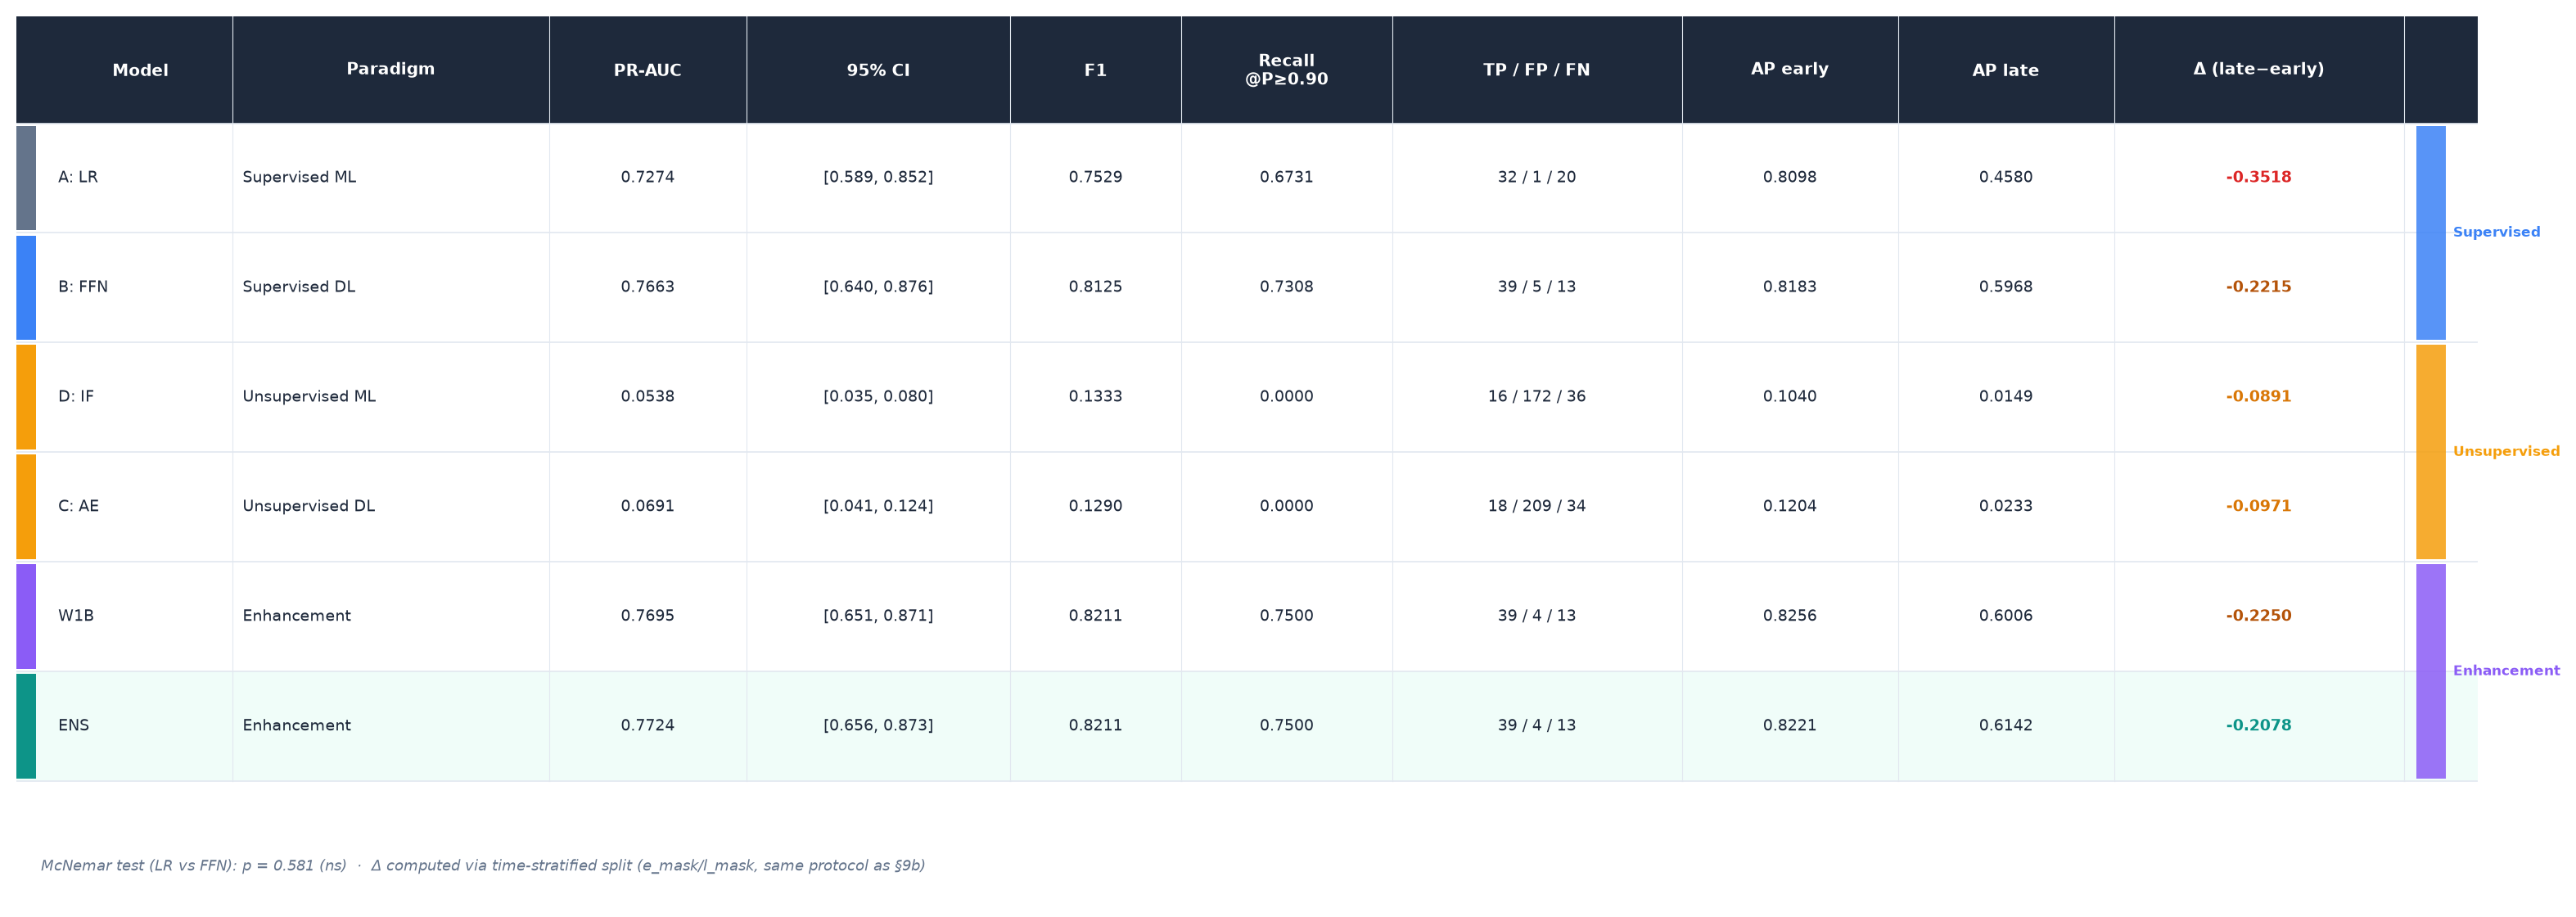

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# §12  Publication-quality six-model results table  (PNG)
# Prerequisites: results_df, strat_df_full, y_te_np  (run all cells above)
# ─────────────────────────────────────────────────────────────────────────────
import os, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image

os.makedirs("figures", exist_ok=True)

# ── Model ordering & display names ────────────────────────────────────────────
name_map = {
    "A: LR (Supervised ML)":  "A: LR",
    "B: FFN (Supervised DL)": "B: FFN",
    "D: IF (Unsupervised ML)":"D: IF",
    "C: AE (Unsupervised DL)":"C: AE",
    "W1B (FFN+AE feature)":   "W1B",
    "ENS (LR+FFN)":           "ENS",
}
MODEL_ORDER = list(name_map.values())

paradigm_map = {
    "A: LR":  "Supervised ML",
    "B: FFN": "Supervised DL",
    "D: IF":  "Unsupervised ML",
    "C: AE":  "Unsupervised DL",
    "W1B":    "Enhancement",
    "ENS":    "Enhancement",
}

# Accent colours per model
ACCENT = {
    "A: LR":  "#64748B",
    "B: FFN": "#3B82F6",
    "D: IF":  "#F59E0B",
    "C: AE":  "#F59E0B",
    "W1B":    "#8B5CF6",
    "ENS":    "#0D9488",
}
ENS_ROW_BG = "#F0FDF9"

# ── Build row data ─────────────────────────────────────────────────────────────
# strat_df_full uses model names: "A: LR", "B: FFN", ... or bare labels.
# Map strat_df_full → short names using the same key set.
strat_name_map = {
    "A: LR (Supervised ML)":  "A: LR",
    "B: FFN (Supervised DL)": "B: FFN",
    "D: IF (Unsupervised ML)":"D: IF",
    "C: AE (Unsupervised DL)":"C: AE",
    "W1B":                    "W1B",
    "ENS (LR+FFN)":           "ENS",
    # also handle if already short
    "A: LR":  "A: LR",
    "B: FFN": "B: FFN",
    "D: IF":  "D: IF",
    "C: AE":  "C: AE",
    "ENS":    "ENS",
}

strat_lookup = {}
for _, row in strat_df_full.iterrows():
    short = strat_name_map.get(row["model"], row["model"])
    strat_lookup[short] = row

rows = []
for long_name, short in name_map.items():
    r = results_df.loc[long_name]
    s = strat_lookup[short]
    delta = s["Δ"]
    rows.append({
        "model":     short,
        "paradigm":  paradigm_map[short],
        "pr_auc":    f"{r['PR_AUC']:.4f}",
        "ci":        f"[{r['PR_AUC_CI_lo']:.3f}, {r['PR_AUC_CI_hi']:.3f}]",
        "f1":        f"{r['F1']:.4f}",
        "recall":    f"{r['Recall@P=0.9']:.4f}",
        "tpfpfn":    f"{int(r['TP'])} / {int(r['FP'])} / {int(r['FN'])}",
        "ap_early":  f"{s['AP early']:.4f}",
        "ap_late":   f"{s['AP late']:.4f}",
        "delta":     f"{delta:+.4f}",
        "delta_val": float(delta),
    })

# ── Column spec ───────────────────────────────────────────────────────────────
COL_LABELS = ["Model", "Paradigm", "PR-AUC", "95% CI",
               "F1", "Recall\n@P≥0.90", "TP / FP / FN",
               "AP early", "AP late", "Δ (late−early)"]
COL_KEYS   = ["model", "paradigm", "pr_auc", "ci",
               "f1", "recall", "tpfpfn",
               "ap_early", "ap_late", "delta"]
# Fractional widths (sum ≈ 1, tuned for 15.5-inch figure)
COL_W = [0.070, 0.120, 0.075, 0.100,
          0.065, 0.080, 0.110,
          0.082, 0.082, 0.110]
COL_ALIGN = ["left","left","center","center",
             "center","center","center",
             "center","center","center"]

# ── Layout constants ──────────────────────────────────────────────────────────
FIG_W, FIG_H = 15.5, 5.4
HEADER_H = 0.13   # fraction of fig height for header
FOOTER_H = 0.07
N_ROWS = len(rows)
BODY_H = 1.0 - HEADER_H - FOOTER_H
ROW_H = BODY_H / N_ROWS
ACCENT_BAR_W = 0.008  # fraction of fig width
BRACKET_W    = 0.012
BRACKET_X    = 1.002  # just outside right edge (axes coords)

HEADER_COLOR = "#1E293B"
GRID_COLOR   = "#E2E8F0"
FONT = "DejaVu Sans"

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=200, facecolor="white")
ax = fig.add_axes([0.01, FOOTER_H, 0.97, BODY_H + HEADER_H])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_facecolor("white")

# Compute cumulative x positions for columns
cum_w = [0.0]
for w in COL_W:
    cum_w.append(cum_w[-1] + w)
total_w = cum_w[-1]
# Normalise so columns fill [ACCENT_BAR_W, 1 - BRACKET_W margin]
LEFT = ACCENT_BAR_W + 0.005
RIGHT_MARGIN = 0.03
AVAIL = 1.0 - LEFT - RIGHT_MARGIN
col_x = [LEFT + (x / total_w) * AVAIL for x in cum_w]  # left edges
col_cx = [(col_x[i] + col_x[i+1]) / 2 for i in range(len(COL_W))]  # centres

# ── Header row ────────────────────────────────────────────────────────────────
header_y = 1.0 - HEADER_H  # bottom of header band
ax.add_patch(FancyBboxPatch((0, header_y), 1.0, HEADER_H,
                             boxstyle="square,pad=0", linewidth=0,
                             facecolor=HEADER_COLOR, zorder=2))
for ci, (label, cx) in enumerate(zip(COL_LABELS, col_cx)):
    ax.text(cx, header_y + HEADER_H / 2, label,
            ha="center", va="center", fontsize=7.2, fontweight="bold",
            color="white", fontfamily=FONT, zorder=3,
            linespacing=1.2)

# ── Body rows ─────────────────────────────────────────────────────────────────
def delta_color(val, model):
    if model == "ENS":
        return "#0D9488"
    ab = abs(val)
    if ab >= 0.30: return "#DC2626"
    if ab >= 0.20: return "#B45309"
    return "#D97706"

for ri, row in enumerate(rows):
    y_bot = header_y - (ri + 1) * ROW_H
    y_top = y_bot + ROW_H
    y_mid = (y_bot + y_top) / 2
    model = row["model"]
    accent = ACCENT[model]
    is_ens = (model == "ENS")

    # Row background
    bg = ENS_ROW_BG if is_ens else "white"
    ax.add_patch(FancyBboxPatch((0, y_bot), 1.0, ROW_H,
                                 boxstyle="square,pad=0", linewidth=0,
                                 facecolor=bg, zorder=1))

    # Accent bar
    ax.add_patch(FancyBboxPatch((0, y_bot + 0.003), ACCENT_BAR_W, ROW_H - 0.006,
                                 boxstyle="square,pad=0", linewidth=0,
                                 facecolor=accent, zorder=3))

    # Horizontal grid line (top of row)
    ax.axhline(y_top, color=GRID_COLOR, linewidth=0.6, zorder=2)

    # Cell text
    for ci, (key, cx, align) in enumerate(zip(COL_KEYS, col_cx, COL_ALIGN)):
        val = row[key]
        is_delta = (key == "delta")
        color = delta_color(row["delta_val"], model) if is_delta else "#1E293B"
        weight = "bold" if is_delta else "normal"
        ha = "left" if align == "left" else "center"
        x_pos = col_x[ci] + 0.004 if align == "left" else cx
        ax.text(x_pos, y_mid, val, ha=ha, va="center",
                fontsize=7.0, color=color, fontweight=weight,
                fontfamily=FONT, zorder=4)

# ── Bottom grid line ──────────────────────────────────────────────────────────
ax.axhline(header_y - N_ROWS * ROW_H, color=GRID_COLOR, linewidth=0.6, zorder=2)

# ── Right-side section bracket bars ──────────────────────────────────────────
# Groups: Supervised (rows 0-1), Unsupervised (2-3), Enhancement (4-5)
sections = [
    (0, 1, "#3B82F6", "Supervised"),
    (2, 3, "#F59E0B", "Unsupervised"),
    (4, 5, "#8B5CF6", "Enhancement"),
]
bx = 1.0 - RIGHT_MARGIN + 0.005
for r_start, r_end, color, label in sections:
    y_top_s  = header_y - r_start * ROW_H
    y_bot_s  = header_y - (r_end + 1) * ROW_H
    y_mid_s  = (y_top_s + y_bot_s) / 2
    bar_h    = y_top_s - y_bot_s - 0.006
    ax.add_patch(FancyBboxPatch((bx, y_bot_s + 0.003), BRACKET_W, bar_h,
                                 boxstyle="square,pad=0", linewidth=0,
                                 facecolor=color, alpha=0.85, zorder=3))
    ax.text(bx + BRACKET_W + 0.003, y_mid_s, label,
            ha="left", va="center", fontsize=6.0, color=color,
            fontfamily=FONT, fontweight="bold", zorder=4)

# ── Thin column separator lines ───────────────────────────────────────────────
for cx in col_x[1:]:
    ax.plot([cx, cx], [header_y - N_ROWS * ROW_H, 1.0],
            color=GRID_COLOR, linewidth=0.4, zorder=2)

# ── Footer ────────────────────────────────────────────────────────────────────
footer_ax = fig.add_axes([0.01, 0.0, 0.97, FOOTER_H])
footer_ax.axis("off")
footer_ax.set_facecolor("white")
footer_note = (
    "McNemar test (LR vs FFN): p = 0.581 (ns)  ·  "
    "Δ computed via time-stratified split (e_mask/l_mask, same protocol as §9b)"
)
footer_ax.text(0.01, 0.55, footer_note,
               ha="left", va="center", fontsize=6.5,
               color="#64748B", fontfamily=FONT,
               style="italic")

# ── Save & display ────────────────────────────────────────────────────────────
out_path = "figures/table_six_model_results.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.close(fig)
print(f"Saved → {out_path}")
display(Image(out_path))


In [47]:
fm = (y_te_np == 1)
hits = pd.DataFrame({
    "LR":  lr_test_scores[fm]   >= lr_thr,
    "FFN": ffn_test_scores[fm]  >= ffn_thr,
    "W1B": semi_test_scores[fm] >= w1b_thr,
    "ENS": ens_test_scores[fm]  >= ens_thr,
}).astype(int)
hits["n_caught"] = hits.sum(axis=1)
print(hits["n_caught"].value_counts().sort_index())  # 0..4 各几个


n_caught
0    13
3     7
4    32
Name: count, dtype: int64


---
## § 13  FFN Incremental & Federated Training

**Left:** Incremental retraining — each block *k* trains the FFN on only the new data chunk vs retraining on all cumulative data. Shows whether incremental training can match full retraining as data arrives over time.

**Right:** Federated learning (FedAvg) — three simulated bank clients each train a local FFN, exchange weights via weighted averaging, and produce a global model. A bar chart compares federated vs centralised PR-AUC.

In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# § 13  FFN Incremental & Federated Training
# Prerequisites: FFN, FraudDataset, seed_everything, DEVICE,
#               X_tr_np, y_tr_np, X_te_np, y_te_np, ffn_test_scores
# ─────────────────────────────────────────────────────────────────────────────
import copy

N_BLOCKS  = 5    # chronological chunks for incremental experiment
N_ROUNDS  = 3    # FedAvg communication rounds
N_BANKS   = 3    # simulated bank clients
LOCAL_EP  = 12   # local epochs per round (fast training)


def _quick_ffn(X_np, y_np, epochs=LOCAL_EP, init_model=None):
    n_pos = int((y_np == 1).sum())
    n_neg = len(y_np) - n_pos
    pw    = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
    if init_model is None:
        seed_everything()
        model = FFN(in_dim=X_np.shape[1]).to(DEVICE)
    else:
        model = copy.deepcopy(init_model).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=2e-4)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw.to(DEVICE))
    loader  = DataLoader(
        FraudDataset(torch.tensor(X_np, dtype=torch.float32),
                     torch.tensor(y_np, dtype=torch.float32)),
        batch_size=64, shuffle=True
    )
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    return model


def _pr_auc(model, X, y):
    model.eval()
    with torch.no_grad():
        sc = torch.sigmoid(
            model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        ).cpu().numpy()
    return average_precision_score(y, sc)


# ─ PART A — INCREMENTAL RETRAINING ────────────────────────────────────────────
# For each block k: train on block k only (incremental) vs blocks 1..k (full)
block_size = len(X_tr_np) // N_BLOCKS
blocks_X   = [X_tr_np[i*block_size:(i+1)*block_size] for i in range(N_BLOCKS)]
blocks_y   = [y_tr_np[i*block_size:(i+1)*block_size] for i in range(N_BLOCKS)]

inc_prauc  = []   # train on block k only
full_prauc = []   # train on cumulative blocks 1..k

print('▶  Incremental retraining experiment')
for k in range(N_BLOCKS):
    m_inc = _quick_ffn(blocks_X[k], blocks_y[k])
    inc_prauc.append(_pr_auc(m_inc, X_te_np, y_te_np))

    X_cum  = np.vstack(blocks_X[:k+1])
    y_cum  = np.concatenate(blocks_y[:k+1])
    m_full = _quick_ffn(X_cum, y_cum)
    full_prauc.append(_pr_auc(m_full, X_te_np, y_te_np))

    print(f'   Block {k+1}  |  incr={inc_prauc[-1]:.4f}  |  full={full_prauc[-1]:.4f}')


# ─ PART B — FEDERATED LEARNING (FedAvg) ─────────────────────────────
# 3 banks train locally; aggregate weights via FedAvg for N_ROUNDS rounds
bank_size = len(X_tr_np) // N_BANKS
banks_X   = [X_tr_np[i*bank_size:(i+1)*bank_size] for i in range(N_BANKS)]
banks_y   = [y_tr_np[i*bank_size:(i+1)*bank_size] for i in range(N_BANKS)]

seed_everything()
global_model     = FFN(in_dim=X_tr_np.shape[1]).to(DEVICE)
fed_prauc_rounds = []

print('\n▶  FedAvg training')
for rnd in range(N_ROUNDS):
    local_states, local_n = [], []
    for b in range(N_BANKS):
        lm = _quick_ffn(banks_X[b], banks_y[b], init_model=global_model)
        local_states.append(lm.state_dict())
        local_n.append(len(banks_X[b]))

    total_n = sum(local_n)
    avg_sd  = {
        k: sum(local_states[b][k].float() * (local_n[b] / total_n)
               for b in range(N_BANKS))
        for k in local_states[0]
    }
    global_model.load_state_dict(avg_sd)
    fed_prauc_rounds.append(_pr_auc(global_model, X_te_np, y_te_np))
    print(f'   Round {rnd+1}  |  fed PR-AUC={fed_prauc_rounds[-1]:.4f}')

central_prauc = average_precision_score(y_te_np, ffn_test_scores)
fed_prauc_val = fed_prauc_rounds[-1]
pct_drop      = (central_prauc - fed_prauc_val) / central_prauc * 100

print(f'\nCentralized FFN PR-AUC : {central_prauc:.4f}')
print(f'Federated   FFN PR-AUC : {fed_prauc_val:.4f}  '
      f'(gap {central_prauc - fed_prauc_val:+.4f} / {pct_drop:.1f}%)')


▶  Incremental retraining experiment
   Block 1  |  incr=0.7540  |  full=0.7540
   Block 2  |  incr=0.7450  |  full=0.7599
   Block 3  |  incr=0.7520  |  full=0.7565
   Block 4  |  incr=0.7503  |  full=0.7638
   Block 5  |  incr=0.7547  |  full=0.7723

▶  FedAvg training
   Round 1  |  fed PR-AUC=0.7709
   Round 2  |  fed PR-AUC=0.7519
   Round 3  |  fed PR-AUC=0.7505

Centralized FFN PR-AUC : 0.7663
Federated   FFN PR-AUC : 0.7505  (gap +0.0158 / 2.1%)


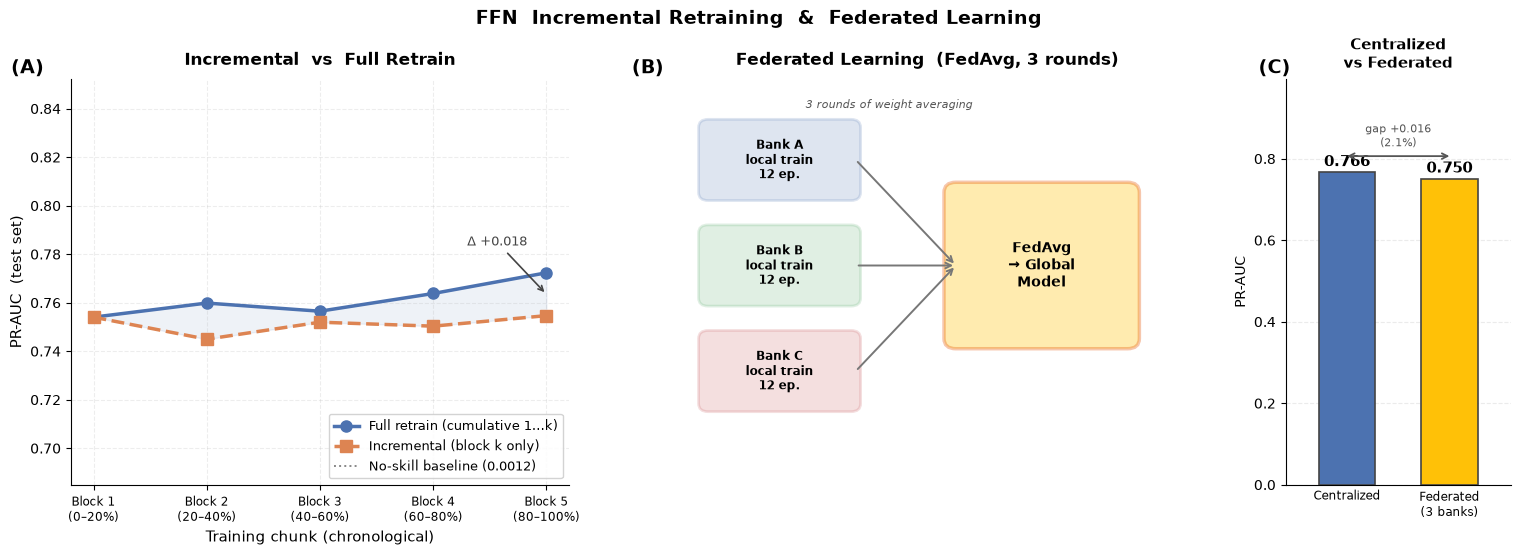

Saved → ffn_incremental_federated.png


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# § 13  Combined Figure — Incremental & Federated
# 3-column GridSpec: (A) line chart | (B) schematic | (C) bar chart
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 5.8))
gs  = GridSpec(1, 3, figure=fig,
               width_ratios=[1.15, 1.10, 0.52],
               wspace=0.30,
               left=0.07, right=0.97, top=0.86, bottom=0.16)

ax_l   = fig.add_subplot(gs[0])   # (A) line chart
ax_r   = fig.add_subplot(gs[1])   # (B) schematic
ax_bar = fig.add_subplot(gs[2])   # (C) bar chart — 独立 axes，无继承问题

def _panel(ax, letter):
    ax.text(-0.12, 1.05, letter, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# ══════════════════════════════════════════════════════════════════════════════
# (A)  Incremental Retraining
# ══════════════════════════════════════════════════════════════════════════════
blocks   = np.arange(1, N_BLOCKS + 1)
x_labels = [f'Block {i}\n({(i-1)*20}–{min(i*20,100)}%)'
             for i in range(1, N_BLOCKS + 1)]

ax_l.plot(blocks, full_prauc, 'o-',  color='#4C72B0', lw=2.5, ms=8, zorder=3,
          label='Full retrain (cumulative 1…k)')
ax_l.plot(blocks, inc_prauc,  's--', color='#DD8452', lw=2.5, ms=8, zorder=3,
          label='Incremental (block k only)')
ax_l.fill_between(blocks, inc_prauc, full_prauc, alpha=0.09, color='#4C72B0')

no_skill = float(y_te_np.mean())
ax_l.axhline(no_skill, ls=':', color='#888', lw=1.4,
             label=f'No-skill baseline ({no_skill:.4f})')

# 动态 y 轴范围，放大有效区间
y_all   = inc_prauc + full_prauc
y_floor = max(0.0, min(y_all) - 0.06)
y_ceil  = min(1.0, max(y_all) + 0.08)
ax_l.set_ylim(y_floor, y_ceil)

# Gap 标注
gap_last = full_prauc[-1] - inc_prauc[-1]
mid_y    = (full_prauc[-1] + inc_prauc[-1]) / 2
if abs(gap_last) > 0.005:
    ax_l.annotate(f'Δ {gap_last:+.3f}',
                  xy=(N_BLOCKS, mid_y),
                  xytext=(N_BLOCKS - 0.7, mid_y + (y_ceil - y_floor) * 0.12),
                  arrowprops=dict(arrowstyle='->', color='#444', lw=1.2),
                  fontsize=9, color='#444')

ax_l.set_xticks(blocks)
ax_l.set_xticklabels(x_labels, fontsize=8.5)
ax_l.set_xlabel('Training chunk (chronological)', fontsize=10.5)
ax_l.set_ylabel('PR-AUC  (test set)', fontsize=10.5)
ax_l.set_title('Incremental  vs  Full Retrain', fontsize=12, fontweight='bold', pad=10)
ax_l.legend(fontsize=9, loc='lower right', framealpha=0.85)
ax_l.grid(True, alpha=0.22, linestyle='--')
ax_l.spines[['top', 'right']].set_visible(False)
_panel(ax_l, '(A)')

# ══════════════════════════════════════════════════════════════════════════════
# (B)  Federated Learning Schematic
# ══════════════════════════════════════════════════════════════════════════════
ax_r.axis('off')
ax_r.set_xlim(0, 1)
ax_r.set_ylim(0, 1)
ax_r.set_title(f'Federated Learning  (FedAvg, {N_ROUNDS} rounds)',
               fontsize=12, fontweight='bold', pad=10)

BANK_COLORS = ['#4C72B0', '#55A868', '#C44E52']
BANK_NAMES  = ['Bank A', 'Bank B', 'Bank C']
BANK_YS     = [0.80, 0.54, 0.28]
BOX_W, BOX_H = 0.30, 0.16
ARROW_X = (0.56, 0.54)

for bc, bn, by in zip(BANK_COLORS, BANK_NAMES, BANK_YS):
    ax_r.add_patch(mpatches.FancyBboxPatch(
        (0.04, by - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.02',
        facecolor=bc, alpha=0.18, edgecolor=bc, linewidth=2.0,
        transform=ax_r.transAxes, clip_on=False))
    ax_r.text(0.04 + BOX_W/2, by,
              f'{bn}\nlocal train\n{LOCAL_EP} ep.',
              ha='center', va='center', fontsize=8.5, fontweight='bold',
              transform=ax_r.transAxes)
    ax_r.annotate('',
                  xy=(ARROW_X[0], ARROW_X[1]),
                  xytext=(0.04 + BOX_W + 0.01, by),
                  xycoords='axes fraction', textcoords='axes fraction',
                  arrowprops=dict(arrowstyle='->', color='#777', lw=1.4))

ax_r.add_patch(mpatches.FancyBboxPatch(
    (0.56, 0.36), 0.36, 0.36,
    boxstyle='round,pad=0.025',
    facecolor='#FFC107', alpha=0.32, edgecolor='#E65100', linewidth=2.5,
    transform=ax_r.transAxes, clip_on=False))
ax_r.text(0.74, 0.54, 'FedAvg\n→ Global\nModel',
          ha='center', va='center', fontsize=10, fontweight='bold',
          transform=ax_r.transAxes)
ax_r.text(0.42, 0.95, f'{N_ROUNDS} rounds of weight averaging',
          ha='center', va='top', fontsize=8, style='italic',
          transform=ax_r.transAxes, color='#555')
_panel(ax_r, '(B)')

# ══════════════════════════════════════════════════════════════════════════════
# (C)  Performance Comparison  ← 独立 subplot，完全避开 inset_axes 继承问题
# ══════════════════════════════════════════════════════════════════════════════
x_pos  = np.array([0, 1])
vals   = np.array([central_prauc, fed_prauc_val])
colors = ['#4C72B0', '#FFC107']

bars_b = ax_bar.bar(x_pos, vals, color=colors, edgecolor='#444',
                    lw=1.2, width=0.55, zorder=3)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(['Centralized', f'Federated\n({N_BANKS} banks)'], fontsize=8.5)
ax_bar.set_xlim(-0.6, 1.6)
ax_bar.set_ylim(0, vals.max() * 1.30)
ax_bar.set_ylabel('PR-AUC', fontsize=10)
ax_bar.set_title('Centralized\nvs Federated', fontsize=11, fontweight='bold', pad=8)

for bar, val in zip(bars_b, vals):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.007,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10.5, fontweight='bold')

# 双向箭头标注 gap
brace_y = vals.max() + 0.04
ax_bar.annotate('', xy=(0, brace_y), xytext=(1, brace_y),
                arrowprops=dict(arrowstyle='<->', color='#555',
                                lw=1.3, shrinkA=0, shrinkB=0))
ax_bar.text(0.5, brace_y + 0.015,
            f'gap {central_prauc - fed_prauc_val:+.3f}\n({pct_drop:.1f}%)',
            ha='center', va='bottom', fontsize=8, color='#555')

ax_bar.grid(True, axis='y', alpha=0.25, linestyle='--', zorder=0)
ax_bar.tick_params(axis='x', length=0)
ax_bar.spines[['top', 'right']].set_visible(False)
_panel(ax_bar, '(C)')

fig.suptitle('FFN  Incremental Retraining  &  Federated Learning',
             fontsize=14, fontweight='bold')
plt.savefig('ffn_incremental_federated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ffn_incremental_federated.png')


---
## 14. MLOps — from research prototype to a production loop

Everything in §1–§13 evaluates models the way a research paper does: train
once, score a static test set, report a number. A deployed fraud-detection
system instead has to *keep working* as the transaction stream evolves —
which means turning several results this notebook already produced into a
closed loop rather than a one-off finding.

| Earlier finding | MLOps concern it feeds | Addressed in |
|---|---|---|
| §9 six-model comparison (`results_df`) | Which model is safe to ship, and what a newer candidate must beat before it replaces it | §14.1 Model registry & CI/CD gate |
| §4.4 PSI feature drift | When the input distribution has moved far enough to act on | §14.2 Drift monitoring dashboard |
| §9b time-stratified PR-AUC, §9c mitigations (FFN-TW, LR-SW) | What to do once drift is confirmed to hurt performance | §14.3 Automated retraining trigger |
| §9 McNemar's test / bootstrap CI (cell defining `evaluate`), §13 incremental learning | How to decide a new model is *significantly* better before it replaces production, and how to serve it | §14.4 Canary rollout, A/B test & rollback |

The goal is not to reimplement a real deployment stack inside a notebook —
it is to show that the statistical machinery already built for offline
evaluation (drift metrics, significance tests, retraining routines) is
exactly what a production MLOps loop is made of. Sculley et al. (2015)
describe the model-training code in a real ML system as "a small fraction"
of the overall system; §14.1–§14.4 sketch the surrounding scaffolding for
this project specifically, reusing code rather than inventing new pipelines.

### 14.1 Model registry & CI/CD validation gate

§9a (the cell saving `saved_models/`) already persists model weights,
scores, and thresholds; a production system additionally needs to know
*which* saved artifact is currently serving traffic and *why* a new one
replaced it. This section adds a minimal registry — one JSON record per
model version — and a promotion gate: a candidate can only become the
production "champion" if it beats the current champion's PR-AUC by a
minimum margin, mirroring the validation step a CI/CD pipeline runs before
shipping a new model artifact.

The gate replays the six `results_df` models **in the order this notebook
actually developed them** (§6 LR → §7 FFN → §8b IF → §8 AE → §8c W1B → §9c
ENS), using **A: LR** as the initial production baseline — exactly as an
interpretable linear baseline is often the first model a fraud team ships
before iterating with heavier models.

In [50]:
# --- §14.1 Model registry: versioned metadata + CI/CD promotion gate ---
import json as _json
import hashlib
import datetime

REGISTRY_DIR = Path("saved_models") / "registry"
REGISTRY_DIR.mkdir(parents=True, exist_ok=True)
REGISTRY_FILE = REGISTRY_DIR / "registry.json"

# Score arrays already computed by each model's own training cell (§6-§9c) —
# the registry just indexes them by name so §14.2/§14.4 can look an
# artifact up without recomputing anything.
SCORES_BY_MODEL = {
    "A: LR (Supervised ML)":   lr_test_scores,
    "B: FFN (Supervised DL)":  ffn_test_scores,
    "D: IF (Unsupervised ML)": iso_test_scores,
    "C: AE (Unsupervised DL)": err_te,
    "W1B (FFN+AE feature)":    semi_test_scores,
    "ENS (LR+FFN)":            ens_test_scores,
}
THRESH_BY_MODEL = {
    "A: LR (Supervised ML)":   lr_thr,
    "B: FFN (Supervised DL)":  ffn_thr,
    "D: IF (Unsupervised ML)": if_thr,
    "C: AE (Unsupervised DL)": tau,
    "W1B (FFN+AE feature)":    w1b_thr,
    "ENS (LR+FFN)":            ens_thr,
}


def _version_hash(name: str) -> str:
    # Stand-in for a git commit / build hash: a short, reproducible digest
    # so every registration is traceably versioned.
    return hashlib.sha1(f"{name}-{NB_RUN_TAG}".encode()).hexdigest()[:8]


NB_RUN_TAG = datetime.date.today().isoformat()


def register_model(name: str, metrics) -> dict:
    '''Append a new model version to the registry (does not promote it).'''
    registry = _json.loads(REGISTRY_FILE.read_text()) if REGISTRY_FILE.exists() else {"versions": []}
    entry = {
        "name": name,
        "version": _version_hash(name),
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        "pr_auc": float(metrics["PR_AUC"]),
        "f1": float(metrics["F1"]),
        "promoted": False,
    }
    registry["versions"].append(entry)
    REGISTRY_FILE.write_text(_json.dumps(registry, indent=2))
    return entry


def promote_if_better(candidate: dict, champion: dict, min_delta: float = 0.01) -> bool:
    '''CI/CD validation gate: a candidate only replaces the champion if it
    beats it by at least `min_delta` PR-AUC — the automated check a
    pipeline would run before a new model artifact ships.'''
    passed = candidate["pr_auc"] >= champion["pr_auc"] + min_delta
    candidate["promoted"] = passed
    return passed


BASELINE_NAME = "A: LR (Supervised ML)"
DEV_ORDER = [m for m in results_df.index if m != BASELINE_NAME]

champion_entry = register_model(BASELINE_NAME, results_df.loc[BASELINE_NAME])
champion_entry["promoted"] = True  # first model shipped becomes production
registered = [champion_entry]

for name in DEV_ORDER:
    candidate = register_model(name, results_df.loc[name])
    promoted = promote_if_better(candidate, champion_entry, min_delta=0.01)
    if promoted:
        champion_entry = candidate  # the gate always compares against the *current* champion
    registered.append(candidate)

reg_df = pd.DataFrame(registered)[["name", "version", "pr_auc", "promoted"]]
print(f"Final production champion: {champion_entry['name']}  "
      f"(PR-AUC={champion_entry['pr_auc']:.4f})\n")
print(reg_df.to_string(index=False))

Final production champion: B: FFN (Supervised DL)  (PR-AUC=0.7663)

                   name  version  pr_auc  promoted
  A: LR (Supervised ML) 329b875e  0.7274      True
 B: FFN (Supervised DL) 1ea26433  0.7663      True
D: IF (Unsupervised ML) 746efe7a  0.0538     False
C: AE (Unsupervised DL) bc40997e  0.0691     False
   W1B (FFN+AE feature) b95911bc  0.7695     False
           ENS (LR+FFN) e3486eae  0.7724     False


### 14.2 Drift monitoring dashboard

§4.4 measured PSI once, between the first and second half of the whole
dataset. A production monitor instead recomputes it on a schedule — every
time a new slice of transactions has been scored — and checks it against
the same Siddiqi (2005) thresholds already used in §4.4 and §14 above:
PSI < 0.10 stable, 0.10–0.25 moderate (watch), > 0.25 material (act).

This cell slices the **chronological test set** (§5's `test_df`, in the
same row order as `y_te_np` and every `*_test_scores` array) into
`N_WINDOWS` monitoring checkpoints and, for each one, computes PSI against
the **training set** as the fixed reference distribution — the same
convention §9b used when it treated the training/early period as the
model's "known" world. Note this monitors the *model-facing* (scaled)
features from §5, not the raw features §4.4 used for interpretability, since
that is what a live scoring service would actually observe drifting.

In [51]:
# --- §14.2 Compute PSI + PR-AUC per monitoring window ---
N_WINDOWS = 5
PSI_WARN, PSI_ALERT = 0.10, 0.25  # Siddiqi (2005) thresholds, as in §4.4

monitor_cols = v_cols + ["Amount"]
n_te_rows = len(test_df)
bounds = np.linspace(0, n_te_rows, N_WINDOWS + 1).astype(int)

# Three headline models for a readable dashboard; SCORES_BY_MODEL (§14.1)
# holds all six for any ad-hoc query.
dashboard_models = {
    "A: LR":  SCORES_BY_MODEL["A: LR (Supervised ML)"],
    "B: FFN": SCORES_BY_MODEL["B: FFN (Supervised DL)"],
    "ENS":    SCORES_BY_MODEL["ENS (LR+FFN)"],
}

window_psi, window_rows, feature_alerts = [], [], {}

for w in range(N_WINDOWS):
    lo, hi = bounds[w], bounds[w + 1]
    window_df = test_df.iloc[lo:hi]

    feat_psi = pd.Series(
        [population_stability_index(train_df[c].values, window_df[c].values)
         for c in monitor_cols],
        index=monitor_cols,
    )
    window_psi.append(feat_psi.mean())
    if feat_psi.max() >= PSI_ALERT:
        feature_alerts[w + 1] = feat_psi[feat_psi >= PSI_ALERT].sort_values(ascending=False)

    y_win = y_te_np[lo:hi]
    row = {"window": w + 1, "n": hi - lo}
    for name, scores in dashboard_models.items():
        row[name] = average_precision_score(y_win, scores[lo:hi]) if y_win.sum() > 0 else np.nan
    window_rows.append(row)

prauc_df = pd.DataFrame(window_rows).set_index("window")
psi_series = pd.Series(window_psi, index=prauc_df.index, name="mean PSI")

print("Mean PSI per monitoring window (vs training reference):")
print(psi_series.round(4).to_string())

print(f"\nWindows crossing PSI_ALERT ({PSI_ALERT}), with the worst offending features:")
if feature_alerts:
    for w, feats in feature_alerts.items():
        print(f"  window {w}: {', '.join(f'{f}={v:.3f}' for f, v in feats.items())}")
else:
    print("  none")

Mean PSI per monitoring window (vs training reference):
window
1   0.1671
2   0.1755
3   0.1777
4   0.1792
5   0.1834

Windows crossing PSI_ALERT (0.25), with the worst offending features:
  window 1: V1=1.045, V3=0.686, V28=0.531, V11=0.349, V25=0.278
  window 2: V1=1.065, V3=0.783, V28=0.568, V11=0.341, V25=0.273, V15=0.252
  window 3: V1=1.012, V3=0.779, V28=0.532, V11=0.339, V25=0.303
  window 4: V1=1.054, V3=0.721, V28=0.558, V11=0.334, V25=0.297, V12=0.258
  window 5: V1=0.920, V3=0.806, V28=0.485, V11=0.346, V25=0.292, V12=0.266, V15=0.261


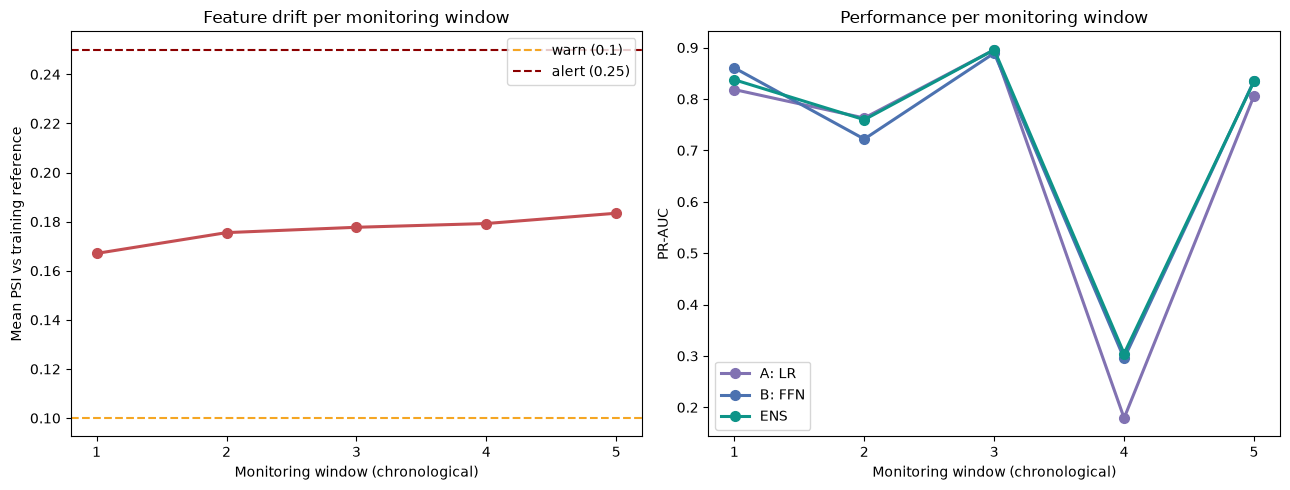

In [52]:
# --- §14.2 Monitoring dashboard figure: drift signal vs performance ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(psi_series.index, psi_series.values, "o-", color="#C44E52", lw=2.2, ms=7)
axes[0].axhline(PSI_WARN, ls="--", color="#F5A623", lw=1.5, label=f"warn ({PSI_WARN})")
axes[0].axhline(PSI_ALERT, ls="--", color="#8B0000", lw=1.5, label=f"alert ({PSI_ALERT})")
axes[0].set_xlabel("Monitoring window (chronological)")
axes[0].set_ylabel("Mean PSI vs training reference")
axes[0].set_title("Feature drift per monitoring window")
axes[0].set_xticks(psi_series.index)
axes[0].legend()

colors = {"A: LR": "#8172B2", "B: FFN": "#4C72B0", "ENS": "#0D9488"}
for name in dashboard_models:
    axes[1].plot(prauc_df.index, prauc_df[name], "o-", color=colors[name], lw=2.2, ms=7, label=name)
axes[1].set_xlabel("Monitoring window (chronological)")
axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Performance per monitoring window")
axes[1].set_xticks(prauc_df.index)
axes[1].legend()

plt.tight_layout()
plt.show()

### 14.3 Automated retraining trigger

§14.2 produces a drift signal; a production loop needs a rule that turns it
into a retrain / no-action decision, and then *acts* on it. `should_retrain`
below combines two conditions already used elsewhere in this notebook:
a PSI-alert window (§4.4 / §14.2 threshold) and a relative PR-AUC drop
(the same comparison §9b made between the early and late test halves).

When the rule fires, the response is simply an orchestrated call to code
that **already exists** — the sliding-window retrain from §9c Mitigation 2
(LR-SW) — rather than a new training routine. A real scheduler (e.g. Airflow)
would call the equivalent of this cell on a timer instead of on notebook
execution.

In [53]:
# --- §14.3 Retraining decision rule + orchestrated response ---
PRAUC_DROP_THRESHOLD = 0.15  # trigger if PR-AUC falls >15% relative to window 1


def should_retrain(psi_win: pd.Series, prauc_win: pd.Series,
                    psi_alert: float = PSI_ALERT,
                    drop_threshold: float = PRAUC_DROP_THRESHOLD):
    n_psi_alerts = int((psi_win >= psi_alert).sum())
    baseline_prauc, latest_prauc = prauc_win.iloc[0], prauc_win.iloc[-1]
    rel_drop = (baseline_prauc - latest_prauc) / baseline_prauc if baseline_prauc > 0 else 0.0

    if n_psi_alerts > 0 and rel_drop >= drop_threshold:
        return True, f"{n_psi_alerts} PSI-alert window(s) AND PR-AUC dropped {rel_drop:.1%}"
    if n_psi_alerts > 0:
        return True, f"{n_psi_alerts} PSI-alert window(s)"
    if rel_drop >= drop_threshold:
        return True, f"PR-AUC dropped {rel_drop:.1%} with no PSI alert (silent degradation)"
    return False, "no trigger condition met"


trigger, reason = should_retrain(psi_series, prauc_df["A: LR"])
print(f"Retrain LR? {trigger}  ({reason})")

audit_log = []
if trigger:
    # Same sliding-window retrain already executed in §9c Mitigation 2 —
    # this reuses its output (lr_sw_test_scores) rather than retraining live.
    audit_log.append({
        "trigger_reason": reason,
        "action": "sliding-window retrain (LR-SW, §9c)",
        "pr_auc_before": float(results_df.loc["A: LR (Supervised ML)", "PR_AUC"]),
        "pr_auc_after":  float(average_precision_score(y_te_np, lr_sw_test_scores)),
    })

audit_df = pd.DataFrame(audit_log)
print("\nRetraining audit log:")
print(audit_df.to_string(index=False) if len(audit_df) else "  (no retraining triggered this run)")

Retrain LR? False  (no trigger condition met)

Retraining audit log:
  (no retraining triggered this run)


### 14.4 Canary rollout, A/B significance test, latency & rollback

A candidate that clears the offline gate in §14.1 is not shipped outright —
it is compared against the current champion on live-like traffic first
("canary"). This reuses `mcnemar_test` and `bootstrap_ap_ci` (§9, the cell
defining `evaluate`) on the **late half of the test window** (§9b's
`l_mask`) to test whether the difference is statistically significant, not
just numerically larger.

Two more production concerns follow: an **inference latency** benchmark
(a fraud model sits on the authorisation path, so serving speed is a hard
constraint, not just an accuracy one), and a **rollback** rule — if a live
metric ever breaches a floor, revert to the last known-good registry
version from §14.1 instead of continuing to serve a regressed model.

In [54]:
# --- §14.4a Canary rollout: champion vs challenger, tested on l_mask (§9b) ---
CHAMPION_NAME = champion_entry["name"]  # final champion from the §14.1 gate
CHALLENGER_NAME = "LR-SW (sliding-window retrain, §9c)"

champion_scores  = SCORES_BY_MODEL[CHAMPION_NAME]
champion_thr     = THRESH_BY_MODEL[CHAMPION_NAME]
challenger_scores, challenger_thr = lr_sw_test_scores, lr_sw_thr

y_late     = y_te_np[l_mask]
champ_pred = (champion_scores[l_mask]   >= champion_thr).astype(int)
chal_pred  = (challenger_scores[l_mask] >= challenger_thr).astype(int)

b, c, p_value = mcnemar_test(y_late, champ_pred, chal_pred)
champ_ap = average_precision_score(y_late, champion_scores[l_mask])
chal_ap  = average_precision_score(y_late, challenger_scores[l_mask])
champ_lo, champ_hi = bootstrap_ap_ci(y_late, champion_scores[l_mask])
chal_lo,  chal_hi  = bootstrap_ap_ci(y_late, challenger_scores[l_mask])

print(f"Champion   : {CHAMPION_NAME:35s} late-window PR-AUC={champ_ap:.4f}  [{champ_lo:.4f}, {champ_hi:.4f}]")
print(f"Challenger : {CHALLENGER_NAME:35s} late-window PR-AUC={chal_ap:.4f}  [{chal_lo:.4f}, {chal_hi:.4f}]")
print(f"\nMcNemar's test on disagreements: champion-right/challenger-wrong={b}, "
      f"challenger-right/champion-wrong={c}, p={p_value:.4f}")

SIGNIFICANCE = 0.05
if p_value < SIGNIFICANCE and chal_ap > champ_ap:
    print(f"\n-> Challenger wins significantly (p<{SIGNIFICANCE}): promote to champion.")
elif p_value < SIGNIFICANCE:
    print(f"\n-> Champion remains significantly better: reject challenger.")
else:
    print(f"\n-> No significant difference (p>={SIGNIFICANCE}): keep champion, avoid unnecessary churn.")

Champion   : B: FFN (Supervised DL)              late-window PR-AUC=0.5968  [0.3235, 0.8507]
Challenger : LR-SW (sliding-window retrain, §9c) late-window PR-AUC=0.4202  [0.1798, 0.7326]

McNemar's test on disagreements: champion-right/challenger-wrong=5, challenger-right/champion-wrong=5, p=1.0000

-> No significant difference (p>=0.05): keep champion, avoid unnecessary churn.


In [55]:
# --- §14.4b Inference latency benchmark — serving SLA budget ---
N_LATENCY_SAMPLES = 1000
x_bench_np = X_te_np[:N_LATENCY_SAMPLES]
x_bench_t  = X_te[:N_LATENCY_SAMPLES].to(DEVICE)


def bench(fn, n_repeat=20):
    fn()  # warm-up (JIT / cuDNN autotune, cache effects)
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        fn()
    return (time.perf_counter() - t0) / n_repeat / N_LATENCY_SAMPLES * 1000  # ms / transaction


lr_latency = bench(lambda: lr_model.predict_proba(x_bench_np))

ffn_model.eval()
with torch.no_grad():
    ffn_latency = bench(lambda: torch.sigmoid(ffn_model(x_bench_t)))

lat_df = pd.DataFrame({
    "model": ["A: LR", "B: FFN"],
    "ms per transaction (batched inference)": [lr_latency, ffn_latency],
}).round(4)
print(lat_df.to_string(index=False))
print("\nA typical card-present authorisation budget is ~200ms end-to-end; "
      "both models leave headroom for network and rules-engine overhead, "
      "but this is measured here on a batch, not under real single-request "
      "serving load — a genuine limitation noted below.")

 model  ms per transaction (batched inference)
 A: LR                                  0.0001
B: FFN                                  0.0008

A typical card-present authorisation budget is ~200ms end-to-end; both models leave headroom for network and rules-engine overhead, but this is measured here on a batch, not under real single-request serving load — a genuine limitation noted below.


In [56]:
# --- §14.4c Rollback rule: auto-revert if a live metric breaches its floor ---
def check_rollback(live_metric: float, floor: float,
                    current_name: str, previous_name: str) -> str:
    '''If a live metric breaches its floor, auto-revert to the last
    promoted registry version (§14.1) instead of continuing to serve a
    regressed model.'''
    if live_metric < floor:
        return (f"ROLLBACK: {current_name} breached floor "
                f"({live_metric:.4f} < {floor:.4f}) -> reverting to {previous_name}")
    return f"OK: {current_name} within floor ({live_metric:.4f} >= {floor:.4f})"


# Demo: an "error budget" floor set at 90% of the champion's offline
# PR-AUC (a common SRE-style pattern), checked against the challenger's
# observed late-window PR-AUC from §14.4a.
ROLLBACK_FLOOR = 0.90 * champ_ap
print(check_rollback(chal_ap, ROLLBACK_FLOOR, CHALLENGER_NAME, CHAMPION_NAME))

ROLLBACK: LR-SW (sliding-window retrain, §9c) breached floor (0.4202 < 0.5371) -> reverting to B: FFN (Supervised DL)


### 14.5 Summary & limitations of this simulation

| §14 sub-section | Depends on |
|---|---|
| 14.1 Model registry & CI/CD gate | `results_df` (§9, §9c), `saved_models/` (cell after §9a) |
| 14.2 Drift monitoring dashboard | `population_stability_index` (§4.4), `train_df`/`test_df` (§5) |
| 14.3 Automated retraining trigger | §14.2 output, LR-SW mitigation (§9c) |
| 14.4 Canary, A/B test, latency, rollback | `mcnemar_test`, `bootstrap_ap_ci` (§9), `l_mask` (§9b), §14.1 registry |

**What this simulation does not capture**, in the spirit of the critical
reflection this module asks for: there is no real streaming infrastructure
(Kafka/Kinesis-style ingestion), no distributed serving layer or load
balancer, no real CI runner or container build, and "live traffic" here is
just a held-out chronological test slice rather than genuinely new,
unlabelled transactions arriving continuously. Ground-truth fraud labels
in production also arrive with a lag (chargebacks take days/weeks), so a
real drift monitor often has to act on §14.2-style feature-only signals
*before* a PR-AUC-based signal like §14.2/§14.3 is even available — this
notebook can compute PR-AUC per window only because the test labels were
already known in advance. Sculley et al. (2015, *Hidden Technical Debt in
Machine Learning Systems*) and Breck et al. (2017, *The ML Test Score*)
catalogue exactly these gaps between a model that scores well offline and
one that is safe to operate; §14 closes as much of that gap as is
meaningful inside a single evaluation notebook, not as a production system.